# Institutional Quant Stack v1 — TimeDART Integrated / Strict PIT / Colab

이 노트북은 기존 **TimeDART v6.3 Stability-First** 연구 코드를 폐기하지 않고, 이를 기관형 systematic research stack의 **alpha model 하나**로 재배치한 통합 버전입니다.
본 글은 공개 데이터와 개인 연구용 모델 실험을 바탕으로 한 분석이며, 특정 자산의 매수·매도 추천이나 투자 자문을 목적으로 하지 않습니다.

핵심 실행 경로는 다음과 같습니다.

`Immutable/PIT Data → Data Quality & Provenance → Signal Factory/Registry → Alpha Model Registry → Risk Model → Constrained Portfolio Optimizer → Cost/Impact Simulator → Shadow Ledger → Monitoring`

### 설계 원칙
1. 기존 strict point-in-time, purged OOS, multi-seed, robustness, ablation 검증을 보존합니다.
2. 기존 `Top-5`는 **diagnostic benchmark**로 유지하되, institutional portfolio의 최종 의사결정 규칙으로 사용하지 않습니다.
3. TimeDARTCompact는 `Alpha Model Lab`의 champion candidate이며, causal Signal-Ridge challenger와 비교합니다.
4. OOS 결과를 보고 champion을 사후 선택하지 않습니다. portfolio alpha source는 protocol에 사전 고정합니다.
5. Portfolio weight는 alpha뿐 아니라 covariance risk, sector concentration, liquidity, turnover, transaction cost를 동시에 고려합니다.
6. live 실행은 기본적으로 **SHADOW**이며 자동 실거래를 수행하지 않습니다.

> 연구용 시스템입니다. 실거래 주문·투자자문·수익 보장을 수행하지 않습니다.


## 실행 순서와 결과 해석

- **Data/PIT layer**: 기존 유니버스·OHLCV·strict leakage guard를 사용합니다.
- **Alpha layer**: 기존 TimeDARTCompact OOS를 그대로 재현하고, causal Signal-Ridge를 challenger로 추가합니다.
- **Portfolio layer**: `INSTITUTIONAL_PORTFOLIO_WEIGHTS`, `INSTITUTIONAL_PORTFOLIO_DAILY`가 새 핵심 결과입니다.
- **Top-5 layer**: 기존 `PRIMARY_DAILY`, `QUALIFIED_TOP5_DAILY`는 안정성 진단용으로만 해석합니다.
- **Deployment layer**: live는 기본 OFF이며, 명시적으로 켜도 `SHADOW` ledger만 기록합니다.
- **Governance**: `MODEL_REGISTRY`, `SIGNAL_REGISTRY`, `SYSTEM_PROMOTION_AUDIT`를 확인한 뒤 다음 연구단계를 결정합니다.


In [ ]:
!pip -q install -U yfinance pandas_market_calendars statsmodels arch finance-datareader pyarrow lxml "plotly>=5.20" scipy scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 157.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 163.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.3/213.3 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is t

In [ ]:
# @title 0. 실행 계약 — 첫 실행 전에 한 번만 설정
import os

# 불변 스냅샷과 미래 OOS 원장은 런타임이 종료되어도 남아야 합니다.
USE_GOOGLE_DRIVE = False  # @param {type:"boolean"}
if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        raise RuntimeError("Google Drive 마운트 실패. USE_GOOGLE_DRIVE=False 또는 경로를 확인하세요.") from exc

# AUTO: 스냅샷 파일이 있으면 읽고, 없으면 새로 생성합니다.
# REUSE: 기존 불변 스냅샷이 없으면 즉시 중단합니다.
# CREATE: 새 디렉터리에 최초 스냅샷을 생성합니다. 기존 파일은 덮어쓰지 않습니다.
SNAPSHOT_MODE = "AUTO"  # @param ["AUTO", "REUSE", "CREATE"]

# Colab 재시작 뒤에도 같은 데이터를 재사용하려면 Google Drive의 절대경로로 바꾸세요.
# 예: /content/drive/MyDrive/timedart/frozen_ohlcv_v1
FROZEN_SNAPSHOT_DIR = "/content/drive/MyDrive/TimeDART_v63/frozen_ohlcv_pit_v2"  # @param {type:"string"}

# STANDARD: 5개 시드 + 2개 미세교란 + 2개 학습창 검사
# QUICK: 3개 시드 + 1개 미세교란 + 1개 학습창 검사
# FULL: 8개 시드 + 3개 미세교란 + 3개 학습창 검사
REPRO_PROFILE = "STANDARD"  # @param ["QUICK", "STANDARD", "FULL"]
ROBUSTNESS_PROFILE = "STANDARD"  # @param ["QUICK", "STANDARD", "FULL"]

# 미래 OOS 원장은 영속 경로를 쓰는 것이 좋습니다.
FUTURE_LEDGER_DIR = "/content/drive/MyDrive/TimeDART_v63/future_oos_ledger_pit_v2"  # @param {type:"string"}
RUN_ROBUSTNESS = True  # @param {type:"boolean"}
RUN_LIVE_PREDICTION = True  # @param {type:"boolean"}
SCORE_MATURED_FUTURE_OOS = True  # @param {type:"boolean"}

# Strict leakage guard (권장: 항상 True).
# True일 때 현재 S&P500 구성/2026 수동 코어를 과거 OOS에 사용하지 않고,
# oos_start 직전의 S&P500 membership을 역사적 변경표로 복원해 동결합니다.
STRICT_LEAKAGE_GUARD = True  # @param {type:"boolean"}
# 빈 문자열이면 oos_start 하루 전(현재 설정에서는 2023-12-31)을 자동 사용합니다.
PIT_US_UNIVERSE_FREEZE_DATE = ""  # @param {type:"string"}

os.environ["TIMEDART_SNAPSHOT_MODE"] = SNAPSHOT_MODE
os.environ["TIMEDART_FROZEN_SNAPSHOT_DIR"] = FROZEN_SNAPSHOT_DIR
os.environ["TIMEDART_REPRO_PROFILE"] = REPRO_PROFILE
os.environ["TIMEDART_ROBUSTNESS_PROFILE"] = ROBUSTNESS_PROFILE
os.environ["TIMEDART_RUN_ROBUSTNESS"] = "1" if RUN_ROBUSTNESS else "0"
os.environ["TIMEDART_RUN_LIVE_PREDICTION"] = "1" if RUN_LIVE_PREDICTION else "0"
os.environ["TIMEDART_SCORE_FUTURE_OOS"] = "1" if SCORE_MATURED_FUTURE_OOS else "0"
os.environ["TIMEDART_FUTURE_LEDGER_DIR"] = FUTURE_LEDGER_DIR

print("중요: 완전한 재현성 검증에서는 같은 FROZEN_SNAPSHOT_DIR를 REUSE 모드로 사용하세요.")

os.environ["TIMEDART_STRICT_LEAKAGE_GUARD"] = "1" if STRICT_LEAKAGE_GUARD else "0"
os.environ["TIMEDART_PIT_US_UNIVERSE_FREEZE_DATE"] = PIT_US_UNIVERSE_FREEZE_DATE.strip()


중요: 완전한 재현성 검증에서는 같은 FROZEN_SNAPSHOT_DIR를 REUSE 모드로 사용하세요.


In [ ]:
from __future__ import annotations

import io
import hashlib
import json
import math
import os
import random
import re
import shutil
import zipfile
import xml.etree.ElementTree as ET
import time
import warnings

# Must be set before the first CUDA context for deterministic cuBLAS where supported.
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import asdict, dataclass
from datetime import datetime, time as dt_time
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
from itertools import combinations
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import statsmodels.api as sm
from IPython.display import display
from scipy.special import expit
from scipy.optimize import minimize
from scipy.stats import norm, spearmanr, t as student_t
from sklearn.metrics import (
    average_precision_score, brier_score_loss, mean_absolute_error,
    mean_squared_error, r2_score, roc_auc_score,
)
from sklearn.linear_model import Ridge
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import RobustScaler
import yfinance as yf
import requests
import FinanceDataReader as fdr

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 280)
plt.rcParams["figure.figsize"] = (13, 5)

KST = ZoneInfo("Asia/Seoul")
NY = ZoneInfo("America/New_York")
UTC = ZoneInfo("UTC")



STRICT_LEAKAGE_GUARD = os.getenv("TIMEDART_STRICT_LEAKAGE_GUARD", "1").strip() != "0"
_PIT_FREEZE_OVERRIDE = os.getenv("TIMEDART_PIT_US_UNIVERSE_FREEZE_DATE", "").strip()
_DEFAULT_PIT_FREEZE_DATE = str((pd.Timestamp("2024-01-01") - pd.Timedelta(days=1)).date())

@dataclass(frozen=True)
class Config:
    start_date: str = "2017-01-01"
    oos_start: str = "2024-01-01"
    horizons: Tuple[int, ...] = (5,)
    training_universe_target_kr: int = 180
    training_universe_target_us: int = 180
    min_training_universe: int = 150
    min_live_kr_common_universe: int = 150
    min_live_us_universe: int = 150
    live_patch_lookback_days: int = 45
    live_patch_workers: int = 8
    recommendation_cap: int = 20
    min_train_rows: int = 12000
    min_train_dates: int = 504
    calibration_dates: int = 126
    feature_min_coverage: float = 0.15
    min_listing_days: int = 252
    min_liquidity_percentile: float = 0.20
    min_price_kr: float = 1000.0
    min_price_us: float = 5.0
    half_life_days: int = 730
    roundtrip_cost_bps_kr: float = 25.0
    roundtrip_cost_bps_us: float = 12.0
    tail_z: float = 1.65
    min_tail_move_1d: float = 0.012
    random_state: int = 42

    # Strict point-in-time / anti-leakage contract.
    strict_leakage_guard: bool = STRICT_LEAKAGE_GUARD
    pit_us_universe_freeze_date: str = _PIT_FREEZE_OVERRIDE or _DEFAULT_PIT_FREEZE_DATE
    pit_us_universe_protocol: str = "SP500_WIKI_RECONSTRUCTED_ASOF_HASH_SAMPLE_V1"
    strict_us_market_neutral_only: bool = True
    strict_disable_inner_early_stopping: bool = True

    # 실제 산업/필수 수급 데이터 계약. 하나라도 실패하면 학습을 시작하지 않습니다.
    required_kr_industry_coverage: float = 0.95
    min_kr_industries: int = 10
    max_kr_industry_share: float = 0.35
    required_flow_ticker_coverage: float = 1.00
    required_flow_session_coverage: float = 0.70
    kr_flow_chunk_days: int = 730
    kr_flow_retries: int = 3
    krx_request_delay_seconds: float = 1.05

    # 3개 alpha + 1개 crash-risk. CUDA는 seed 2개, CPU는 자동으로 1개만 사용.
    deep_seeds: Tuple[int, ...] = (42, 137)
    sequence_length: int = 24
    max_sequence_features: int = 28
    deep_hidden: int = 48
    deep_dropout: float = 0.12
    deep_lr: float = 8e-4
    deep_weight_decay: float = 1e-3
    deep_epochs_gpu: int = 4
    deep_epochs_cpu: int = 2
    diffusion_pretrain_epochs_gpu: int = 1
    diffusion_pretrain_epochs_cpu: int = 0
    deep_patience: int = 2
    deep_inner_train_fraction: float = 0.85
    deep_batch_rows_gpu: int = 4096
    deep_batch_rows_cpu: int = 1536
    deep_predict_batch: int = 8192
    hybrid_anchor_alpha: float = 25.0
    kalman_process_noise: float = 0.05
    kalman_measurement_noise: float = 0.20
    pairwise_rank_weight: float = 0.12
    quantile_loss_weight: float = 0.12
    timer_next_token_weight: float = 0.0
    topk_loss_weight: float = 0.30
    topk_temperature: float = 0.12
    topk_rank_temperature: float = 0.35
    topk_return_scale: float = 0.02

    cost_weight_strength: float = 8.0
    fhs_guard_df: int = 7
    min_production_rank_ic: float = 0.0
    min_crash_auc: float = 0.55
    min_crash_pr_lift: float = 1.10
    min_crash_events: int = 30
    runtime_profile: str = "TIMEDART_V63_STRICT_PIT_LEAKAGE_GUARD_V1_3"
    oos_refit_frequency: str = "YEARLY"
    max_model_features: int = 64
    feature_selection_rows: int = 30000
    max_model_train_rows: int = 60000
    residual_estimation_rows: int = 18000
    top_k: int = 5
    max_ood_quantile: float = 0.99
    output_range_low_q: float = 0.0025
    output_range_high_q: float = 0.9975
    # 아래 두 값은 절대방향 diagnostic calibration 전용이며 순위 action gate에는 쓰이지 않습니다.
    calibration_verify_fraction: float = 0.40
    side_calibration_min_events: int = 20

    # 순수 Top/Bottom 포트폴리오 registry 기준. AUC/절대수익 gate와 독립입니다.
    rank_portfolio_min_active_days: int = 126
    rank_portfolio_min_hit_rate: float = 0.50
    rank_portfolio_min_hac_t: float = 1.64
    rank_portfolio_max_drawdown: float = -0.25
    recent_oos_sessions: int = 252
    rank_recent_min_active_days: int = 60
    rank_recent_min_hit_rate: float = 0.50
    min_horizon_consensus: int = 2

    # TimeDART US 5D 전용 연도·시장국면 안정성 gate.
    regime_ma_sessions: int = 200
    timedart_year_min_active_days: int = 60
    timedart_regime_min_active_days: int = 40
    timedart_min_positive_years: int = 2
    timedart_worst_regime_mean_floor: float = -0.002
    timedart_worst_regime_hit_floor: float = 0.45

    # Kalman 위험 임계값은 고정 확률 하한 없이 OOS 분위수·precision/recall로 선택합니다.
    crash_threshold_quantiles: Tuple[float, ...] = (0.90, 0.925, 0.95, 0.975, 0.99)
    crash_min_calibration_alerts: int = 20
    crash_min_precision_abs: float = 0.10
    crash_min_precision_lift: float = 1.25
    crash_min_recall: float = 0.05

    # OOS에서 확인된 KR→US 링크만 별도 표에 사용합니다.
    sparse_link_min_n: int = 252
    sparse_link_min_direction_hit: float = 0.505
    sparse_link_min_horizons: int = 2
    sparse_link_max_per_horizon: int = 20

    disclosure_lookback_years: int = 3
    output_dir: str = "/content/timedart_v63_strict_pit_v1_3_outputs"
    cache_dir: str = "/content/timedart_v63_strict_pit_v1_3_cache"


CFG = Config()
if not _PIT_FREEZE_OVERRIDE:
    # Config.oos_start가 수정되면 자동으로 그 직전 날짜를 사용합니다.
    object.__setattr__(CFG, "pit_us_universe_freeze_date", str((pd.Timestamp(CFG.oos_start) - pd.Timedelta(days=1)).date()))
if CFG.strict_leakage_guard and pd.Timestamp(CFG.pit_us_universe_freeze_date) >= pd.Timestamp(CFG.oos_start):
    raise RuntimeError("PIT US universe freeze date must be strictly before oos_start")
random.seed(CFG.random_state)
np.random.seed(CFG.random_state)

CORE_KR_UNIVERSE = {
    "005930.KS": ("삼성전자", "SEMICONDUCTOR"),
    "000660.KS": ("SK하이닉스", "SEMICONDUCTOR"),
    "042700.KS": ("한미반도체", "SEMI_EQUIPMENT"),
    "009150.KS": ("삼성전기", "ELECTRONIC_COMPONENT"),
    "058470.KQ": ("리노공업", "SEMI_EQUIPMENT"),
    "039030.KQ": ("이오테크닉스", "SEMI_EQUIPMENT"),
    "403870.KQ": ("HPSP", "SEMI_EQUIPMENT"),
    "036930.KQ": ("주성엔지니어링", "SEMI_EQUIPMENT"),
    "018260.KS": ("삼성SDS", "CLOUD_IT_SERVICE"),
    "035420.KS": ("NAVER", "CLOUD_PLATFORM"),
    "035720.KS": ("카카오", "PLATFORM"),
    "010120.KS": ("LS ELECTRIC", "POWER_INFRA"),
    "267260.KS": ("HD현대일렉트릭", "POWER_INFRA"),
    "034020.KS": ("두산에너빌리티", "POWER_INFRA"),
    "298040.KS": ("효성중공업", "POWER_INFRA"),
    "001440.KS": ("대한전선", "POWER_INFRA"),
    "103590.KS": ("일진전기", "POWER_INFRA"),
    "017670.KS": ("SK텔레콤", "NETWORK"),
    "030200.KS": ("KT", "NETWORK"),
    "272210.KS": ("한화시스템", "NETWORK"),
}

# '한국장에 영향을 받는다'고 가정하지 않고, 아래 후보 중 lagged KR→US beta가
# OOS/최신 시점에 확인된 종목만 최종 US 추천표에 남깁니다.
CORE_US_UNIVERSE = {
    "MU": ("Micron", "MEMORY"), "WDC": ("Western Digital", "MEMORY"),
    "SNDK": ("SanDisk", "MEMORY"), "NVDA": ("NVIDIA", "SEMI_AI"),
    "AMD": ("AMD", "SEMI_AI"), "AVGO": ("Broadcom", "SEMI_AI"),
    "TSM": ("TSMC ADR", "SEMI_FOUNDRY"), "MRVL": ("Marvell", "SEMI_AI"),
    "ANET": ("Arista Networks", "DATACENTER_INFRA"),
    "VRT": ("Vertiv", "DATACENTER_INFRA"), "DELL": ("Dell", "DATACENTER_INFRA"),
    "SMCI": ("Super Micro Computer", "DATACENTER_INFRA"),
    "AMAT": ("Applied Materials", "SEMI_EQUIPMENT"),
    "LRCX": ("Lam Research", "SEMI_EQUIPMENT"),
    "KLAC": ("KLA", "SEMI_EQUIPMENT"),
    "ASML": ("ASML ADR", "SEMI_EQUIPMENT"),
    "CEG": ("Constellation Energy", "POWER_INFRA"),
    "GEV": ("GE Vernova", "POWER_INFRA"),
    "ETN": ("Eaton", "POWER_INFRA"),
    "EQIX": ("Equinix", "DATACENTER_REIT"),
}

MARKET_ASSETS = {
    "KR_KOSPI": ("^KS11", "KR"), "KR_KOSPI200": ("^KS200", "KR"),
    "US_QQQ": ("QQQ", "US"), "US_SOX": ("^SOX", "US"),
    "US_VIX": ("^VIX", "US"), "US_TNX": ("^TNX", "US"),
    "US_DXY": ("DX-Y.NYB", "US"), "US_USDKRW": ("KRW=X", "US"),
    "US_ES_FUT": ("ES=F", "US"), "US_NQ_FUT": ("NQ=F", "US"),
    "US_RTY_FUT": ("RTY=F", "US"), "US_ZN_FUT": ("ZN=F", "US"),
    "US_CL_FUT": ("CL=F", "US"), "US_GC_FUT": ("GC=F", "US"),
}

KR_HEDGE = {"SHORT": "114800.KS", "CRASH_SHORT": "252670.KS"}
US_HEDGE = {
    "MEMORY": {"SHORT": "PSQ", "CRASH_SHORT": "SOXS"},
    "SEMI_AI": {"SHORT": "PSQ", "CRASH_SHORT": "SOXS"},
    "SEMI_FOUNDRY": {"SHORT": "PSQ", "CRASH_SHORT": "SOXS"},
    "SEMI_EQUIPMENT": {"SHORT": "PSQ", "CRASH_SHORT": "SOXS"},
    "DATACENTER_INFRA": {"SHORT": "PSQ", "CRASH_SHORT": "SQQQ"},
    "POWER_INFRA": {"SHORT": "PSQ", "CRASH_SHORT": "SQQQ"},
    "DATACENTER_REIT": {"SHORT": "PSQ", "CRASH_SHORT": "SQQQ"},
}

OUTPUT_DIR = Path(CFG.output_dir)
CACHE_DIR = Path(CFG.cache_dir)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if TORCH_DEVICE.type == "cuda": torch.set_float32_matmul_precision("high")
print(f"runtime profile: {CFG.runtime_profile}; CPU cores={os.cpu_count() or 1}; torch_device={TORCH_DEVICE}")
print(CFG)


runtime profile: TIMEDART_V63_STRICT_PIT_LEAKAGE_GUARD_V1_3; CPU cores=12; torch_device=cuda
Config(start_date='2017-01-01', oos_start='2024-01-01', horizons=(5,), training_universe_target_kr=180, training_universe_target_us=180, min_training_universe=150, min_live_kr_common_universe=150, min_live_us_universe=150, live_patch_lookback_days=45, live_patch_workers=8, recommendation_cap=20, min_train_rows=12000, min_train_dates=504, calibration_dates=126, feature_min_coverage=0.15, min_listing_days=252, min_liquidity_percentile=0.2, min_price_kr=1000.0, min_price_us=5.0, half_life_days=730, roundtrip_cost_bps_kr=25.0, roundtrip_cost_bps_us=12.0, tail_z=1.65, min_tail_move_1d=0.012, random_state=42, strict_leakage_guard=True, pit_us_universe_freeze_date='2023-12-31', pit_us_universe_protocol='SP500_WIKI_RECONSTRUCTED_ASOF_HASH_SAMPLE_V1', strict_us_market_neutral_only=True, strict_disable_inner_early_stopping=True, required_kr_industry_coverage=0.95, min_kr_industries=10, max_kr_industry_sh

## 1. 무로그인 유니버스 + 한국 공통 기준일 계약

FinanceDataReader의 실제 산업 분류를 사용하며 pykrx 로그인 경로는 제거합니다. 장기 OHLCV는 Yahoo 조정주가, 최근 완결 XKRX 세션 누락분은 FinanceDataReader로 축척을 맞춰 보강합니다. **같은 최근 완결 세션을 가진 한국 종목이 150개 미만이면 즉시 중단**합니다.


In [ ]:
def _flatten_columns(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    if not isinstance(df.columns, pd.MultiIndex):
        return df
    for level in range(df.columns.nlevels):
        if ticker in df.columns.get_level_values(level):
            return df.xs(ticker, axis=1, level=level, drop_level=True)
    out = df.copy(); out.columns = [c[0] for c in out.columns]
    return out


def _drop_incomplete_session(df: pd.DataFrame, market: str) -> pd.DataFrame:
    if df.empty: return df
    out = df.copy()
    out.index = pd.to_datetime(out.index).tz_localize(None).normalize()
    now_local = pd.Timestamp.now(tz="UTC").tz_convert("Asia/Seoul" if market == "KR" else "America/New_York")
    cutoff = dt_time(15, 40) if market == "KR" else dt_time(16, 20)
    if out.index.max().date() == now_local.date() and now_local.time() < cutoff:
        out = out.iloc[:-1]
    return out[~out.index.duplicated(keep="last")].sort_index()


def _safe_group(value, fallback):
    value = str(value or "").strip().upper()
    value = re.sub(r"[^A-Z0-9가-힣]+", "_", value).strip("_")
    return value[:48] if value and value not in {"NAN", "NONE"} else fallback


def _first_col(frame, names):
    lookup = {str(c).lower().replace(" ", ""): c for c in frame.columns}
    for name in names:
        key = name.lower().replace(" ", "")
        if key in lookup: return lookup[key]
    return None


KR_INDUSTRY_AUDIT = pd.DataFrame()
BAD_KR_INDUSTRY_VALUES = {
    "우량기업부", "중견기업부", "벤처기업부", "기술성장기업부", "관리종목",
    "KOSPI_OTHER", "KOSDAQ_OTHER", "KRX_OTHER", "기타",
}


def _load_kr_industry_csv() -> Tuple[Dict[str, str], Optional[str]]:
    path = Path(os.getenv("KR_SECTOR_CSV", "/content/krx_industry_classification.csv"))
    if not path.exists():
        return {}, None
    q = pd.read_csv(path)
    code_col = _first_col(q, ["ticker", "code", "종목코드", "단축코드"])
    industry_col = _first_col(q, ["industry_name", "industry", "업종명", "산업명", "KRX 업종명"])
    if code_col is None or industry_col is None:
        raise RuntimeError("KR_SECTOR_CSV requires ticker/code and industry_name/업종명 columns")
    codes = q[code_col].astype(str).str.extract(r"(\d+)", expand=False).str.zfill(6).str[-6:]
    mapping = dict(zip(codes, q[industry_col]))
    return {k: v for k, v in mapping.items() if pd.notna(k) and pd.notna(v)}, str(path)


def _validate_kr_industries(picked: pd.DataFrame, source_name: str) -> pd.DataFrame:
    global KR_INDUSTRY_AUDIT
    raw = picked["industry_name"].astype("string").str.strip()
    normalized = raw.map(lambda x: _safe_group(x, "") if pd.notna(x) else "")
    bad_normalized = {_safe_group(x, "") for x in BAD_KR_INDUSTRY_VALUES}
    valid = normalized.ne("") & ~normalized.isin(bad_normalized)
    coverage = float(valid.mean())
    valid_groups = normalized[valid]
    n_industries = int(valid_groups.nunique())
    largest_share = float(valid_groups.value_counts(normalize=True).max()) if len(valid_groups) else 1.0
    KR_INDUSTRY_AUDIT = pd.DataFrame([{
        "source": source_name, "selected_tickers": len(picked), "valid_tickers": int(valid.sum()),
        "coverage": coverage, "n_industries": n_industries, "largest_industry_share": largest_share,
        "contract_pass": bool(
            coverage >= CFG.required_kr_industry_coverage
            and n_industries >= CFG.min_kr_industries
            and largest_share <= CFG.max_kr_industry_share
        ),
    }])
    if not bool(KR_INDUSTRY_AUDIT.loc[0, "contract_pass"]):
        bad_examples = picked.loc[~valid, ["ticker", "name", "industry_name"]].head(10).to_dict("records")
        raise RuntimeError(
            "실제 KRX 산업 분류 계약 실패: "
            f"coverage={coverage:.1%}, industries={n_industries}, largest_share={largest_share:.1%}, "
            f"bad_examples={bad_examples}. KR_SECTOR_CSV로 공식 업종분류를 제공하세요."
        )
    out = picked.copy()
    out["group"] = normalized
    return out


def discover_kr_universe() -> Tuple[Dict[str, Tuple[str, str]], pd.DataFrame]:
    candidates, errors, desc_source = None, [], None
    csv_map, csv_source = _load_kr_industry_csv()
    try:
        cap = fdr.StockListing("KRX-MARCAP").copy()
        desc = fdr.StockListing("KRX-DESC").copy()
        cc, nc, mc, vc = (_first_col(cap, x) for x in [
            ["Code", "Symbol", "종목코드"], ["Name", "종목명"], ["Market", "시장"], ["Marcap", "시가총액"]
        ])
        dc = _first_col(desc, ["Code", "Symbol", "종목코드"])
        # 중요: generic Sector는 시장부 분류일 수 있으므로 절대 fallback으로 쓰지 않습니다.
        ic = _first_col(desc, ["Industry", "IndustryName", "업종명", "산업명", "업종"])
        if cc is None or nc is None or mc is None or vc is None:
            raise ValueError("KRX listing schema changed")
        candidates = pd.DataFrame({
            "code": cap[cc].astype(str).str.zfill(6), "name": cap[nc], "market": cap[mc],
            "marcap": pd.to_numeric(cap[vc], errors="coerce"),
        })
        if dc is not None and ic is not None:
            industry = desc[[dc, ic]].copy()
            industry[dc] = industry[dc].astype(str).str.zfill(6)
            candidates = candidates.merge(
                industry.rename(columns={dc: "code", ic: "industry_name"}), on="code", how="left"
            )
            desc_source = "FinanceDataReader KRX-DESC Industry"
    except Exception as exc:
        errors.append(f"FinanceDataReader:{exc}")

    if candidates is None or candidates.empty:
        raise RuntimeError(
            "FinanceDataReader 기반 한국 유니버스 발견 실패: " + " | ".join(errors[-3:])
            + ". pykrx/로그인 fallback은 사용하지 않습니다."
        )

    candidates["code"] = candidates["code"].astype(str).str.zfill(6)
    if "industry_name" not in candidates:
        candidates["industry_name"] = pd.NA
    if csv_map:
        from_csv = candidates["code"].map(csv_map)
        candidates["industry_name"] = from_csv.combine_first(candidates["industry_name"])
    industry_source = csv_source or desc_source or "MISSING"
    candidates = candidates[candidates["market"].astype(str).str.upper().isin(["KOSPI", "KOSDAQ"])].copy()
    candidates = candidates.sort_values("marcap", ascending=False).drop_duplicates("code")
    core_codes = {t[:6] for t in CORE_KR_UNIVERSE}
    candidates["core_priority"] = candidates["code"].isin(core_codes).astype(int)
    candidates = candidates.sort_values(["core_priority", "marcap"], ascending=[False, False])
    picked = candidates.head(CFG.training_universe_target_kr).copy()
    picked["ticker"] = picked["code"] + np.where(
        picked["market"].astype(str).str.upper().eq("KOSDAQ"), ".KQ", ".KS"
    )
    picked = picked.rename(columns={"marcap": "size_score"})[
        ["ticker", "name", "industry_name", "size_score"]
    ]
    picked = _validate_kr_industries(picked, industry_source)
    picked["market"] = "KR"
    return dict(zip(picked.ticker, zip(picked.name.astype(str), picked.group))), picked



US_PIT_UNIVERSE_AUDIT = pd.DataFrame()


def _normalize_us_symbol(value) -> str:
    if pd.isna(value):
        return ""
    s = str(value).strip().upper().replace(".", "-")
    s = re.sub(r"\[[^\]]+\]", "", s).strip()
    return "" if s in {"", "NAN", "NONE"} else s


def _flatten_wiki_columns(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if isinstance(out.columns, pd.MultiIndex):
        cols = []
        for col in out.columns:
            parts = [str(x).strip() for x in col if str(x).strip() and not str(x).startswith("Unnamed")]
            cols.append(" ".join(parts))
        out.columns = cols
    else:
        out.columns = [str(c).strip() for c in out.columns]
    return out


def _find_wiki_col(frame: pd.DataFrame, required_words: Sequence[str]) -> Optional[str]:
    words = [w.lower() for w in required_words]
    for col in frame.columns:
        low = str(col).lower()
        if all(w in low for w in words):
            return col
    return None


def _http_text(url: str, *, params: Optional[dict] = None, timeout: int = 30) -> str:
    """HTTP helper for Colab. Avoid pandas/urllib default User-Agent 403 responses."""
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
            "(KHTML, like Gecko) Chrome/124.0 Safari/537.36 TimeDART-PIT/1.3"
        ),
        "Accept": "text/html,application/xhtml+xml,application/json,text/plain,*/*",
        "Accept-Language": "en-US,en;q=0.9",
        "Cache-Control": "no-cache",
    }
    resp = requests.get(url, headers=headers, params=params, timeout=timeout)
    resp.raise_for_status()
    return resp.text


def _sp500_history_from_csv(asof: pd.Timestamp) -> Optional[pd.DataFrame]:
    """Load a pre-built historical S&P500 membership snapshot; no local file is required.

    The expected schema is exactly the public historical-components convention:
    ``date,tickers`` where ``tickers`` is a comma-separated membership list.
    Multiple mirrors are tried because Colab/network providers occasionally block one host.
    """
    override = os.getenv("TIMEDART_SP500_PIT_HISTORY_URL", "").strip()
    urls = ([override] if override else []) + [
        "https://raw.githubusercontent.com/chinobing/historical_sp500_constituents/main/sp_500_historical_components.csv",
        "https://github.com/chinobing/historical_sp500_constituents/raw/refs/heads/main/sp_500_historical_components.csv",
        "https://raw.githubusercontent.com/hanshof/sp500_constituents/master/sp_500_historical_components.csv",
    ]
    errors = []
    for url in urls:
        if not url:
            continue
        try:
            text = _http_text(url, timeout=45)
            hist = pd.read_csv(io.StringIO(text))
            lower = {str(c).strip().lower(): c for c in hist.columns}
            if "date" not in lower or "tickers" not in lower:
                raise ValueError(f"unexpected columns={list(hist.columns)[:8]}")
            date_col, tickers_col = lower["date"], lower["tickers"]
            hist = hist[[date_col, tickers_col]].rename(columns={date_col: "date", tickers_col: "tickers"})
            hist["date"] = pd.to_datetime(hist["date"], errors="coerce").dt.tz_localize(None).dt.normalize()
            hist = hist.dropna(subset=["date", "tickers"]).sort_values("date")
            eligible = hist[hist["date"].le(asof)]
            if eligible.empty:
                raise ValueError(f"no historical membership on/before {asof.date()}")
            row = eligible.iloc[-1]
            members = {
                _normalize_us_symbol(x)
                for x in str(row["tickers"]).split(",")
                if _normalize_us_symbol(x)
            }
            if len(members) < 450:
                raise ValueError(f"historical membership unexpectedly small: {len(members)}")
            out = pd.DataFrame({"ticker": sorted(members)})
            out["name"] = out["ticker"]
            out["group"] = "SP500_PIT"
            out["freeze_date"] = asof
            out.attrs["pit_source"] = url
            out.attrs["pit_source_date"] = str(pd.Timestamp(row["date"]).date())
            out.attrs["pit_method"] = "HISTORICAL_MEMBERSHIP_CSV"
            print(
                f"[PIT UNIVERSE SOURCE] historical CSV: {url} | "
                f"snapshot={out.attrs['pit_source_date']} | members={len(out)}"
            )
            return out
        except Exception as exc:
            errors.append(f"{url}: {type(exc).__name__}: {exc}")
    print("[PIT CSV SOURCE UNAVAILABLE] " + " | ".join(errors[-3:]))
    return None


def _sp500_history_from_mediawiki(asof: pd.Timestamp) -> pd.DataFrame:
    """Fallback: fetch Wikipedia through the supported MediaWiki Action API and reverse changes."""
    api_url = "https://en.wikipedia.org/w/api.php"
    payload = _http_text(
        api_url,
        params={
            "action": "parse",
            "page": "List of S&P 500 companies",
            "prop": "text",
            "format": "json",
            "formatversion": 2,
        },
        timeout=45,
    )
    data = json.loads(payload)
    html = data.get("parse", {}).get("text")
    if isinstance(html, dict):  # formatversion=1 compatibility
        html = html.get("*")
    if not html:
        raise RuntimeError(f"MediaWiki API returned no parsed page text: keys={list(data)[:8]}")
    tables = pd.read_html(io.StringIO(html))
    if len(tables) < 2:
        raise RuntimeError("S&P500 historical change table was not found in MediaWiki output")

    current = _flatten_wiki_columns(tables[0])
    sym_col = _find_wiki_col(current, ["symbol"]) or _find_wiki_col(current, ["ticker"])
    name_col = _find_wiki_col(current, ["security"]) or _find_wiki_col(current, ["name"])
    if sym_col is None:
        raise RuntimeError("Could not identify the current S&P500 symbol column")

    changes = None
    for table in tables[1:]:
        q = _flatten_wiki_columns(table)
        date_col = _find_wiki_col(q, ["date"])
        add_col = _find_wiki_col(q, ["added", "ticker"])
        rem_col = _find_wiki_col(q, ["removed", "ticker"])
        if date_col is not None and add_col is not None and rem_col is not None:
            changes = q
            break
    if changes is None:
        raise RuntimeError("Could not identify S&P500 added/removed historical change columns")

    date_col = _find_wiki_col(changes, ["date"])
    add_col = _find_wiki_col(changes, ["added", "ticker"])
    rem_col = _find_wiki_col(changes, ["removed", "ticker"])
    add_name_col = _find_wiki_col(changes, ["added", "security"])
    rem_name_col = _find_wiki_col(changes, ["removed", "security"])
    changes = changes.copy()
    changes["__date"] = pd.to_datetime(changes[date_col], errors="coerce").dt.tz_localize(None).dt.normalize()

    current_symbols = current[sym_col].map(_normalize_us_symbol)
    members = {x for x in current_symbols if x}
    names = {}
    if name_col is not None:
        names.update({
            _normalize_us_symbol(t): str(n)
            for t, n in zip(current[sym_col], current[name_col])
            if _normalize_us_symbol(t)
        })

    later = changes[
        changes["__date"].notna() & changes["__date"].gt(asof)
    ].sort_values("__date", ascending=False)
    for _, row in later.iterrows():
        added = _normalize_us_symbol(row.get(add_col))
        removed = _normalize_us_symbol(row.get(rem_col))
        if added:
            members.discard(added)
            if add_name_col is not None and pd.notna(row.get(add_name_col)):
                names.setdefault(added, str(row.get(add_name_col)))
        if removed:
            members.add(removed)
            if rem_name_col is not None and pd.notna(row.get(rem_name_col)):
                names[removed] = str(row.get(rem_name_col))

    if len(members) < 450:
        raise RuntimeError(f"Reconstructed S&P500 universe unexpectedly small ({len(members)}) at {asof.date()}")
    out = pd.DataFrame({"ticker": sorted(members)})
    out["name"] = out["ticker"].map(names).fillna(out["ticker"])
    out["group"] = "SP500_PIT"
    out["freeze_date"] = asof
    out.attrs["pit_source"] = api_url
    out.attrs["pit_source_date"] = str(asof.date())
    out.attrs["pit_method"] = "MEDIAWIKI_API_REVERSE_CHANGES"
    print(f"[PIT UNIVERSE SOURCE] MediaWiki API reverse-changes | asof={asof.date()} | members={len(out)}")
    return out


def reconstruct_sp500_asof(asof_date: str) -> pd.DataFrame:
    """Return S&P500 membership available as of the pre-OOS freeze date.

    No user-supplied file is required.  We first use a public historical-membership CSV;
    if that host is unavailable we use the official MediaWiki Action API rather than
    ``pd.read_html(url)`` (which frequently receives HTTP 403 in Colab).

    IMPORTANT: if every historical source fails, STRICT PIT mode stops.  It never falls
    back to the current S&P500 list, because that would re-introduce universe look-ahead.
    """
    asof = pd.Timestamp(asof_date).tz_localize(None).normalize()
    historical = _sp500_history_from_csv(asof)
    if historical is not None:
        return historical
    try:
        return _sp500_history_from_mediawiki(asof)
    except Exception as exc:
        raise RuntimeError(
            "STRICT PIT mode could not obtain historical S&P500 membership automatically. "
            "No local file is required, but at least one public historical endpoint must be reachable. "
            "Both the GitHub historical-membership mirrors and the MediaWiki API failed. "
            "Current-universe fallback is intentionally forbidden because it would re-introduce "
            f"survivorship/look-ahead bias. Final error: {type(exc).__name__}: {exc}"
        ) from exc

def discover_us_universe() -> Tuple[Dict[str, Tuple[str, str]], pd.DataFrame]:
    global US_PIT_UNIVERSE_AUDIT
    if CFG.strict_leakage_guard:
        candidates = reconstruct_sp500_asof(CFG.pit_us_universe_freeze_date)
        # Deterministic ex-ante sample. No post-freeze price, return, market-cap, sector, or manual-core information.
        candidates["selection_hash"] = candidates["ticker"].map(
            lambda t: hashlib.sha256(
                f"{CFG.pit_us_universe_protocol}|{CFG.pit_us_universe_freeze_date}|{t}".encode("utf-8")
            ).hexdigest()
        )
        picked = candidates.sort_values(["selection_hash", "ticker"]).head(CFG.training_universe_target_us).copy()
        picked["size_score"] = np.arange(len(picked), 0, -1, dtype=float)  # ordering token only; not market size
        picked["market"] = "US"
        US_PIT_UNIVERSE_AUDIT = pd.DataFrame([{
            "strict_leakage_guard": True,
            "protocol": CFG.pit_us_universe_protocol,
            "freeze_date": CFG.pit_us_universe_freeze_date,
            "pit_source": candidates.attrs.get("pit_source", "UNKNOWN"),
            "pit_method": candidates.attrs.get("pit_method", "UNKNOWN"),
            "pit_source_date": candidates.attrs.get("pit_source_date", "UNKNOWN"),
            "reconstructed_members": int(len(candidates)),
            "selected_tickers": int(len(picked)),
            "manual_core_used": False,
            "current_gics_used": False,
            "selection_uses_post_freeze_market_data": False,
        }])
        print("[STRICT PIT US UNIVERSE]")
        display(US_PIT_UNIVERSE_AUDIT)
        return dict(zip(picked.ticker, zip(picked.name.astype(str), picked.group.astype(str)))), picked

    # Legacy/non-strict mode retained only for explicit diagnostics.
    errors, candidates = [], None
    try:
        raw = fdr.StockListing("S&P500").copy()
        tc, nc, sc = _first_col(raw, ["Symbol", "Code", "Ticker"]), _first_col(raw, ["Name", "Security"]), _first_col(raw, ["Sector", "GICS Sector"])
        if tc is None or nc is None: raise ValueError("S&P500 listing schema changed")
        candidates = pd.DataFrame({"ticker": raw[tc], "name": raw[nc], "group": raw[sc] if sc is not None else "SP500_OTHER"})
    except Exception as exc:
        errors.append(f"FinanceDataReader:{exc}")
    if candidates is None or candidates.empty:
        raw = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")[0]
        candidates = raw[["Symbol", "Security", "GICS Sector"]].rename(columns={"Symbol":"ticker", "Security":"name", "GICS Sector":"group"})
    candidates["ticker"] = candidates["ticker"].map(_normalize_us_symbol)
    candidates["group"] = candidates["group"].map(lambda x: _safe_group(x, "SP500_OTHER"))
    candidates["size_score"] = np.arange(len(candidates), 0, -1)
    core = pd.DataFrame([(t.replace(".", "-"), v[0], v[1], np.inf) for t, v in CORE_US_UNIVERSE.items()], columns=candidates.columns)
    picked = pd.concat([core, candidates], ignore_index=True).drop_duplicates("ticker").head(CFG.training_universe_target_us)
    return dict(zip(picked.ticker, zip(picked.name, picked.group))), picked.assign(market="US")


FROZEN_SNAPSHOT_DIR = Path(os.getenv(
    "TIMEDART_FROZEN_SNAPSHOT_DIR", "/content/timedart_v63_frozen_ohlcv_pit_v2"
))
FROZEN_SNAPSHOT_MODE = os.getenv("TIMEDART_SNAPSHOT_MODE", "AUTO").strip().upper()
if FROZEN_SNAPSHOT_MODE not in {"AUTO", "REUSE", "CREATE"}:
    raise ValueError("TIMEDART_SNAPSHOT_MODE must be AUTO, REUSE, or CREATE")
FROZEN_OHLCV_FILE = FROZEN_SNAPSHOT_DIR / "ohlcv.parquet"
FROZEN_META_FILE = FROZEN_SNAPSHOT_DIR / "universe_meta.parquet"
FROZEN_MANIFEST_FILE = FROZEN_SNAPSHOT_DIR / "manifest.csv"
FROZEN_CONTRACT_FILE = FROZEN_SNAPSHOT_DIR / "snapshot_contract.json"
FROZEN_FILES = [FROZEN_OHLCV_FILE, FROZEN_META_FILE, FROZEN_MANIFEST_FILE, FROZEN_CONTRACT_FILE]
FROZEN_SNAPSHOT_AVAILABLE = all(p.exists() for p in FROZEN_FILES)

if FROZEN_SNAPSHOT_MODE == "REUSE" and not FROZEN_SNAPSHOT_AVAILABLE:
    raise RuntimeError(
        "REUSE 모드인데 불변 OHLCV 스냅샷이 없습니다. 최초 한 번은 빈 디렉터리에서 CREATE/AUTO를 실행하세요."
    )
if FROZEN_SNAPSHOT_MODE == "CREATE" and any(p.exists() for p in FROZEN_FILES):
    raise RuntimeError(
        "CREATE는 기존 스냅샷을 덮어쓰지 않습니다. 새 디렉터리를 지정하거나 REUSE를 선택하세요."
    )

if FROZEN_SNAPSHOT_AVAILABLE and FROZEN_SNAPSHOT_MODE in {"AUTO", "REUSE"}:
    KR_UNIVERSE, US_UNIVERSE = {}, {}
    KR_UNIVERSE_META, US_UNIVERSE_META = pd.DataFrame(), pd.DataFrame()
else:
    KR_UNIVERSE, KR_UNIVERSE_META = discover_kr_universe()
    US_UNIVERSE, US_UNIVERSE_META = discover_us_universe()


def download_ohlcv(ticker: str, market: str, retries: int = 2) -> pd.DataFrame:
    safe = ticker.replace("^", "IDX_").replace("=", "_").replace(".", "_")
    cache = CACHE_DIR / f"{safe}.pkl"
    end = (pd.Timestamp.now(tz="UTC").normalize() + pd.Timedelta(days=3)).strftime("%Y-%m-%d")
    for attempt in range(retries):
        try:
            raw = yf.download(ticker, start=CFG.start_date, end=end, auto_adjust=True, actions=False,
                              progress=False, threads=False, timeout=30)
            raw = _flatten_columns(raw, ticker)
            need = ["Open", "High", "Low", "Close", "Volume"]
            if raw.empty or not set(need).issubset(raw.columns): raise ValueError("empty/malformed response")
            out = _drop_incomplete_session(raw[need].apply(pd.to_numeric, errors="coerce").dropna(subset=need[:4]), market)
            out.to_pickle(cache); return out
        except Exception as exc:
            if attempt + 1 == retries:
                if cache.exists(): return pd.read_pickle(cache)
                raise
            time.sleep(2 ** attempt)


def download_universe(universe, market, chunk=40):
    result, failures = {}, []
    tickers, end = list(universe), (pd.Timestamp.now(tz="UTC").normalize() + pd.Timedelta(days=3)).strftime("%Y-%m-%d")
    for start in range(0, len(tickers), chunk):
        batch = tickers[start:start+chunk]
        try:
            raw = yf.download(batch, start=CFG.start_date, end=end, auto_adjust=True, actions=False,
                              progress=False, threads=True, group_by="ticker", timeout=60)
        except Exception:
            raw = pd.DataFrame()
        for ticker in batch:
            try:
                q = _flatten_columns(raw, ticker)
                need = ["Open", "High", "Low", "Close", "Volume"]
                if q.empty or not set(need).issubset(q.columns): raise ValueError("batch missing")
                q = _drop_incomplete_session(q[need].apply(pd.to_numeric, errors="coerce").dropna(subset=need[:4]), market)
                if len(q) < CFG.min_listing_days: raise ValueError("history too short")
                result[ticker] = q
                q.to_pickle(CACHE_DIR / f"{ticker.replace('.', '_')}.pkl")
            except Exception as exc:
                try: result[ticker] = download_ohlcv(ticker, market)
                except Exception as retry_exc: failures.append((market, ticker, str(retry_exc or exc)))
        print(f"[OHLCV] {market} {min(start+chunk, len(tickers))}/{len(tickers)} success={len(result)}")
    return result, failures


def latest_completed_session(calendar_name: str, close_buffer_minutes: int) -> pd.Timestamp:
    """현재 시각 기준으로 close+buffer가 지난 마지막 실제 거래소 세션입니다."""
    now = pd.Timestamp.now(tz="UTC")
    calendar = mcal.get_calendar(calendar_name)
    sched = calendar.schedule(
        start_date=(now - pd.Timedelta(days=20)).date(),
        end_date=(now + pd.Timedelta(days=2)).date(),
    )
    close_at = pd.to_datetime(sched["market_close"], utc=True) + pd.Timedelta(minutes=close_buffer_minutes)
    done = sched.loc[close_at <= now]
    if done.empty:
        raise RuntimeError(f"{calendar_name}에서 완결된 최근 세션을 찾지 못했습니다")
    return pd.Timestamp(done.index[-1]).tz_localize(None).normalize()


def normalize_fdr_ohlcv(raw: pd.DataFrame) -> pd.DataFrame:
    if raw is None or raw.empty:
        raise ValueError("empty FinanceDataReader response")
    lookup = {str(c).strip().lower(): c for c in raw.columns}
    names = {name: lookup.get(name.lower()) for name in ["Open", "High", "Low", "Close", "Volume"]}
    if any(names[x] is None for x in ["Open", "High", "Low", "Close"]):
        raise ValueError(f"unexpected FinanceDataReader OHLCV columns: {list(raw.columns)}")
    out = pd.DataFrame(index=pd.to_datetime(raw.index).tz_localize(None).normalize())
    for name, col in names.items():
        out[name] = pd.to_numeric(raw[col], errors="coerce") if col is not None else 0.0
    out["Volume"] = out["Volume"].fillna(0.0)
    return out.dropna(subset=["Open", "High", "Low", "Close"]).loc[lambda q: ~q.index.duplicated(keep="last")].sort_index()


def patch_kr_latest_session(ticker: str, existing: pd.DataFrame, expected: pd.Timestamp) -> Tuple[pd.DataFrame, str]:
    """Yahoo 조정주가 축척을 유지하며 FDR의 최근 누락 세션만 이어 붙입니다."""
    if expected in existing.index:
        return existing, "ALREADY_PRESENT"
    start = expected - pd.Timedelta(days=CFG.live_patch_lookback_days)
    raw = fdr.DataReader(ticker[:6], start.strftime("%Y-%m-%d"), (expected + pd.Timedelta(days=3)).strftime("%Y-%m-%d"))
    patch = normalize_fdr_ohlcv(raw)
    common = existing.index.intersection(patch.index)
    if len(common):
        anchor = common[-1]
        denominator = float(patch.loc[anchor, "Close"])
        factor = float(existing.loc[anchor, "Close"]) / denominator if denominator else 1.0
        patch[["Open", "High", "Low", "Close"]] *= factor
    new_rows = patch.loc[~patch.index.isin(existing.index)]
    combined = pd.concat([existing, new_rows]).loc[lambda q: ~q.index.duplicated(keep="first")].sort_index()
    if expected not in combined.index:
        raise ValueError(f"{expected.date()} row absent (suspension/delisting/provider lag)")
    return combined, "PATCHED_FDR"


def enforce_kr_common_live_date(data: Dict[str, pd.DataFrame]) -> Tuple[Dict[str, pd.DataFrame], pd.DataFrame, pd.DataFrame]:
    expected = latest_completed_session("XKRX", 40)
    before = {ticker: bool(expected in frame.index) for ticker, frame in data.items()}
    patched, errors = dict(data), {}
    missing = [ticker for ticker, present in before.items() if not present]
    if missing:
        with ThreadPoolExecutor(max_workers=min(CFG.live_patch_workers, len(missing))) as pool:
            futures = {pool.submit(patch_kr_latest_session, ticker, data[ticker], expected): ticker for ticker in missing}
            for future in as_completed(futures):
                ticker = futures[future]
                try:
                    patched[ticker], _ = future.result()
                except Exception as exc:
                    errors[ticker] = str(exc)
    rows = []
    for ticker, frame in patched.items():
        rows.append({
            "ticker": ticker,
            "common_signal_date": expected,
            "present_before_patch": before[ticker],
            "present_after_patch": bool(expected in frame.index),
            "patch_status": "ALREADY_PRESENT" if before[ticker] else ("PATCHED_FDR" if expected in frame.index else "FAILED"),
            "error": errors.get(ticker, ""),
            "last_session": frame.index.max(),
        })
    audit = pd.DataFrame(rows)
    common_tickers = audit.loc[audit["present_after_patch"], "ticker"].tolist()
    contract = pd.DataFrame([{
        "common_signal_date": expected,
        "downloaded_tickers": len(data),
        "present_before_patch": int(audit["present_before_patch"].sum()),
        "patched_by_fdr": int(audit["patch_status"].eq("PATCHED_FDR").sum()),
        "common_tickers_after_patch": len(common_tickers),
        "required_common_tickers": CFG.min_live_kr_common_universe,
        "contract_pass": len(common_tickers) >= CFG.min_live_kr_common_universe,
        "provider_contract": "Yahoo adjusted history + FinanceDataReader recent-session repair; no pykrx auth",
    }])
    if not bool(contract.loc[0, "contract_pass"]):
        examples = audit.loc[~audit["present_after_patch"], ["ticker", "last_session", "error"]].head(12).to_dict("records")
        raise RuntimeError(
            f"한국 공통 기준일 계약 실패: {expected.date()} 보유 종목={len(common_tickers)}, "
            f"필요={CFG.min_live_kr_common_universe}, examples={examples}"
        )
    print(
        f"[KR COMMON DATE] {expected.date()} before={int(audit['present_before_patch'].sum())} "
        f"after={len(common_tickers)} patched={int(audit['patch_status'].eq('PATCHED_FDR').sum())}"
    )
    return patched, audit, contract


OHLCV_COLUMNS = ["Open", "High", "Low", "Close", "Volume"]


def _snapshot_frame_hash(source_group: str, key: str, ticker: str, frame: pd.DataFrame) -> dict:
    q = frame[OHLCV_COLUMNS].copy().sort_index()
    q.index = pd.to_datetime(q.index).tz_localize(None).normalize()
    q.index.name = "date"
    payload = q.round(8).to_csv(date_format="%Y-%m-%d").encode("utf-8")
    return {
        "source_group": source_group, "key": key, "ticker": ticker,
        "rows": len(q), "first_date": q.index.min(), "last_date": q.index.max(),
        "columns": "|".join(OHLCV_COLUMNS), "sha256": hashlib.sha256(payload).hexdigest(),
    }


def _snapshot_id(manifest: pd.DataFrame) -> str:
    payload = "\n".join(
        manifest.sort_values(["source_group", "key"])
        .apply(lambda r: f'{r["source_group"]}|{r["key"]}|{r["sha256"]}', axis=1)
    ).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def _frames_to_long(source_group: str, mapping: Dict[str, pd.DataFrame], ticker_lookup: Dict[str, str]) -> pd.DataFrame:
    parts = []
    for key, frame in sorted(mapping.items()):
        q = frame[OHLCV_COLUMNS].copy().reset_index()
        q = q.rename(columns={q.columns[0]: "date"})
        q.insert(0, "ticker", str(ticker_lookup.get(str(key), str(key))))
        q.insert(0, "key", str(key))
        q.insert(0, "source_group", source_group)
        parts.append(q)
    return pd.concat(parts, ignore_index=True)


def write_immutable_ohlcv_snapshot(
    kr_frames: Dict[str, pd.DataFrame], us_frames: Dict[str, pd.DataFrame],
    market_frames: Dict[str, pd.DataFrame], kr_contract: pd.DataFrame,
) -> Tuple[pd.DataFrame, dict]:
    if any(p.exists() for p in FROZEN_FILES):
        raise RuntimeError("불변 스냅샷의 일부 또는 전부가 이미 존재합니다. 자동 덮어쓰기를 차단했습니다.")
    FROZEN_SNAPSHOT_DIR.mkdir(parents=True, exist_ok=True)
    market_tickers = {key: ticker for key, (ticker, _) in MARKET_ASSETS.items()}
    long = pd.concat([
        _frames_to_long("KR_STOCK", kr_frames, {t: t for t in kr_frames}),
        _frames_to_long("US_STOCK", us_frames, {t: t for t in us_frames}),
        _frames_to_long("MARKET", market_frames, market_tickers),
    ], ignore_index=True)
    long["date"] = pd.to_datetime(long["date"]).dt.tz_localize(None).dt.normalize()

    meta_rows = []
    for market, universe in [("KR", KR_UNIVERSE), ("US", US_UNIVERSE)]:
        for ticker, (name, group) in sorted(universe.items()):
            if ticker in (kr_frames if market == "KR" else us_frames):
                meta_rows.append({"market": market, "ticker": ticker, "name": name, "group": group})
    meta = pd.DataFrame(meta_rows)
    manifest_rows = []
    for source, mapping, lookup in [
        ("KR_STOCK", kr_frames, {t: t for t in kr_frames}),
        ("US_STOCK", us_frames, {t: t for t in us_frames}),
        ("MARKET", market_frames, market_tickers),
    ]:
        for key, frame in sorted(mapping.items()):
            manifest_rows.append(_snapshot_frame_hash(source, str(key), str(lookup.get(key, key)), frame))
    manifest = pd.DataFrame(manifest_rows)
    sid = _snapshot_id(manifest)
    contract = {
        "snapshot_id": sid,
        "created_at_utc": datetime.now(UTC).isoformat(),
        "immutable": True,
        "auto_adjust": True,
        "source_contract": "Yahoo adjusted OHLCV; KR latest-session repair is frozen before hashing",
        "strict_leakage_guard": bool(CFG.strict_leakage_guard),
        "us_universe_policy": CFG.pit_us_universe_protocol if CFG.strict_leakage_guard else "LEGACY_CURRENT_DISCOVERY",
        "us_universe_freeze_date": CFG.pit_us_universe_freeze_date if CFG.strict_leakage_guard else None,
        "us_sector_policy": "CONSTANT_SP500_PIT_NO_CURRENT_GICS" if CFG.strict_leakage_guard else "CURRENT_GROUP",
        "manual_us_core_in_historical_oos": False if CFG.strict_leakage_guard else True,
        "start_date": CFG.start_date,
        "common_kr_signal_date": str(pd.Timestamp(kr_contract.loc[0, "common_signal_date"]).date()),
        "kr_tickers": len(kr_frames), "us_tickers": len(us_frames), "market_assets": len(market_frames),
        "ohlcv_rows": int(len(long)),
    }

    temp_ohlcv = FROZEN_OHLCV_FILE.with_suffix(".tmp.parquet")
    temp_meta = FROZEN_META_FILE.with_suffix(".tmp.parquet")
    long.to_parquet(temp_ohlcv, index=False)
    meta.to_parquet(temp_meta, index=False)
    os.replace(temp_ohlcv, FROZEN_OHLCV_FILE)
    os.replace(temp_meta, FROZEN_META_FILE)
    manifest.to_csv(FROZEN_MANIFEST_FILE, index=False)
    FROZEN_CONTRACT_FILE.write_text(json.dumps(contract, ensure_ascii=False, indent=2), encoding="utf-8")
    return manifest, contract


def read_immutable_ohlcv_snapshot():
    if not all(p.exists() for p in FROZEN_FILES):
        raise RuntimeError("불변 스냅샷 4개 파일 중 일부가 없습니다. 부분 스냅샷은 사용하지 않습니다.")
    long = pd.read_parquet(FROZEN_OHLCV_FILE)
    meta = pd.read_parquet(FROZEN_META_FILE)
    manifest = pd.read_csv(FROZEN_MANIFEST_FILE)
    contract = json.loads(FROZEN_CONTRACT_FILE.read_text(encoding="utf-8"))
    if _snapshot_id(manifest) != contract["snapshot_id"]:
        raise RuntimeError("스냅샷 manifest hash가 contract와 다릅니다")
    if CFG.strict_leakage_guard:
        expected = {
            "strict_leakage_guard": True,
            "us_universe_policy": CFG.pit_us_universe_protocol,
            "us_universe_freeze_date": CFG.pit_us_universe_freeze_date,
            "manual_us_core_in_historical_oos": False,
        }
        bad = {k: (contract.get(k), v) for k, v in expected.items() if contract.get(k) != v}
        if bad:
            raise RuntimeError(
                "STRICT PIT mode rejected a legacy/leakage-prone frozen snapshot. "
                f"mismatch={bad}. Use a NEW FROZEN_SNAPSHOT_DIR (e.g. frozen_ohlcv_pit_v2) and CREATE/AUTO once."
            )
    long["date"] = pd.to_datetime(long["date"]).dt.tz_localize(None).dt.normalize()
    mappings = {}
    for source_group, source_rows in long.groupby("source_group", sort=False):
        source_map = {}
        for key, g in source_rows.groupby("key", sort=False):
            frame = g.set_index("date")[OHLCV_COLUMNS].sort_index()
            source_map[str(key)] = frame
        mappings[source_group] = source_map
    kr_universe = {
        str(r.ticker): (str(r.name), str(r.group))
        for r in meta[meta["market"].eq("KR")].itertuples(index=False)
    }
    us_universe = {
        str(r.ticker): (str(r.name), str(r.group))
        for r in meta[meta["market"].eq("US")].itertuples(index=False)
    }
    return (
        mappings.get("KR_STOCK", {}), mappings.get("US_STOCK", {}), mappings.get("MARKET", {}),
        kr_universe, us_universe, manifest, contract,
    )


if FROZEN_SNAPSHOT_AVAILABLE and FROZEN_SNAPSHOT_MODE in {"AUTO", "REUSE"}:
    (
        kr_data, us_data, market_data, KR_UNIVERSE, US_UNIVERSE,
        FROZEN_SNAPSHOT_MANIFEST, FROZEN_SNAPSHOT_CONTRACT,
    ) = read_immutable_ohlcv_snapshot()
    common_date = pd.Timestamp(FROZEN_SNAPSHOT_CONTRACT["common_kr_signal_date"]).normalize()
    KR_COMMON_UNIVERSE_AUDIT = pd.DataFrame([
        {
            "ticker": ticker, "common_signal_date": common_date,
            "present_before_patch": common_date in frame.index,
            "present_after_patch": common_date in frame.index,
            "patch_status": "FROZEN_REUSE", "error": "", "last_session": frame.index.max(),
        }
        for ticker, frame in kr_data.items()
    ])
    KR_COMMON_LIVE_CONTRACT = pd.DataFrame([{
        "common_signal_date": common_date, "downloaded_tickers": len(kr_data),
        "common_tickers_after_patch": int(KR_COMMON_UNIVERSE_AUDIT["present_after_patch"].sum()),
        "required_common_tickers": CFG.min_live_kr_common_universe,
        "contract_pass": int(KR_COMMON_UNIVERSE_AUDIT["present_after_patch"].sum()) >= CFG.min_live_kr_common_universe,
        "provider_contract": "IMMUTABLE_PARQUET_REUSE",
    }])
    kr_fail, us_fail, market_fail = [], [], []
    print(f"[FROZEN SNAPSHOT REUSED] id={FROZEN_SNAPSHOT_CONTRACT['snapshot_id']}")
else:
    kr_data, kr_fail = download_universe(KR_UNIVERSE, "KR")
    us_data, us_fail = download_universe(US_UNIVERSE, "US")
    kr_data, KR_COMMON_UNIVERSE_AUDIT, KR_COMMON_LIVE_CONTRACT = enforce_kr_common_live_date(kr_data)
    KR_UNIVERSE = {t: KR_UNIVERSE[t] for t in kr_data}
    US_UNIVERSE = {t: US_UNIVERSE[t] for t in us_data}
    if len(kr_data) < CFG.min_training_universe or len(us_data) < CFG.min_training_universe:
        raise RuntimeError(
            f"학습 유니버스 최소 {CFG.min_training_universe}종목 미달: KR={len(kr_data)}, US={len(us_data)}"
        )
    market_data, market_fail = {}, []
    for name, (ticker, market) in MARKET_ASSETS.items():
        try:
            market_data[name] = download_ohlcv(ticker, market)
        except Exception as exc:
            market_fail.append((market, ticker, str(exc)))
    if "KR_KOSPI" not in market_data or "US_QQQ" not in market_data:
        raise RuntimeError("필수 시장지수 다운로드 실패")
    FROZEN_SNAPSHOT_MANIFEST, FROZEN_SNAPSHOT_CONTRACT = write_immutable_ohlcv_snapshot(
        kr_data, us_data, market_data, KR_COMMON_LIVE_CONTRACT
    )
    print(f"[FROZEN SNAPSHOT CREATED] id={FROZEN_SNAPSHOT_CONTRACT['snapshot_id']}")

KR_COMMON_SIGNAL_DATE = pd.Timestamp(KR_COMMON_LIVE_CONTRACT.loc[0, "common_signal_date"]).normalize()
KR_COMMON_TICKERS = set(
    KR_COMMON_UNIVERSE_AUDIT.loc[KR_COMMON_UNIVERSE_AUDIT["present_after_patch"], "ticker"]
)
if len(kr_data) < CFG.min_training_universe or len(us_data) < CFG.min_training_universe:
    raise RuntimeError(f"불변 스냅샷 유니버스 미달: KR={len(kr_data)}, US={len(us_data)}")
if "KR_KOSPI" not in market_data or "US_QQQ" not in market_data:
    raise RuntimeError("불변 스냅샷의 필수 시장지수가 없습니다")

FROZEN_SNAPSHOT_ID = str(FROZEN_SNAPSHOT_CONTRACT["snapshot_id"])
DOWNLOAD_FAILURES = pd.DataFrame(kr_fail + us_fail + market_fail, columns=["market", "ticker", "error"])


availability_rows = []
def audit_feature(group, market, source, status, detail, data_class="ACTUAL"):
    availability_rows.append({"feature_group": group, "market": market, "source": source,
                              "status": status, "data_class": data_class, "detail": detail})


KR_FLOW_CONTRACT_AUDIT = pd.DataFrame()


def _normalize_kr_flow(q: pd.DataFrame) -> pd.DataFrame:
    if q is None or q.empty:
        raise ValueError("empty investor-flow CSV")
    out = q.copy()
    aliases = {
        "외국인합계": "investor_foreign_net", "foreign_net": "investor_foreign_net",
        "investor_foreign_net": "investor_foreign_net",
        "기관합계": "investor_institution_net", "institution_net": "investor_institution_net",
        "investor_institution_net": "investor_institution_net",
        "개인": "investor_retail_net", "retail_net": "investor_retail_net",
        "investor_retail_net": "investor_retail_net",
    }
    out = out.rename(columns={c: aliases.get(str(c).strip(), c) for c in out.columns})
    required = ["investor_foreign_net", "investor_institution_net"]
    if not set(required).issubset(out.columns):
        raise ValueError(f"required flow columns missing: {required}; got={list(out.columns)}")
    keep = required + (["investor_retail_net"] if "investor_retail_net" in out else [])
    out.index = pd.to_datetime(out.index, errors="coerce").tz_localize(None).normalize()
    out = out[keep].apply(pd.to_numeric, errors="coerce")
    return out[~out.index.duplicated(keep="last")].sort_index().dropna(subset=required, how="all")


def _load_kr_flow_csv(path: Path) -> Dict[str, pd.DataFrame]:
    q = pd.read_csv(path)
    required = {"date", "ticker", "foreign_net", "institution_net"}
    if not required.issubset(q.columns):
        raise RuntimeError(f"KR_INVESTOR_FLOW_CSV requires {sorted(required)}")
    q["date"] = pd.to_datetime(q["date"], errors="raise").dt.normalize()
    q["code"] = q["ticker"].astype(str).str.extract(r"(\d+)", expand=False).str.zfill(6).str[-6:]
    rename = {"foreign_net": "investor_foreign_net", "institution_net": "investor_institution_net"}
    if "retail_net" in q:
        rename["retail_net"] = "investor_retail_net"
    out = {}
    for code, g in q.groupby("code"):
        ticker = next((t for t in KR_UNIVERSE if t.startswith(str(code))), None)
        if ticker:
            out[ticker] = _normalize_kr_flow(g.set_index("date").rename(columns=rename))
    if not out:
        raise RuntimeError("KR_INVESTOR_FLOW_CSV has no ticker matching the selected KR universe")
    return out


def _audit_optional_kr_flow(histories: Dict[str, pd.DataFrame], source_name: str) -> None:
    global KR_FLOW_CONTRACT_AUDIT
    rows = []
    for ticker in KR_UNIVERSE:
        q = histories.get(ticker)
        expected = kr_data[ticker].loc[pd.Timestamp(CFG.start_date):].index
        present = 0 if q is None else int(q.reindex(expected)[
            ["investor_foreign_net", "investor_institution_net"]
        ].notna().all(axis=1).sum())
        rows.append({
            "ticker": ticker, "source": source_name, "expected_sessions": len(expected),
            "complete_sessions": present, "session_coverage": present / max(len(expected), 1),
            "used_when_available": bool(q is not None and present > 0),
        })
    KR_FLOW_CONTRACT_AUDIT = pd.DataFrame(rows)


def load_kr_investor_flows():
    """Optional CSV only. No KRX login, credentials, scraping, or investor-flow API calls."""
    global KR_FLOW_CONTRACT_AUDIT
    csv_path = Path(os.getenv("KR_INVESTOR_FLOW_CSV", "/content/kr_investor_flow.csv"))
    if not csv_path.exists():
        KR_FLOW_CONTRACT_AUDIT = pd.DataFrame([{
            "ticker": "ALL", "source": "optional CSV", "expected_sessions": 0,
            "complete_sessions": 0, "session_coverage": np.nan, "used_when_available": False,
        }])
        audit_feature(
            "FOREIGN_INSTITUTION", "KR", "optional CSV", "EXCLUDED",
            "KR_INVESTOR_FLOW_CSV absent; training continues without flow features",
        )
        return {}
    histories = _load_kr_flow_csv(csv_path)
    _audit_optional_kr_flow(histories, str(csv_path))
    audit_feature(
        "FOREIGN_INSTITUTION", "KR", str(csv_path), "OPTIONAL_AVAILABLE",
        f"tickers={len(histories)}/{len(KR_UNIVERSE)}; missing tickers are not zero-filled",
    )
    return histories



def load_program_csv():
    path = Path(os.getenv("KR_PROGRAM_FLOW_CSV", "/content/kr_program_flow.csv"))
    if not path.exists():
        audit_feature("PROGRAM_TRADING", "KR", "user CSV", "EXCLUDED", "actual program CSV absent; no proxy column created")
        return {}
    q = pd.read_csv(path)
    required = {"date", "ticker", "program_net_value"}
    if not required.issubset(q.columns): raise ValueError(f"KR_PROGRAM_FLOW_CSV requires {sorted(required)}")
    q["date"] = pd.to_datetime(q["date"]).dt.normalize()
    q["ticker"] = q["ticker"].astype(str).str.extract(r"(\d+)", expand=False).str.zfill(6).str[-6:]
    out = {}
    for code, g in q.groupby("ticker"):
        matches = [t for t in KR_UNIVERSE if t.startswith(code)]
        if matches: out[matches[0]] = g.set_index("date")[["program_net_value"]].apply(pd.to_numeric, errors="coerce")
    audit_feature("PROGRAM_TRADING", "KR", str(path), "AVAILABLE", f"tickers={len(out)}")
    return out


def dart_disclosures():
    key = os.getenv("DART_API_KEY", "").strip()
    if len(key) != 40:
        audit_feature("DISCLOSURE", "KR", "OpenDART", "EXCLUDED", "DART_API_KEY missing/invalid; no zero fill")
        return {}
    try:
        payload = requests.get("https://opendart.fss.or.kr/api/corpCode.xml", params={"crtfc_key": key}, timeout=60).content
        root = ET.fromstring(zipfile.ZipFile(io.BytesIO(payload)).read("CORPCODE.xml"))
        code_map = {x.findtext("stock_code").strip(): x.findtext("corp_code") for x in root.findall("list") if (x.findtext("stock_code") or "").strip()}
    except Exception as exc:
        audit_feature("DISCLOSURE", "KR", "OpenDART", "UNAVAILABLE", str(exc)); return {}
    begin = (pd.Timestamp.today() - pd.DateOffset(years=CFG.disclosure_lookback_years)).strftime("%Y%m%d")
    end, out, ok = pd.Timestamp.today().strftime("%Y%m%d"), {}, 0
    adverse = r"횡령|배임|파산|영업정지|불성실|감사의견|상장폐지|회생절차"
    positive = r"공급계약|수주|특허|자기주식취득|현금배당|무상증자"
    for ticker in KR_UNIVERSE:
        corp = code_map.get(ticker[:6])
        if not corp: continue
        try:
            js = requests.get("https://opendart.fss.or.kr/api/list.json", params={"crtfc_key":key, "corp_code":corp,
                "bgn_de":begin, "end_de":end, "page_count":100}, timeout=30).json()
            rows = js.get("list", [])
            if not rows: continue
            q = pd.DataFrame(rows); dates = pd.to_datetime(q["rcept_dt"], format="%Y%m%d")
            f = pd.DataFrame(index=pd.date_range(dates.min(), pd.Timestamp.today(), freq="D"))
            names = q["report_nm"].astype(str)
            f["disclosure_count"] = dates.value_counts().reindex(f.index, fill_value=0)
            f["disclosure_adverse"] = dates[names.str.contains(adverse, regex=True)].value_counts().reindex(f.index, fill_value=0)
            f["disclosure_positive"] = dates[names.str.contains(positive, regex=True)].value_counts().reindex(f.index, fill_value=0)
            f["disclosure_coverage"] = 1.0; out[ticker] = f; ok += 1
        except Exception: pass
        time.sleep(.08)
    audit_feature("DISCLOSURE", "KR", "OpenDART", "AVAILABLE" if ok else "UNAVAILABLE", f"tickers={ok}/{len(KR_UNIVERSE)}")
    return out


def sec_filings():
    agent = os.getenv("SEC_USER_AGENT", "").strip()
    if "@" not in agent:
        audit_feature("DISCLOSURE", "US", "SEC EDGAR", "EXCLUDED", "SEC_USER_AGENT with contact email missing; no zero fill")
        return {}
    headers = {"User-Agent": agent, "Accept-Encoding": "gzip, deflate"}
    try:
        mapping = requests.get("https://www.sec.gov/files/company_tickers.json", headers=headers, timeout=30).json()
        cik = {str(v["ticker"]).replace(".", "-"): int(v["cik_str"]) for v in mapping.values()}
    except Exception as exc:
        audit_feature("DISCLOSURE", "US", "SEC EDGAR", "UNAVAILABLE", str(exc)); return {}
    cutoff, out, ok = pd.Timestamp.today() - pd.DateOffset(years=CFG.disclosure_lookback_years), {}, 0
    adverse_forms = {"8-K", "NT 10-K", "NT 10-Q"}
    for ticker in US_UNIVERSE:
        if ticker not in cik: continue
        try:
            js = requests.get(f"https://data.sec.gov/submissions/CIK{cik[ticker]:010d}.json", headers=headers, timeout=30).json()
            r = pd.DataFrame(js["filings"]["recent"]); r["filingDate"] = pd.to_datetime(r["filingDate"]); r = r[r["filingDate"] >= cutoff]
            if r.empty: continue
            f = pd.DataFrame(index=pd.date_range(r["filingDate"].min(), pd.Timestamp.today(), freq="D"))
            f["disclosure_count"] = r["filingDate"].value_counts().reindex(f.index, fill_value=0)
            f["disclosure_adverse"] = r.loc[r["form"].isin(adverse_forms), "filingDate"].value_counts().reindex(f.index, fill_value=0)
            f["disclosure_positive"] = 0.0; f["disclosure_coverage"] = 1.0
            out[ticker] = f; ok += 1
        except Exception: pass
        time.sleep(.11)
    audit_feature("DISCLOSURE", "US", "SEC EDGAR", "AVAILABLE" if ok else "UNAVAILABLE", f"tickers={ok}/{len(US_UNIVERSE)}")
    return out


KR_FLOW_HISTORY = load_kr_investor_flows()
KR_PROGRAM_HISTORY = load_program_csv()
KR_DISCLOSURE_HISTORY = dart_disclosures()
US_DISCLOSURE_HISTORY = sec_filings()
for key in ["KR_KOSPI200", "US_ES_FUT", "US_NQ_FUT", "US_RTY_FUT", "US_ZN_FUT", "US_CL_FUT", "US_GC_FUT"]:
    audit_feature("FUTURES", "KR" if key.startswith("KR") else "US", f"Yahoo {MARKET_ASSETS[key][0]}",
                  "AVAILABLE" if key in market_data else "UNAVAILABLE", "daily futures/index proxy", "PROXY")
DATA_AVAILABILITY_AUDIT = pd.DataFrame(availability_rows)
print("KR:", len(kr_data), "US:", len(us_data), "market/futures:", len(market_data))
display(DATA_AVAILABILITY_AUDIT)
display(DOWNLOAD_FAILURES.head(30))


[PIT UNIVERSE SOURCE] historical CSV: https://raw.githubusercontent.com/chinobing/historical_sp500_constituents/main/sp_500_historical_components.csv | snapshot=2023-12-31 | members=503
[STRICT PIT US UNIVERSE]


,strict_leakage_guard,protocol,freeze_date,pit_source,pit_method,pit_source_date,reconstructed_members,selected_tickers,manual_core_used,current_gics_used,selection_uses_post_freeze_market_data
0,True,SP500_WIKI_RECONSTRUCTED_ASOF_HASH_SAMPLE_V1,2023-12-31,https://raw.githubusercontent.com/chinobing/hi...,HISTORICAL_MEMBERSHIP_CSV,2023-12-31,503,180,False,False,False


[OHLCV] KR 40/180 success=40
[OHLCV] KR 80/180 success=80
[OHLCV] KR 120/180 success=120
[OHLCV] KR 160/180 success=160
[OHLCV] KR 180/180 success=180
[OHLCV] US 40/180 success=40


ERROR:yfinance:$ANSS: possibly delisted; no timezone found
ERROR:yfinance:$WRK: possibly delisted; no timezone found
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CMA"}}}
ERROR:yfinance:$CMA: possibly delisted; no timezone found
ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['ANSS', 'WRK', 'CMA']: possibly delisted; no timezone found
ERROR:yfinance:$WRK: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['WRK']: possibly delisted; no timezone found
ERROR:yfinance:$WRK: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['WRK']: possibly delisted; no timezone found
ERROR:yfinance:$ANSS: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ANSS']: possibly delisted; no timezone found
ERROR:yfinance:$ANSS: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance

[OHLCV] US 80/180 success=77
[OHLCV] US 120/180 success=117


...

[OHLCV] US 160/180 success=156


ERROR:yfinance:$HOLX: possibly delisted; no timezone found
ERROR:yfinance:$IPG: possibly delisted; no timezone found
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['HOLX', 'IPG']: possibly delisted; no timezone found
ERROR:yfinance:$IPG: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['IPG']: possibly delisted; no timezone found
ERROR:yfinance:$IPG: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['IPG']: possibly delisted; no timezone found
ERROR:yfinance:$HOLX: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['HOLX']: possibly delisted; no timezone found
ERROR:yfinance:$HOLX: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['HOLX']: possibly delisted; no timezone found
/usr/local/lib/python3.12/dist-packages/pandas_market_calendars/market_calendar.py:145: UserWarning: ['break_start', 'break_end'] are discontinued, the dictio

[OHLCV] US 180/180 success=174
[KR COMMON DATE] 2026-08-07 before=180 after=180 patched=0
[FROZEN SNAPSHOT CREATED] id=8d3eeac2533ca9aac8330e62c3aae9f1419ef3e39e3143f5f86ed8246305b3e5
KR: 180 US: 174 market/futures: 14


,feature_group,market,source,status,data_class,detail
0,FOREIGN_INSTITUTION,KR,optional CSV,EXCLUDED,ACTUAL,KR_INVESTOR_FLOW_CSV absent; training continue...
1,PROGRAM_TRADING,KR,user CSV,EXCLUDED,ACTUAL,actual program CSV absent; no proxy column cre...
2,DISCLOSURE,KR,OpenDART,EXCLUDED,ACTUAL,DART_API_KEY missing/invalid; no zero fill
3,DISCLOSURE,US,SEC EDGAR,EXCLUDED,ACTUAL,SEC_USER_AGENT with contact email missing; no ...
4,FUTURES,KR,Yahoo ^KS200,AVAILABLE,PROXY,daily futures/index proxy
5,FUTURES,US,Yahoo ES=F,AVAILABLE,PROXY,daily futures/index proxy
6,FUTURES,US,Yahoo NQ=F,AVAILABLE,PROXY,daily futures/index proxy
7,FUTURES,US,Yahoo RTY=F,AVAILABLE,PROXY,daily futures/index proxy
8,FUTURES,US,Yahoo ZN=F,AVAILABLE,PROXY,daily futures/index proxy
9,FUTURES,US,Yahoo CL=F,AVAILABLE,PROXY,daily futures/index proxy


,market,ticker,error
0,US,WRK,empty/malformed response
1,US,ANSS,empty/malformed response
2,US,CMA,empty/malformed response
3,US,MRO,empty/malformed response
4,US,IPG,empty/malformed response
5,US,HOLX,empty/malformed response


## 2. 종목 피처: 가격·위험·선택 수급·선택 공시

가격/유동성/GJR-FHS 피처는 항상 생성합니다. 외국인·기관 수급은 `KR_INVESTOR_FLOW_CSV`가 있을 때만 추가되며, 없으면 관련 열 자체를 만들지 않습니다. 프로그램 매매도 실제 `KR_PROGRAM_FLOW_CSV`가 있을 때만 사용합니다. 외국인+기관을 프로그램 값으로 대체하는 proxy와 수급 0 채움은 사용하지 않습니다.


In [ ]:
def zscore(s: pd.Series, window: int, min_periods: Optional[int] = None) -> pd.Series:
    mp = min_periods or max(20, window // 2)
    mu = s.rolling(window, min_periods=mp).mean()
    sd = s.rolling(window, min_periods=mp).std(ddof=0).replace(0, np.nan)
    return (s - mu) / sd


def rsi(close: pd.Series, window: int = 14) -> pd.Series:
    d = close.diff()
    up = d.clip(lower=0).ewm(alpha=1/window, adjust=False).mean()
    dn = (-d.clip(upper=0)).ewm(alpha=1/window, adjust=False).mean()
    return 100 - 100 / (1 + up / dn.replace(0, np.nan))


def asset_features(df: pd.DataFrame, supplemental: Optional[pd.DataFrame] = None) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    lc = np.log(df["Close"].clip(lower=1e-12))
    ret = lc.diff()
    intra = np.log(df["Close"] / df["Open"])
    amount = df["Close"] * df["Volume"]
    session_no = pd.Series(np.arange(1, len(df) + 1), index=df.index, dtype=float)
    out["close"] = df["Close"]
    out["stock_ret1"] = ret
    out["stock_intra"] = intra
    out["stock_gap"] = np.log(df["Open"] / df["Close"].shift(1))
    out["stock_range"] = np.log(df["High"] / df["Low"])
    out["stock_close_location"] = (df["Close"] - df["Low"]) / (df["High"] - df["Low"]).replace(0, np.nan)
    out["stock_rsi14"] = rsi(df["Close"], 14) / 100
    out["stock_volume_z20"] = zscore(np.log1p(df["Volume"]), 20)
    out["stock_amount_z20"] = zscore(np.log1p(amount), 20)
    out["stock_amount20"] = amount.rolling(20, min_periods=10).mean()
    out["stock_amount60"] = amount.rolling(60, min_periods=30).mean()
    out["stock_zero_volume20"] = (df["Volume"] <= 0).rolling(20, min_periods=10).mean()
    out["listing_sessions"] = session_no
    out["stock_amihud20"] = (ret.abs() / amount.replace(0, np.nan)).rolling(20).mean() * 1e12
    for w in (2, 5, 10, 20, 60, 120):
        out[f"stock_ret{w}"] = lc.diff(w)
        out[f"stock_ma_gap{w}"] = lc - lc.rolling(w).mean()
    for w in (5, 20, 60):
        out[f"stock_vol{w}"] = ret.rolling(w).std(ddof=0) * np.sqrt(252)

    # 재귀형 비대칭 위험상태. 모든 값은 해당 세션 종가 시점에 이용 가능.
    ewma_var = ret.pow(2).ewm(alpha=0.06, adjust=False, min_periods=30).mean()
    down_var = (ret.pow(2) * (ret < 0).astype(float)).ewm(alpha=0.10, adjust=False, min_periods=30).mean() * 2
    gjr_var = (0.78 * ewma_var + 0.22 * down_var).clip(lower=1e-10)
    out["risk_gjr_sigma1"] = np.sqrt(gjr_var)
    out["risk_down_up_ratio"] = np.sqrt(down_var.clip(lower=1e-10) / ewma_var.clip(lower=1e-10))
    z = ret / out["risk_gjr_sigma1"].shift(1).replace(0, np.nan)
    out["risk_fhs_z01"] = z.rolling(756, min_periods=252).quantile(.01).shift(1)
    out["risk_fhs_z05"] = z.rolling(504, min_periods=180).quantile(.05).shift(1)
    out["risk_fhs_z95"] = z.rolling(504, min_periods=180).quantile(.95).shift(1)
    out["risk_fhs_z99"] = z.rolling(756, min_periods=252).quantile(.99).shift(1)
    out["risk_std_resid"] = z.clip(-8, 8)

    if supplemental is not None and not supplemental.empty:
        sup = supplemental.copy()
        sup.index = pd.to_datetime(sup.index).tz_localize(None).normalize()
        sup = sup[~sup.index.duplicated(keep="last")].reindex(out.index)
        amount_scale = out["stock_amount20"].replace(0, np.nan)
        for raw_col, prefix in [
            ("investor_foreign_net", "flow_foreign"),
            ("investor_institution_net", "flow_institution"),
            ("investor_retail_net", "flow_retail"),
            ("program_net_value", "flow_program_actual"),
        ]:
            if raw_col in sup:
                intensity = sup[raw_col] / amount_scale
                out[prefix + "_intensity1"] = intensity
                out[prefix + "_intensity5"] = intensity.rolling(5, min_periods=3).sum()
                out[prefix + "_intensity20"] = intensity.rolling(20, min_periods=10).sum()
                out[prefix + "_z60"] = zscore(intensity, 60)
        if "disclosure_coverage" in sup:
            covered = sup["disclosure_coverage"].eq(1)
            for col in ("disclosure_count", "disclosure_adverse", "disclosure_positive"):
                if col in sup:
                    x = sup[col].where(covered)
                    out[col + "1"] = x
                    out[col + "5"] = x.rolling(5, min_periods=1).sum()
                    out[col + "20"] = x.rolling(20, min_periods=5).sum()
    return out.replace([np.inf, -np.inf], np.nan)


def supplemental_for(ticker, flow, program, disclosure):
    frames = [d for d in (flow.get(ticker), program.get(ticker), disclosure.get(ticker)) if d is not None and not d.empty]
    return pd.concat(frames, axis=1) if frames else None


KR_FEATURE_HISTORY = {t: asset_features(d, supplemental_for(t, KR_FLOW_HISTORY, KR_PROGRAM_HISTORY, KR_DISCLOSURE_HISTORY)) for t, d in kr_data.items()}
US_FEATURE_HISTORY = {t: asset_features(d, supplemental_for(t, {}, {}, US_DISCLOSURE_HISTORY)) for t, d in us_data.items()}

## 3. 실제 산업 중립 목표와 point-in-time 시장/선물 피처

한국은 검증된 KRX 실제 산업 `group`, 미국은 GICS/산업 group으로 시장 중립 후 산업 중립 잔차수익률을 만듭니다. KOSPI200과 미국 ES/NQ/RTY/금리/원자재 선물 일봉은 `available_at <= decision_at`인 마지막 완결 세션만 결합합니다. 선물 일봉은 가격 기반 위험 proxy이며 투자자별 포지션으로 해석하지 않습니다.


In [ ]:
def mean_return(data: Dict[str, pd.DataFrame], tickers: Sequence[str]) -> pd.Series:
    cols = [np.log(data[t]["Close"]).diff().rename(t) for t in tickers if t in data]
    return pd.concat(cols, axis=1).mean(axis=1) if cols else pd.Series(dtype=float)


def group_return(data, universe, keywords, fallback=()):
    keys = [t for t, (_, g) in universe.items() if any(k in g.upper() for k in keywords)]
    if len(keys) < 3: keys = list(fallback)
    return mean_return(data, keys)


def neutral_shock(basket: pd.Series, market_ret: pd.Series, window: int = 120) -> Tuple[pd.Series, pd.Series]:
    aligned = pd.concat([basket.rename("basket"), market_ret.rename("market")], axis=1)
    beta = (aligned["basket"].rolling(window, min_periods=60).cov(aligned["market"]) /
            aligned["market"].rolling(window, min_periods=60).var().replace(0, np.nan)).shift(1)
    return aligned["basket"] - beta * aligned["market"], beta


def market_return(key):
    return np.log(market_data[key]["Close"]).diff() if key in market_data else pd.Series(dtype=float)


kr_idx = market_data["KR_KOSPI"]
kr_market_ret = np.log(kr_idx["Close"]).diff()
kr_semi = group_return(kr_data, KR_UNIVERSE, ("SEMI", "ELECTRON"), ("005930.KS", "000660.KS"))
kr_power = group_return(kr_data, KR_UNIVERSE, ("POWER", "ELECTRIC", "ENERGY"), ("010120.KS", "267260.KS", "034020.KS"))
kr_digital = group_return(kr_data, KR_UNIVERSE, ("SOFTWARE", "IT", "PLATFORM", "CLOUD", "NETWORK"), ("035420.KS", "035720.KS"))
kr_semi_shock, _ = neutral_shock(kr_semi, kr_market_ret)
kr_power_shock, _ = neutral_shock(kr_power, kr_market_ret)
kr_digital_shock, _ = neutral_shock(kr_digital, kr_market_ret)

kr_daily_index = kr_idx.index.union(kr_semi.index).union(kr_power.index).union(kr_digital.index)
KR_DAILY = pd.DataFrame(index=kr_daily_index.sort_values())
KR_DAILY["kr_kospi_ret1"] = kr_market_ret
KR_DAILY["kr_kospi_ret5"] = np.log(kr_idx["Close"]).diff(5)
KR_DAILY["kr_kospi_vol20"] = kr_market_ret.rolling(20).std(ddof=0) * np.sqrt(252)
KR_DAILY["kr_kospi200_futures_proxy_ret"] = market_return("KR_KOSPI200")
for label, series in {"semi":kr_semi, "power":kr_power, "digital":kr_digital}.items(): KR_DAILY[f"kr_{label}_ret"] = series
for label, series in {"semi":kr_semi_shock, "power":kr_power_shock, "digital":kr_digital_shock}.items():
    KR_DAILY[f"kr_{label}_shock"] = series; KR_DAILY[f"kr_{label}_shock_z60"] = zscore(series, 60)
KR_DAILY["kr_available_at"] = [pd.Timestamp(datetime.combine(d.date(), dt_time(15, 40)), tz="Asia/Seoul").tz_convert("UTC") for d in KR_DAILY.index]
KR_DAILY = KR_DAILY.reset_index(names="kr_session_date").sort_values("kr_available_at")


def us_ret(ticker_or_key: str) -> pd.Series:
    d = us_data[ticker_or_key] if ticker_or_key in us_data else market_data[ticker_or_key]
    return np.log(d["Close"]).diff()


series = {
    "us_qqq_ret": us_ret("US_QQQ"),
    "us_sox_ret": us_ret("US_SOX") if "US_SOX" in market_data else group_return(us_data, US_UNIVERSE, ("SEMICONDUCTOR", "SEMI")),
    "us_memory_ret": mean_return(us_data, ["MU", "WDC", "SNDK"]),
    "us_ai_ret": mean_return(us_data, ["NVDA", "AMD", "AVGO", "MRVL", "TSM"]),
    "us_infra_ret": mean_return(us_data, ["ANET", "VRT", "DELL", "SMCI"]),
    "us_equip_ret": mean_return(us_data, ["AMAT", "LRCX", "KLAC", "ASML"]),
    "us_power_ret": mean_return(us_data, ["CEG", "GEV", "ETN"]),
}
US_DAILY = pd.concat(series, axis=1).sort_index()
for key, col in [
    ("US_VIX", "us_vix_ret"), ("US_TNX", "us_tnx_ret"), ("US_DXY", "us_dxy_ret"), ("US_USDKRW", "us_usdkrw_ret"),
    ("US_ES_FUT", "us_es_futures_ret"), ("US_NQ_FUT", "us_nq_futures_ret"), ("US_RTY_FUT", "us_rty_futures_ret"),
    ("US_ZN_FUT", "us_zn_futures_ret"), ("US_CL_FUT", "us_cl_futures_ret"), ("US_GC_FUT", "us_gc_futures_ret"),
]:
    if key in market_data: US_DAILY[col] = market_return(key)
US_DAILY["us_risk_off"] = -US_DAILY["us_qqq_ret"] + US_DAILY.get("us_vix_ret", 0.0) + US_DAILY.get("us_dxy_ret", 0.0)
US_DAILY["us_available_at"] = [pd.Timestamp(datetime.combine(d.date(), dt_time(16, 20)), tz="America/New_York").tz_convert("UTC") for d in US_DAILY.index]
US_DAILY = US_DAILY.reset_index(names="us_session_date").sort_values("us_available_at")
display(KR_DAILY.tail(3)); display(US_DAILY.tail(3))


,kr_session_date,kr_kospi_ret1,kr_kospi_ret5,kr_kospi_vol20,kr_kospi200_futures_proxy_ret,kr_semi_ret,kr_power_ret,kr_digital_ret,kr_semi_shock,kr_semi_shock_z60,kr_power_shock,kr_power_shock_z60,kr_digital_shock,kr_digital_shock_z60,kr_available_at
2346,2026-08-05,0.036943,0.152810,0.983974,NaN,0.040397,0.067344,0.008776,-0.010221,-0.846851,0.034253,1.086934,-0.009248,-0.265453,2026-08-05 06:40:00+00:00
2347,2026-08-06,-0.046831,0.118359,0.979412,NaN,-0.087290,-0.022673,-0.004631,-0.023299,-1.691058,0.019412,0.668426,0.018218,0.495352,2026-08-06 06:40:00+00:00
2348,2026-08-07,-0.005991,-0.052396,0.978243,NaN,-0.023948,0.001000,-0.016251,-0.015724,-1.131019,0.006351,0.307691,-0.013363,-0.425208,2026-08-07 06:40:00+00:00


,us_session_date,us_qqq_ret,us_sox_ret,us_memory_ret,us_ai_ret,us_infra_ret,us_equip_ret,us_power_ret,us_vix_ret,us_tnx_ret,us_dxy_ret,us_usdkrw_ret,us_es_futures_ret,us_nq_futures_ret,us_rty_futures_ret,us_zn_futures_ret,us_cl_futures_ret,us_gc_futures_ret,us_risk_off,us_available_at
2409,2026-08-05,-0.009090,-0.014088,-0.027241,NaN,0.035071,NaN,NaN,-0.042718,-0.002164,-0.002004,-0.000049,-0.002063,-0.008356,-0.006359,0.000431,-0.007285,0.036066,-0.035632,2026-08-05 20:20:00+00:00
2410,2026-08-06,-0.003701,0.003310,-0.076410,NaN,-0.025615,NaN,NaN,-0.042642,0.011414,0.002805,-0.005103,-0.001905,-0.004289,-0.005402,-0.003594,0.027147,-0.000895,-0.036136,2026-08-06 20:20:00+00:00
2411,2026-08-07,0.011658,0.025250,-0.021659,NaN,-0.019161,NaN,NaN,-0.016639,-0.002144,-0.003708,-0.009694,0.005801,0.011682,0.010743,0.001295,0.011449,0.023001,-0.032005,2026-08-07 20:20:00+00:00


## 4. PIT Panel — 세션 정렬·다기간 목표·다음 실제 entry 생성

한국 live 행은 공통 기준일에서 다음 XKRX 세션으로, 미국 live 행은 현재 시각 이후 실제로 열리는 첫 XNYS 세션으로 생성합니다. 반대편 시장 원천 세션은 진입 판단 시각까지 완결된 정확한 세션인지 별도로 감사하며, 준비되지 않은 예측은 action을 낼 수 없습니다.


In [ ]:
XKRX = mcal.get_calendar("XKRX")
XNYS = mcal.get_calendar("XNYS")


def next_sessions(calendar, after: pd.Timestamp, n: int, include_after: bool = False) -> List[pd.Timestamp]:
    after = pd.Timestamp(after).tz_localize(None).normalize()
    start = after if include_after else after + pd.Timedelta(days=1)
    sched = calendar.schedule(start_date=start, end_date=start + pd.Timedelta(days=max(30, n * 12)))
    return [pd.Timestamp(d).tz_localize(None).normalize() for d in sched.index[:n]]


def next_unopened_session(calendar, now_utc: Optional[pd.Timestamp] = None) -> pd.Timestamp:
    """현재 시각보다 market_open이 뒤인 첫 실제 거래소 세션입니다."""
    now = pd.Timestamp.now(tz="UTC") if now_utc is None else pd.Timestamp(now_utc)
    if now.tzinfo is None:
        now = now.tz_localize("UTC")
    else:
        now = now.tz_convert("UTC")
    sched = calendar.schedule(
        start_date=(now - pd.Timedelta(days=1)).date(),
        end_date=(now + pd.Timedelta(days=20)).date(),
    )
    opens = pd.to_datetime(sched["market_open"], utc=True)
    future = sched.loc[opens > now]
    if future.empty:
        raise RuntimeError("향후 실제 거래소 진입 세션을 찾지 못했습니다")
    return pd.Timestamp(future.index[0]).tz_localize(None).normalize()


def sessions_through(calendar, after: pd.Timestamp, through: pd.Timestamp) -> List[pd.Timestamp]:
    after = pd.Timestamp(after).tz_localize(None).normalize()
    through = pd.Timestamp(through).tz_localize(None).normalize()
    if through <= after:
        return []
    sched = calendar.schedule(start_date=after + pd.Timedelta(days=1), end_date=through)
    return [pd.Timestamp(d).tz_localize(None).normalize() for d in sched.index]


US_NEXT_ENTRY_DATE = next_unopened_session(XNYS)
KR_NEXT_ENTRY_DATE = next_sessions(XKRX, KR_COMMON_SIGNAL_DATE, 1)[0]
print(f"[LIVE ENTRY TARGET] KR={KR_NEXT_ENTRY_DATE.date()} US={US_NEXT_ENTRY_DATE.date()}")


def next_date_map(dates: Sequence[pd.Timestamp], calendar) -> Dict[pd.Timestamp, pd.Timestamp]:
    unique = [pd.Timestamp(d).normalize() for d in dates]
    mapping = {unique[i]: unique[i + 1] for i in range(len(unique) - 1)}
    if unique:
        mapping[unique[-1]] = next_sessions(calendar, unique[-1], 1)[0]
    return mapping


def add_targets(frame: pd.DataFrame, raw: pd.DataFrame, market: str) -> pd.DataFrame:
    out = frame.copy()
    dates = pd.Series(raw.index, index=raw.index)
    if market == "KR":
        raw_entry = raw["Open"].shift(-1)
        for h in CFG.horizons:
            target = np.log(raw["Close"].shift(-h) / raw_entry)
            exits = dates.shift(-h)
            out[f"target_{h}d"] = out["signal_date"].map(target)
            out[f"exit_date_{h}"] = out["signal_date"].map(exits)
    else:
        for h in CFG.horizons:
            target = np.log(raw["Close"].shift(-(h - 1)) / raw["Open"])
            exits = dates.shift(-(h - 1))
            out[f"target_{h}d"] = out["entry_date"].map(target)
            out[f"exit_date_{h}"] = out["entry_date"].map(exits)
    return out


def kr_driver(group: str) -> str:
    if group == "SEMICONDUCTOR":
        return "us_memory_ret"
    if group in {"SEMI_EQUIPMENT", "ELECTRONIC_COMPONENT"}:
        return "us_equip_ret"
    if group == "POWER_INFRA":
        return "us_power_ret"
    return "us_qqq_ret"


def us_driver(group: str) -> str:
    # Strict historical US OOS must not depend on 2026-curated KR thematic baskets.
    if CFG.strict_leakage_guard:
        return "kr_kospi_ret1"
    if group in {"MEMORY", "SEMI_AI", "SEMI_FOUNDRY", "SEMI_EQUIPMENT"}:
        return "kr_semi_shock"
    return "kr_power_shock"


def add_link_features(frame: pd.DataFrame, response_col: str, driver_col: str) -> pd.DataFrame:
    """시점 t에는 t-1까지 완결된 response-driver 관계만 노출합니다."""
    out = frame.copy()
    response, driver = out[response_col], out[driver_col]
    betas = []
    for window, minp in ((60, 30), (120, 60), (252, 126)):
        cov = response.rolling(window, min_periods=minp).cov(driver)
        var = driver.rolling(window, min_periods=minp).var().replace(0, np.nan)
        col = f"cross_beta{window}"
        out[col] = (cov / var).shift(1)
        betas.append(col)
    valid = response.notna() & driver.notna() & out["cross_beta120"].notna()
    expected_sign = np.sign(out["cross_beta120"] * driver)
    sign_hit = pd.Series(
        np.where(valid, (np.sign(response) == expected_sign).astype(float), np.nan),
        index=out.index,
    )
    out["cross_shock_hit_rate120"] = sign_hit.rolling(120, min_periods=60).mean().shift(1)
    beta_abs_mean = out[betas].abs().mean(axis=1)
    beta_dispersion = out[betas].std(axis=1)
    positive_share = (out[betas] > 0).mean(axis=1)
    out["cross_sign_consistency"] = np.maximum(positive_share, 1 - positive_share)
    out["cross_beta_direction"] = np.sign(out["cross_beta120"])
    out["cross_beta_stability"] = 1 / (1 + beta_dispersion / beta_abs_mean.replace(0, np.nan))
    driver_vol = driver.rolling(120, min_periods=60).std().shift(1)
    response_vol = response.rolling(120, min_periods=60).std().shift(1)
    out["cross_scaled_strength"] = (
        out["cross_beta120"].abs() * driver_vol / response_vol.replace(0, np.nan)
    ).clip(0, 3) / 3
    out["link_confidence_raw"] = (
        out["cross_sign_consistency"].fillna(0)
        * out["cross_shock_hit_rate120"].fillna(.5).clip(.5, 1).mul(2).sub(1).clip(0, 1)
        * out["cross_beta_stability"].fillna(0)
        * out["cross_scaled_strength"].fillna(0)
    ).pow(.25).clip(0, 1)
    out["cross_expected_move"] = out["cross_beta120"] * driver
    return out


kr_rows = []
for ticker, raw in kr_data.items():
    name, group = KR_UNIVERSE[ticker]
    f = KR_FEATURE_HISTORY[ticker].copy().reset_index(names="signal_date")
    nmap = next_date_map(raw.index, XKRX)
    f["entry_date"] = f["signal_date"].map(nmap)
    f["decision_at"] = f["entry_date"].map(
        lambda d: pd.Timestamp(datetime.combine(d.date(), dt_time(8, 30)), tz="Asia/Seoul").tz_convert("UTC")
    )
    f["ticker"], f["name"], f["group"], f["market"] = ticker, name, group, "KR"
    f = add_targets(f, raw, "KR").sort_values("decision_at")
    f = pd.merge_asof(f, US_DAILY, left_on="decision_at", right_on="us_available_at", direction="backward")
    f["cross_driver_name"] = kr_driver(group)
    f["cross_driver_ret"] = f[kr_driver(group)]
    f["next_gap_label"] = f["signal_date"].map(np.log(raw["Open"].shift(-1) / raw["Close"]))
    f = add_link_features(f, "next_gap_label", "cross_driver_ret")
    kr_rows.append(f)
KR_PANEL = pd.concat(kr_rows, ignore_index=True)


us_rows = []
for ticker, raw in us_data.items():
    name, group = US_UNIVERSE[ticker]
    hist = US_FEATURE_HISTORY[ticker].copy()
    # 저장 데이터의 마지막 날짜가 아니라 현재 시각 이후 첫 XNYS 진입일까지 실제 세션을 확장합니다.
    # 원천 가격이 한 세션 이상 늦으면 중간 placeholder 때문에 live row가 자동 탈락합니다.
    future_dates = sessions_through(XNYS, hist.index.max(), US_NEXT_ENTRY_DATE)
    row_dates = hist.index.union(pd.DatetimeIndex(future_dates)).sort_values()
    # entry date d에서 쓸 수 있는 종목 피처는 d-1 미국 종가까지.
    lagged = hist.reindex(row_dates).shift(1).reset_index(names="entry_date")
    lagged["signal_date"] = lagged["entry_date"]
    lagged["decision_at"] = lagged["entry_date"].map(
        lambda d: pd.Timestamp(datetime.combine(d.date(), dt_time(9, 20)), tz="America/New_York").tz_convert("UTC")
    )
    lagged["ticker"], lagged["name"], lagged["group"], lagged["market"] = ticker, name, group, "US"
    lagged = add_targets(lagged, raw, "US").sort_values("decision_at")
    lagged = pd.merge_asof(lagged, KR_DAILY, left_on="decision_at", right_on="kr_available_at", direction="backward")
    lagged["cross_driver_name"] = us_driver(group)
    lagged["cross_driver_ret"] = lagged[us_driver(group)]
    current_intra = np.log(raw["Close"] / raw["Open"])
    lagged["current_intraday_label"] = lagged["entry_date"].map(current_intra)
    lagged = add_link_features(lagged, "current_intraday_label", "cross_driver_ret")
    lagged["kr_link_strength"] = lagged["cross_scaled_strength"]
    us_rows.append(lagged)
US_PANEL = pd.concat(us_rows, ignore_index=True)


def finalize_labels(panel: pd.DataFrame) -> pd.DataFrame:
    p = panel.copy()
    cost = np.where(p["market"].eq("KR"), CFG.roundtrip_cost_bps_kr, CFG.roundtrip_cost_bps_us) / 10000
    p["cost"] = cost
    for h in CFG.horizons:
        p[f"risk_scale_{h}d"] = p["risk_gjr_sigma1"] * np.sqrt(h)
        floor = CFG.min_tail_move_1d * np.sqrt(h)
        p[f"tail_threshold_{h}d"] = np.maximum(floor, CFG.tail_z * p[f"risk_scale_{h}d"])
        y = p[f"target_{h}d"]
        thr = p[f"tail_threshold_{h}d"]
        p[f"label_up_{h}d"] = np.where(y.notna(), (y > cost).astype(float), np.nan)
        p[f"label_down_{h}d"] = np.where(y.notna(), (y < -cost).astype(float), np.nan)
        p[f"label_surge_{h}d"] = np.where(y.notna(), (y > thr).astype(float), np.nan)
        p[f"label_crash_{h}d"] = np.where(y.notna(), (y < -thr).astype(float), np.nan)
        # 1단계 시장 중립, 2단계 섹터 중립. 섹터 표본이 5개 미만이면 시장중립값을 사용합니다.
        market_median = p.groupby(["market", "entry_date"])[f"target_{h}d"].transform("median")
        market_neutral = y - market_median
        sector_key = ["market", "entry_date", "group"]
        sector_count = p.groupby(sector_key)[f"target_{h}d"].transform("count")
        sector_component = market_neutral.groupby([p[k] for k in sector_key]).transform("median")
        sector_neutral = market_neutral - sector_component.where(sector_count >= 5, 0.0)
        p[f"target_market_neutral_{h}d"] = market_neutral
        p[f"target_sector_neutral_{h}d"] = sector_neutral
        # Current/future GICS classifications are not admissible in strict historical US OOS.
        neutral_target = sector_neutral.copy()
        if CFG.strict_leakage_guard and CFG.strict_us_market_neutral_only:
            neutral_target = neutral_target.where(~p["market"].eq("US"), market_neutral)
        p[f"target_neutral_{h}d"] = neutral_target
        p[f"target_excess_{h}d"] = neutral_target  # downstream 호환 alias
        direction = pd.Series(np.nan, index=p.index, dtype=float)
        direction.loc[y.notna()] = 1
        direction.loc[y < -cost] = 0
        direction.loc[y > cost] = 2
        p[f"label_direction_{h}d"] = direction
        tail = pd.Series(np.nan, index=p.index, dtype=float)
        tail.loc[y.notna()] = 1
        tail.loc[y < -thr] = 0
        tail.loc[y > thr] = 2
        p[f"label_tail_{h}d"] = tail
    return p


PANEL = finalize_labels(pd.concat([KR_PANEL, US_PANEL], ignore_index=True, sort=False))
PANEL["decision_at"] = pd.to_datetime(PANEL["decision_at"], utc=True)
PANEL["entry_date"] = pd.to_datetime(PANEL["entry_date"]).dt.tz_localize(None)
PANEL["signal_date"] = pd.to_datetime(PANEL["signal_date"]).dt.tz_localize(None)
PANEL["row_id"] = np.arange(len(PANEL))

# point-in-time 투자 가능성: 해당 날짜에 알려진 가격·거래대금·상장기간만 사용합니다.
PANEL["liquidity_percentile"] = PANEL.groupby(["market", "signal_date"])["stock_amount20"].rank(pct=True)
min_price = np.where(PANEL["market"].eq("KR"), CFG.min_price_kr, CFG.min_price_us)
PANEL["price_ok"] = PANEL["close"].ge(min_price)
PANEL["listing_ok"] = PANEL["listing_sessions"].ge(CFG.min_listing_days)
PANEL["liquidity_ok"] = PANEL["liquidity_percentile"].ge(CFG.min_liquidity_percentile)
PANEL["data_quality_ok"] = PANEL["stock_zero_volume20"].fillna(1).le(.05)
PANEL["investable"] = PANEL[["price_ok", "listing_ok", "liquidity_ok", "data_quality_ok"]].all(axis=1)

# ticker one-hot은 제거해 150~300종목에서 종목 ID 암기를 막고, sector dummy만 사용합니다.
PANEL = pd.concat([PANEL, pd.get_dummies(PANEL["group"], prefix="group", dtype=float)], axis=1)

assert (KR_PANEL["us_available_at"].dropna() <= KR_PANEL.loc[KR_PANEL["us_available_at"].notna(), "decision_at"]).all()
assert (US_PANEL["kr_available_at"].dropna() <= US_PANEL.loc[US_PANEL["kr_available_at"].notna(), "decision_at"]).all()
if CFG.strict_leakage_guard:
    assert set(PANEL.loc[PANEL["market"].eq("US"), "group"].dropna().unique()) <= {"SP500_PIT"}
    assert (PANEL.loc[PANEL["market"].eq("US"), "cross_driver_name"].dropna() == "kr_kospi_ret1").all()
print(PANEL.groupby("market").agg(rows=("row_id", "size"), tickers=("ticker", "nunique"), start=("entry_date", "min"), end=("entry_date", "max")))


/usr/local/lib/python3.12/dist-packages/pandas_market_calendars/market_calendar.py:145: UserWarning: ['break_start', 'break_end'] are discontinued, the dictionary `.discontinued_market_times` has the dates on which these were discontinued. The times as of those dates are incorrect, use .remove_time(market_time) to ignore a market_time.
  self._prepare_regular_market_times()


[LIVE ENTRY TARGET] KR=2026-08-10 US=2026-08-10
          rows  tickers      start        end
market                                       
KR      380256      180 2017-01-03 2026-08-10
US      415640      174 2017-01-03 2026-08-10


## 4-B. Institutional Research Contract — Provenance / Data Quality

이 절은 `PANEL`이 만들어진 직후 데이터와 연구실행 자체를 first-class artifact로 기록합니다. 기존 frozen snapshot/PIT 검사는 그대로 유지하며, 별도의 institutional run identity와 quality gate를 추가합니다.


In [ ]:
# @title 4-A. Institutional contract + data quality gate
@dataclass(frozen=True)
class InstitutionalConfig:
    system_version: str = "KRX_INSTITUTIONAL_QUANT_STACK_V1"
    alpha_source: str = "TIMEDART_CONSENSUS"  # OOS를 본 뒤 자동 변경하지 않음
    market: str = "US"
    horizon: int = 5

    # Signal factory / registry
    signal_recipe_rows: int = 30000
    signal_model_train_rows: int = 50000
    signal_max_features_per_family: int = 6
    signal_min_feature_coverage: float = 0.30
    signal_min_daily_names: int = 25
    signal_ridge_alpha: float = 25.0
    signal_min_rank_ic: float = 0.0
    signal_min_positive_years: int = 2
    signal_max_redundancy_corr: float = 0.90

    # Stability-aware alpha
    seed_dispersion_shrink_strength: float = 0.50

    # Risk / optimization
    risk_lookback_sessions: int = 126
    risk_min_sessions: int = 60
    covariance_shrinkage: float = 0.60
    candidate_pool: int = 30
    max_gross: float = 1.00
    max_weight: float = 0.10
    sector_cap: float = 0.30
    risk_aversion: float = 5.0
    beta_penalty: float = 0.50
    beta_target: float = 1.0
    turnover_penalty: float = 1.0
    concentration_penalty: float = 0.002
    min_alpha_to_trade: float = 0.0

    # Simulator
    portfolio_capital_usd: float = 1_000_000.0
    impact_eta: float = 0.10
    max_participation_for_impact: float = 0.25
    min_active_gross: float = 0.05

    # Promotion gate: SHADOW까지만 자동 판정하며 LIVE 승격은 수동 governance 대상
    promotion_min_rank_ic: float = 0.0
    promotion_min_hit_rate: float = 0.50
    promotion_min_return_hac_t: float = 1.64
    promotion_max_drawdown: float = -0.25

    output_dir: str = "/content/krx_institutional_quant_v1_outputs"
    shadow_dir: str = "/content/krx_institutional_shadow_ledger"


INST = InstitutionalConfig()
SYSTEM_OUTPUT_DIR = Path(INST.output_dir)
SYSTEM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SHADOW_DIR = Path(INST.shadow_dir)
SHADOW_DIR.mkdir(parents=True, exist_ok=True)

RESEARCH_RUN_ID = hashlib.sha256(
    json.dumps({
        "system_version": INST.system_version,
        "frozen_snapshot_id": FROZEN_SNAPSHOT_ID,
        "timedart_runtime_profile": CFG.runtime_profile,
        "oos_start": CFG.oos_start,
        "created_at_utc": datetime.now(UTC).replace(microsecond=0).isoformat(),
    }, sort_keys=True).encode()
).hexdigest()[:16]

INSTITUTIONAL_CONTRACT = {
    "system_version": INST.system_version,
    "run_id": RESEARCH_RUN_ID,
    "frozen_snapshot_id": FROZEN_SNAPSHOT_ID,
    "alpha_source": INST.alpha_source,
    "portfolio_construction": "CONSTRAINED_LONG_ONLY_WITH_CASH",
    "top5_role": "DIAGNOSTIC_ONLY",
    "live_mode": "SHADOW_ONLY",
    "strict_leakage_guard": bool(CFG.strict_leakage_guard),
    "oos_start": CFG.oos_start,
    "oos_refit_frequency": CFG.oos_refit_frequency,
    "config": asdict(INST),
}
INSTITUTIONAL_PROTOCOL_HASH = hashlib.sha256(
    json.dumps(INSTITUTIONAL_CONTRACT, sort_keys=True, default=str, separators=(",", ":")).encode()
).hexdigest()


def _quality_row(check: str, passed: bool, value=None, threshold=None, severity="ERROR", note=""):
    return {
        "check": check, "passed": bool(passed), "value": value,
        "threshold": threshold, "severity": severity, "note": note,
    }


def build_data_quality_audit(panel: pd.DataFrame) -> pd.DataFrame:
    q = panel.copy()
    rows = []
    rows.append(_quality_row("row_id_unique", q["row_id"].is_unique, int(q["row_id"].nunique()), len(q)))
    key_dup = q.duplicated(["market", "entry_date", "ticker"]).sum()
    rows.append(_quality_row("market_entry_ticker_unique", key_dup == 0, int(key_dup), 0))
    rows.append(_quality_row("entry_date_non_null", q["entry_date"].notna().all(), int(q["entry_date"].isna().sum()), 0))
    rows.append(_quality_row("decision_at_non_null", q["decision_at"].notna().all(), int(q["decision_at"].isna().sum()), 0))
    rows.append(_quality_row("cost_nonnegative", bool((q["cost"].fillna(0) >= 0).all()), float(q["cost"].min()), 0.0))
    rows.append(_quality_row("liquidity_percentile_range", bool(q["liquidity_percentile"].dropna().between(0,1).all()),
                             float(q["liquidity_percentile"].dropna().min()) if q["liquidity_percentile"].notna().any() else np.nan, "[0,1]"))
    if "target_5d" in q:
        live_bad = q["target_5d"].isna() & q.get("exit_date_5", pd.Series(index=q.index, dtype="datetime64[ns]")).notna()
        rows.append(_quality_row("unmatured_target_contract", int(live_bad.sum()) == 0, int(live_bad.sum()), 0,
                                 severity="WARN", note="Unmatured live rows should not carry a completed exit date."))
    us = q[q["market"].eq("US")]
    rows.append(_quality_row("us_universe_minimum", us.groupby("entry_date")["ticker"].nunique().median() >= CFG.min_training_universe,
                             float(us.groupby("entry_date")["ticker"].nunique().median()), CFG.min_training_universe))
    return pd.DataFrame(rows)


DATA_QUALITY_AUDIT = build_data_quality_audit(PANEL)
if not DATA_QUALITY_AUDIT.loc[DATA_QUALITY_AUDIT["severity"].eq("ERROR"), "passed"].all():
    bad = DATA_QUALITY_AUDIT.query("severity == 'ERROR' and passed == False")
    raise RuntimeError(f"Institutional data quality gate failed:\n{bad.to_string(index=False)}")

print("[INSTITUTIONAL RUN]", RESEARCH_RUN_ID)
print("[PROTOCOL HASH]", INSTITUTIONAL_PROTOCOL_HASH)
display(DATA_QUALITY_AUDIT)


[INSTITUTIONAL RUN] 4302935ea62882a5
[PROTOCOL HASH] 08eb7e24629bdfcacf25606b25338b164e75896d38eaba2865b3204f896e1b9d


,check,passed,value,threshold,severity,note
0,row_id_unique,True,795896.000000,795896,ERROR,
1,market_entry_ticker_unique,True,0.000000,0,ERROR,
2,entry_date_non_null,True,0.000000,0,ERROR,
3,decision_at_non_null,True,0.000000,0,ERROR,
4,cost_nonnegative,True,0.001200,0.0,ERROR,
5,liquidity_percentile_range,True,0.005556,"[0,1]",ERROR,
6,unmatured_target_contract,True,0.000000,0,WARN,Unmatured live rows should not carry a complet...
7,us_universe_minimum,True,173.000000,150,ERROR,


## 5. Alpha Model Lab — TimeDARTCompact Champion Candidate

이 절의 TimeDARTCompact는 전체 시스템이 아니라 alpha model 하나입니다. 기존 v6.3 구조와 strict PIT 학습계약은 보존하며, 이후 Signal-Ridge challenger 및 Model Registry와 비교합니다.


In [ ]:
META_COLS = {
    "row_id", "signal_date", "entry_date", "decision_at", "ticker", "name", "group", "market",
    "cross_driver_name", "kr_session_date", "us_session_date", "kr_available_at", "us_available_at",
    "close", "cost", "next_gap_label", "current_intraday_label",
}
TARGET_PREFIX = ("target_", "label_", "exit_date_", "tail_threshold_", "risk_scale_")
numeric = PANEL.select_dtypes(include=[np.number, "bool"]).columns.tolist()
STRICT_UNSAFE_FEATURE_PREFIXES = ("kr_semi", "kr_power", "kr_digital")

def _feature_is_strict_pit_safe(c: str) -> bool:
    if not CFG.strict_leakage_guard:
        return True
    return not c.startswith(STRICT_UNSAFE_FEATURE_PREFIXES)

BASE_FEATURES = [
    c for c in numeric
    if c not in META_COLS and not c.startswith(TARGET_PREFIX) and _feature_is_strict_pit_safe(c)
]
for c in BASE_FEATURES:
    PANEL[c] = pd.to_numeric(PANEL[c], errors="coerce").replace([np.inf, -np.inf], np.nan)

# Gu/Kelly/Xiu 및 Krauss 계열의 횡단면 설계를 반영합니다.
# 시장 공통값은 rank가 상수가 되므로 stock-level 피처만 rank 확장합니다.
CS_SOURCES = [
    c for c in BASE_FEATURES
    if c.startswith("stock_") and c not in {"stock_amount20", "stock_amount60", "listing_sessions"}
]
cs_rank = (
    PANEL.groupby(["market", "entry_date"], sort=False)[CS_SOURCES]
    .rank(pct=True, method="average")
    .sub(.5)
    .rename(columns={c: f"csrank__{c}" for c in CS_SOURCES})
)
PANEL = pd.concat([PANEL, cs_rank], axis=1)
FEATURES = BASE_FEATURES + list(cs_rank.columns)
print("candidate features:", len(FEATURES), "cross-sectional rank features:", len(CS_SOURCES))


def usable_features(train: pd.DataFrame) -> List[str]:
    return [
        c for c in FEATURES
        if train[c].notna().mean() >= CFG.feature_min_coverage and train[c].nunique(dropna=True) > 1
    ]


def time_weights(dates: pd.Series) -> np.ndarray:
    d = pd.to_datetime(dates)
    age = (d.max() - d).dt.days.clip(lower=0)
    return np.exp(-np.log(2) * age / CFG.half_life_days).to_numpy(float)


def economic_sample_weights(q: pd.DataFrame) -> np.ndarray:
    """최근·유동성 관측을 중시하고 비용이 큰 관측의 영향은 낮춥니다."""
    recency = time_weights(q["entry_date"])
    liquidity = q["liquidity_percentile"].fillna(.2).clip(.05, 1).to_numpy(float) ** .5
    cost_penalty = 1.0 / (1.0 + CFG.cost_weight_strength * q["cost"].fillna(0).clip(lower=0).to_numpy(float) * 100)
    w = recency * liquidity * cost_penalty
    return w / max(np.nanmean(w), 1e-8)


def float_feature_frame(q: pd.DataFrame, feats: Sequence[str]) -> pd.DataFrame:
    return (
        q[list(feats)].apply(pd.to_numeric, errors="coerce").astype("float64")
        .replace([np.inf, -np.inf], np.nan)
    )


def select_model_features(fit: pd.DataFrame, h: int) -> List[str]:
    """학습구간 안에서만 tradeable-alpha 상관이 큰 피처를 고릅니다."""
    candidates = usable_features(fit)
    if len(candidates) <= CFG.max_model_features:
        return candidates
    sample = fit.sort_values("entry_date").tail(CFG.feature_selection_rows)
    y = pd.Series(tradeable_targets(sample, h)[:, 1], index=sample.index)
    corr = float_feature_frame(sample, candidates).corrwith(y).abs().replace([np.inf, -np.inf], np.nan).fillna(0)
    core_prefixes = (
        "stock_ret", "stock_vol", "stock_gap", "stock_intra", "stock_rsi",
        "risk_", "kr_", "us_", "cross_", "csrank__stock_ret",
    )
    core = [c for c in candidates if c.startswith(core_prefixes)]
    ordered = list(dict.fromkeys(core + corr.sort_values(ascending=False).index.tolist()))
    return ordered[:CFG.max_model_features]


def cap_model_fit(fit: pd.DataFrame) -> pd.DataFrame:
    """가장 최근의 완전한 횡단면 날짜를 유지하며 학습행 상한을 적용합니다."""
    if len(fit) <= CFG.max_model_train_rows:
        return fit.copy()
    dates = np.sort(pd.to_datetime(fit["entry_date"]).unique())
    n_tickers = max(int(fit["ticker"].nunique()), 1)
    keep_dates = max(1, CFG.max_model_train_rows // n_tickers)
    cut = pd.Timestamp(dates[-min(keep_dates, len(dates))])
    out = fit[pd.to_datetime(fit["entry_date"]) >= cut].copy()
    if len(out) > CFG.max_model_train_rows:
        out = out.sort_values(["entry_date", "ticker"]).tail(CFG.max_model_train_rows).copy()
    return out


def fit_preprocessor(fit: pd.DataFrame, feats: Sequence[str]):
    xf = float_feature_frame(fit, feats)
    med = xf.median().fillna(0.0)
    scaler = RobustScaler(quantile_range=(10, 90)).fit(xf.fillna(med))

    def transform(q: pd.DataFrame) -> np.ndarray:
        x = scaler.transform(float_feature_frame(q, feats).fillna(med))
        return np.clip(x, -8, 8).astype("float32")

    return transform


def tradeable_targets(q: pd.DataFrame, h: int) -> np.ndarray:
    raw = q[f"target_{h}d"].to_numpy(float)
    neutral = q[f"target_neutral_{h}d"].to_numpy(float)
    cost = q["cost"].fillna(0).to_numpy(float)
    tradeable_neutral = np.sign(neutral) * np.maximum(np.abs(neutral) - cost, 0.0)
    return np.column_stack([raw, tradeable_neutral])


def robust_sigma(x: np.ndarray, floor: float = 1e-4) -> float:
    x = np.asarray(x, float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    return float(max(1.4826 * mad, np.nanstd(x), floor))


def distribution_components(
    q: pd.DataFrame, h: int, mu: np.ndarray, relative_alpha: np.ndarray,
    residual_abs: np.ndarray, residual_relative: np.ndarray,
) -> dict:
    mu = np.asarray(mu, float)
    relative_alpha = np.asarray(relative_alpha, float)
    sigma = robust_sigma(residual_abs)
    sigma_relative = robust_sigma(residual_relative)
    cost = q["cost"].fillna(0).to_numpy(float)
    threshold = q[f"tail_threshold_{h}d"].to_numpy(float)
    p_down = norm.cdf((-cost - mu) / sigma)
    p_up = 1 - norm.cdf((cost - mu) / sigma)
    p_flat = np.clip(1 - p_up - p_down, 0, 1)
    p_crash = norm.cdf((-threshold - mu) / sigma)
    p_surge = 1 - norm.cdf((threshold - mu) / sigma)
    p_normal = np.clip(1 - p_crash - p_surge, 0, 1)
    return {
        "mu": mu, "relative_alpha": relative_alpha,
        "p_down": p_down, "p_flat": p_flat, "p_up": p_up,
        "p_crash": p_crash, "p_normal": p_normal, "p_surge": p_surge,
        "q05": mu + np.nanquantile(residual_abs, .05),
        "q95": mu + np.nanquantile(residual_abs, .95),
        "ranker": norm.cdf(relative_alpha / sigma_relative),
    }


def average_component_dicts(members: Sequence[dict]) -> dict:
    keys = (
        "mu", "relative_alpha", "p_up", "p_flat", "p_down",
        "p_surge", "p_normal", "p_crash", "q05", "q95", "ranker",
    )
    out = {k: np.mean(np.stack([np.asarray(m[k], float) for m in members]), axis=0) for k in keys}
    out["member_mu"] = np.stack([np.asarray(m["mu"], float) for m in members], axis=1)
    return out


candidate features: 158 cross-sectional rank features: 25


In [ ]:
def fhs_risk_components(q: pd.DataFrame, h: int) -> dict:
    """FHS는 기대수익률이 아니라 독립적인 꼬리위험 guard만 만듭니다."""
    scale = q[f"risk_scale_{h}d"].clip(lower=.003).to_numpy(float)
    threshold = q[f"tail_threshold_{h}d"].to_numpy(float)
    df = CFG.fhs_guard_df
    q05z = q["risk_fhs_z05"].fillna(student_t.ppf(.05, df)).clip(-8, -.1).to_numpy(float)
    q95z = q["risk_fhs_z95"].fillna(student_t.ppf(.95, df)).clip(.1, 8).to_numpy(float)
    return {
        "p_crash": student_t.cdf(-threshold / scale, df=df),
        "p_surge": 1 - student_t.cdf(threshold / scale, df=df),
        "q05": q05z * scale, "q95": q95z * scale,
    }


def prepare_model_matrices(fit, val, test, feats):
    transform = fit_preprocessor(fit, feats)
    return transform(fit), transform(val), transform(test)


def robust_ood_scores(fit, val, test, feats):
    fit_x, val_x, test_x = (float_feature_frame(q, feats) for q in (fit, val, test))
    med = fit_x.median().fillna(0.0)
    scale = (fit_x.quantile(.75) - fit_x.quantile(.25)).replace(0, np.nan).fillna(1.0)
    def score(x):
        z = ((x.fillna(med) - med) / scale).clip(-10, 10)
        return np.sqrt(np.nanmean(np.square(z.to_numpy(float)), axis=1))
    fs, vs, ts = score(fit_x), score(val_x), score(test_x)
    return vs, ts, float(np.nanquantile(fs, CFG.max_ood_quantile))


def temperature_scale_probs(prob, temperature):
    p = np.clip(np.asarray(prob, float), 1e-6, 1)
    z = np.log(p) / max(float(temperature), 1e-3)
    z -= z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def fit_probability_temperature(labels, prob):
    y = np.asarray(labels, int)
    best = (np.inf, 1.0)
    for temperature in (.70, .85, 1.0, 1.20, 1.50, 2.0, 3.0):
        calibrated = temperature_scale_probs(prob, temperature)
        nll = float(-np.log(np.clip(calibrated[np.arange(len(y)), y], 1e-8, 1)).mean())
        if nll < best[0]: best = (nll, temperature)
    return float(best[1])


def directional_gate_scores(frame, pred, ranker_raw):
    tmp = pd.DataFrame({
        "entry_date": pd.to_datetime(frame["entry_date"]).to_numpy(),
        "mu": pred["mu"], "relative_alpha": pred["relative_alpha"],
        "p_up": pred["p_up"], "p_down": pred["p_down"],
        "p_crash": pred["p_crash"], "p_surge": pred["p_surge"],
        "ranker": ranker_raw, "long_agreement": pred["long_agreement"],
        "short_agreement": pred["short_agreement"],
    })
    def rank_high(col): return tmp.groupby("entry_date")[col].rank(pct=True).fillna(.5)
    long_score = (
        .15 * rank_high("mu") + .25 * rank_high("relative_alpha") + .20 * rank_high("p_up")
        + .20 * rank_high("ranker") + .15 * tmp["long_agreement"].clip(0, 1)
        + .05 * (1 - rank_high("p_crash"))
    )
    short_score = (
        .15 * (1 - rank_high("mu")) + .25 * (1 - rank_high("relative_alpha")) + .20 * rank_high("p_down")
        + .20 * (1 - rank_high("ranker")) + .15 * tmp["short_agreement"].clip(0, 1)
        + .05 * (1 - rank_high("p_surge"))
    )
    return long_score.clip(0, 1).to_numpy(), short_score.clip(0, 1).to_numpy()


def _calibration_daily_stats(val, mask, score, net):
    q = pd.DataFrame({
        "entry_date": pd.to_datetime(val["entry_date"]).to_numpy(),
        "group": val["group"].astype(str).to_numpy(), "selected": mask,
        "score": score, "net": net,
    })
    q = q[q["selected"]].sort_values(["entry_date", "score"], ascending=[True, False])
    q = q.drop_duplicates(["entry_date", "group"]).groupby("entry_date", sort=False).head(CFG.top_k)
    daily = q.groupby("entry_date")["net"].mean()
    return len(daily), float(daily.mean()) if len(daily) else np.nan, float((daily > 0).mean()) if len(daily) else np.nan


def calibrate_side_gate(val, pred, h, side):
    y = val[f"target_{h}d"].to_numpy(float)
    cost = val["cost"].to_numpy(float)
    scale = val[f"risk_scale_{h}d"].clip(lower=.003).to_numpy(float)
    uncertainty = .25 * mean_absolute_error(y, pred["mu"])
    dates = np.sort(pd.to_datetime(val["entry_date"]).unique())
    split_index = min(len(dates) - 1, max(1, int(len(dates) * (1 - CFG.calibration_verify_fraction))))
    split = dates[split_index]
    tune = pd.to_datetime(val["entry_date"]).to_numpy() < np.datetime64(split)
    verify = ~tune
    net = y - cost if side == "long" else -y - cost
    side_prob = pred["p_up"] if side == "long" else pred["p_down"]
    other_prob = pred["p_down"] if side == "long" else pred["p_up"]
    adverse_prob = pred["p_crash"] if side == "long" else pred["p_surge"]
    agreement = pred["long_agreement"] if side == "long" else pred["short_agreement"]
    score = pred["long_gate_score"] if side == "long" else pred["short_gate_score"]
    best = None
    for p_min in (.48, .52, .56, .60):
        for margin in (.00, .04, .08):
            for rank_min in (.65, .75, .85):
                for max_adverse in (.20, .30, .40):
                    direction = pred["mu"] > cost + .5 * uncertainty if side == "long" else pred["mu"] < -cost - .5 * uncertainty
                    tail_ok = pred["q05"] >= -3 * scale if side == "long" else pred["q95"] <= 3 * scale
                    mask = (
                        val["investable"].to_numpy(bool) & direction & (side_prob >= p_min)
                        & ((side_prob - other_prob) >= margin) & (adverse_prob <= max_adverse)
                        & tail_ok & (agreement >= .5) & (score >= rank_min) & (~pred["is_ood"])
                    )
                    if mask.sum() < CFG.side_calibration_min_events or mask.sum() > int(.30 * len(val)): continue
                    nt, mt, ht = _calibration_daily_stats(val, mask & tune, score, net)
                    nv, mv, hv = _calibration_daily_stats(val, mask & verify, score, net)
                    if min(nt, nv) < 5 or min(mt, mv) <= 0 or min(ht, hv) < .52: continue
                    row = (min(mt, mv) + .002 * (min(ht, hv) - .50) + .0001 * min(nt, nv),
                           p_min, margin, rank_min, max_adverse, nt, mt, ht, nv, mv, hv)
                    if best is None or row[0] > best[0]: best = row
    prefix = f"cal_{side}"
    if best is None:
        return {
            f"{prefix}_valid": False, f"{prefix}_p_min": np.nan, f"{prefix}_margin_min": np.nan,
            f"{prefix}_rank_min": np.nan, f"{prefix}_max_adverse": np.nan,
            f"{prefix}_tune_days": 0, f"{prefix}_tune_mean": np.nan, f"{prefix}_tune_hit": np.nan,
            f"{prefix}_verify_days": 0, f"{prefix}_verify_mean": np.nan, f"{prefix}_verify_hit": np.nan,
            "uncertainty_buffer": float(uncertainty),
        }
    return {
        f"{prefix}_valid": True, f"{prefix}_p_min": float(best[1]), f"{prefix}_margin_min": float(best[2]),
        f"{prefix}_rank_min": float(best[3]), f"{prefix}_max_adverse": float(best[4]),
        f"{prefix}_tune_days": int(best[5]), f"{prefix}_tune_mean": float(best[6]), f"{prefix}_tune_hit": float(best[7]),
        f"{prefix}_verify_days": int(best[8]), f"{prefix}_verify_mean": float(best[9]), f"{prefix}_verify_hit": float(best[10]),
        "uncertainty_buffer": float(uncertainty),
    }



def calibrate_crash_gate(val: pd.DataFrame, p_crash: np.ndarray, h: int) -> dict:
    """Purged calibration OOS 분위수 후보에서 precision/recall 계약을 통과한 임계값을 선택합니다."""
    y = val[f"label_crash_{h}d"].to_numpy(int)
    p = np.asarray(p_crash, dtype=float)
    base = float(y.mean())
    precision_floor = max(CFG.crash_min_precision_abs, CFG.crash_min_precision_lift * base)
    rows = []
    for quantile in CFG.crash_threshold_quantiles:
        threshold = float(np.quantile(p, quantile))
        alert = p >= threshold
        alerts = int(alert.sum())
        tp = int((alert & (y == 1)).sum())
        precision = tp / max(alerts, 1)
        recall = tp / max(int((y == 1).sum()), 1)
        rows.append({
            "quantile": quantile, "threshold": threshold, "alerts": alerts,
            "precision": precision, "recall": recall,
            "lift": precision / max(base, 1e-6),
            "utility": precision * np.sqrt(max(recall, 0)),
        })
    eligible = [r for r in rows if (
        r["alerts"] >= CFG.crash_min_calibration_alerts
        and r["precision"] >= precision_floor
        and r["recall"] >= CFG.crash_min_recall
    )]
    if not eligible:
        return {
            "cal_crash_valid": False, "cal_crash_threshold": np.inf,
            "cal_crash_quantile": np.nan, "cal_crash_precision": np.nan,
            "cal_crash_recall": np.nan, "cal_crash_lift": np.nan,
            "cal_crash_alerts": 0, "cal_crash_precision_floor": precision_floor,
        }
    best = max(eligible, key=lambda r: (r["utility"], r["precision"], r["quantile"]))
    return {
        "cal_crash_valid": True, "cal_crash_threshold": best["threshold"],
        "cal_crash_quantile": best["quantile"], "cal_crash_precision": best["precision"],
        "cal_crash_recall": best["recall"], "cal_crash_lift": best["lift"],
        "cal_crash_alerts": best["alerts"], "cal_crash_precision_floor": precision_floor,
    }

def split_fit_calibration(train: pd.DataFrame, h: int):
    """Time split with an explicit label-exit purge at the fit→calibration boundary."""
    dates = np.sort(train["entry_date"].dropna().unique())
    cut = pd.Timestamp(dates[int(len(dates) * .80)] if len(dates) < CFG.calibration_dates + 252 else dates[-CFG.calibration_dates])
    exit_col = f"exit_date_{h}"
    fit_mask = pd.to_datetime(train["entry_date"]) < cut
    if exit_col in train.columns:
        fit_mask &= pd.to_datetime(train[exit_col]) < cut
    val_mask = pd.to_datetime(train["entry_date"]) >= cut
    fit = train[fit_mask].copy()
    val = train[val_mask].copy()
    if CFG.strict_leakage_guard and len(fit) and len(val):
        if pd.to_datetime(fit[exit_col]).max() >= pd.to_datetime(val["entry_date"]).min():
            raise RuntimeError("fit→calibration purge failed")
    return fit, val


def conformal_buffer(y, lo, hi, coverage=.90):
    score = np.maximum.reduce([lo - y, y - hi, np.zeros_like(y)])
    level = min(.999, coverage * (len(score) + 1) / max(len(score), 1))
    try: return float(np.quantile(score, level, method="higher"))
    except TypeError: return float(np.quantile(score, level, interpolation="higher"))


def sequence_features(feats):
    non_ids = [c for c in feats if not c.startswith(("ticker_", "group_"))]
    priority = [
        c for c in non_ids if c.startswith((
            "stock_ret", "stock_gap", "stock_intra", "stock_vol", "stock_rsi", "stock_atr",
            "risk_", "cross_", "kr_", "us_", "csrank__stock_ret", "csrank__stock_vol",
        ))
    ]
    return list(dict.fromkeys(priority + non_ids))[:CFG.max_sequence_features]


def build_sequence_arrays(history, frames, feats, fit):
    transform = fit_preprocessor(fit, feats)
    hist = history.sort_values(["ticker", "decision_at", "row_id"]).copy()
    xh = transform(hist)
    seq_len = CFG.sequence_length
    locations = {}
    for _, g in hist.groupby("ticker", sort=False):
        positions = np.flatnonzero(hist.index.isin(g.index))
        for local, global_pos in enumerate(positions):
            locations[int(hist.iloc[global_pos]["row_id"])] = (positions, local)
    result = []
    for frame in frames:
        seq = np.zeros((len(frame), seq_len, len(feats)), dtype=np.float32)
        mask = np.zeros((len(frame), seq_len), dtype=bool)
        for i, rid in enumerate(frame["row_id"].astype(int).to_numpy()):
            positions, local = locations[rid]
            take = positions[max(0, local - seq_len + 1):local + 1]
            n = len(take)
            seq[i, -n:] = xh[take]
            mask[i, -n:] = True
        result.append((seq, mask))
    return result


def kalman_last_numpy(seq, mask):
    state = np.zeros((len(seq), seq.shape[2]), dtype=np.float32)
    variance = np.ones_like(state)
    q, r = CFG.kalman_process_noise, CFG.kalman_measurement_noise
    for t in range(seq.shape[1]):
        valid = mask[:, t, None]
        pred_var = variance + q
        gain = pred_var / (pred_var + r)
        update = state + gain * (seq[:, t] - state)
        state = np.where(valid, update, state)
        variance = np.where(valid, (1 - gain) * pred_var, variance)
    return state


@dataclass(frozen=True)
class FamilySpec:
    name: str
    architecture: str
    hybrid: bool
    rank_weight: float
    role: str
    fidelity: str


FAMILY_SPECS = (

    FamilySpec(
        "TIMEDART_2025_TOPK_ALPHA_ENSEMBLE",
        "timedart",
        False,
        .12,
        "ALPHA",
        "V6_3_FROZEN_COMPACT_MECHANISM_ADAPTATION_TOPK_NOT_OFFICIAL_PAPER_REPRODUCTION",
    ),

)


class MultiTaskHead(nn.Module):
    """2 regression + 3 direction logits + 3 tail logits + q05/q95."""
    def __init__(self, n_in, width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, width), nn.LayerNorm(width), nn.SiLU(), nn.Dropout(CFG.deep_dropout),
            nn.Linear(width, width), nn.SiLU(), nn.Dropout(CFG.deep_dropout), nn.Linear(width, 10),
        )
    def forward(self, x): return self.net(x)


class CausalConv1d(nn.Conv1d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.left = self.dilation[0] * (self.kernel_size[0] - 1)
    def forward(self, x): return super().forward(F.pad(x, (self.left, 0)))


class KalmanTCN(nn.Module):
    def __init__(self, n_seq, n_tab, width):
        super().__init__()
        self.tcn = nn.Sequential(
            CausalConv1d(n_seq, width, 3, dilation=1), nn.SiLU(), nn.Dropout(CFG.deep_dropout),
            CausalConv1d(width, width, 3, dilation=2), nn.SiLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.tab = nn.Sequential(nn.Linear(n_tab, width), nn.SiLU())
        self.kalman = nn.Sequential(nn.Linear(n_seq, width), nn.SiLU())
        self.head = MultiTaskHead(width * 3, width)
    def fixed_kalman(self, seq, mask):
        state = torch.zeros(seq.shape[0], seq.shape[2], device=seq.device, dtype=seq.dtype)
        variance = torch.ones_like(state)
        for t in range(seq.shape[1]):
            valid = mask[:, t:t+1]
            pred_var = variance + CFG.kalman_process_noise
            gain = pred_var / (pred_var + CFG.kalman_measurement_noise)
            update = state + gain * (seq[:, t] - state)
            state = torch.where(valid, update, state)
            variance = torch.where(valid, (1 - gain) * pred_var, variance)
        return state
    def forward(self, seq, mask, tab):
        temporal = self.tcn(seq.transpose(1, 2)).squeeze(-1)
        return self.head(torch.cat([temporal, self.kalman(self.fixed_kalman(seq, mask)), self.tab(tab)], 1))


class GARCHQuantileGRU(nn.Module):
    def __init__(self, n_seq, n_tab, width, risk_idx):
        super().__init__()
        self.gru = nn.GRU(n_seq, width, num_layers=1, batch_first=True)
        self.tab = nn.Sequential(nn.Linear(n_tab, width), nn.SiLU())
        self.register_buffer("risk_idx", torch.as_tensor(risk_idx if risk_idx else list(range(min(n_tab, 4))), dtype=torch.long))
        self.risk = nn.Sequential(nn.Linear(max(len(risk_idx), min(n_tab, 4)) if not risk_idx else len(risk_idx), width // 2), nn.SiLU())
        self.head = MultiTaskHead(width * 2 + width // 2, width)
    def forward(self, seq, mask, tab):
        _, h = self.gru(seq)
        risk = tab.index_select(1, self.risk_idx)
        return self.head(torch.cat([h[-1], self.tab(tab), self.risk(risk)], 1))


class FactorPairwiseMLP(nn.Module):
    def __init__(self, n_seq, n_tab, width):
        super().__init__()
        self.seq = nn.Sequential(nn.Linear(n_seq * 3, width), nn.LayerNorm(width), nn.SiLU())
        self.tab = nn.Sequential(nn.Linear(n_tab, width), nn.LayerNorm(width), nn.SiLU())
        self.head = MultiTaskHead(width * 2, width)
    def forward(self, seq, mask, tab):
        denom = mask.sum(1, keepdim=True).clamp_min(1).to(seq.dtype)
        mean = (seq * mask.unsqueeze(-1)).sum(1) / denom
        last, delta = seq[:, -1], seq[:, -1] - seq[:, -2]
        return self.head(torch.cat([self.seq(torch.cat([last, mean, delta], 1)), self.tab(tab)], 1))


class TimeMixerPPCompact(nn.Module):
    def __init__(self, n_seq, n_tab, width):
        super().__init__()
        self.scale_proj = nn.ModuleList([nn.Linear(n_seq * 2, width) for _ in (1, 2, 4)])
        self.mixer = nn.Sequential(nn.Linear(width * 3, width * 2), nn.GELU(), nn.Dropout(CFG.deep_dropout), nn.Linear(width * 2, width))
        self.tab = nn.Sequential(nn.Linear(n_tab, width), nn.SiLU())
        self.head = MultiTaskHead(width * 2, width)
    def forward(self, seq, mask, tab):
        x = seq.transpose(1, 2)
        tokens = []
        for scale, proj in zip((1, 2, 4), self.scale_proj):
            xs = x if scale == 1 else F.avg_pool1d(x, scale, stride=scale, ceil_mode=True)
            trend = F.avg_pool1d(F.pad(xs, (1, 1), mode="replicate"), 3, stride=1)
            seasonal = xs - trend
            summary = torch.cat([seasonal[:, :, -1], trend.mean(-1)], 1)
            tokens.append(proj(summary))
        return self.head(torch.cat([self.mixer(torch.cat(tokens, 1)), self.tab(tab)], 1))


class PatchCausalBackbone(nn.Module):
    def __init__(self, n_seq, width, patch=4, layers=2):
        super().__init__()
        self.n_seq, self.patch = n_seq, patch
        self.patch_proj = nn.Linear(n_seq * patch, width)
        self.pos = nn.Parameter(torch.zeros(1, 64, width))
        layer = nn.TransformerEncoderLayer(
            d_model=width, nhead=4, dim_feedforward=width * 3, dropout=CFG.deep_dropout,
            activation="gelu", batch_first=True, norm_first=True,
        )
        # norm_first=True intentionally uses pre-norm. Explicitly disable the
        # incompatible nested-tensor fast path to avoid a harmless warning.
        self.encoder = nn.TransformerEncoder(layer, num_layers=layers, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(width)
    def patchify(self, seq, mask):
        pad = (-seq.shape[1]) % self.patch
        if pad:
            seq = F.pad(seq, (0, 0, pad, 0)); mask = F.pad(mask, (pad, 0), value=False)
        b, t, f = seq.shape
        patches = seq.reshape(b, t // self.patch, self.patch * f)
        patch_mask = mask.reshape(b, t // self.patch, self.patch).any(-1)
        return patches, patch_mask
    def forward(self, seq, mask):
        patches, patch_mask = self.patchify(seq, mask)
        token = self.patch_proj(patches) + self.pos[:, :patches.shape[1]]
        causal = torch.triu(torch.ones(token.shape[1], token.shape[1], device=token.device, dtype=torch.bool), diagonal=1)
        encoded = self.encoder(token, mask=causal, src_key_padding_mask=~patch_mask)
        return self.norm(encoded), patches, patch_mask


class TimeDARTCompact(nn.Module):
    def __init__(self, n_seq, n_tab, width):
        super().__init__()
        self.backbone = PatchCausalBackbone(n_seq, width, patch=4, layers=2)
        self.tab = nn.Sequential(nn.Linear(n_tab, width), nn.SiLU())
        self.denoise = nn.Linear(width, n_seq * 4)
        self.head = MultiTaskHead(width * 2, width)
    def normalize(self, seq, mask):
        m = mask.unsqueeze(-1).to(seq.dtype)
        denom = m.sum(1, keepdim=True).clamp_min(1)
        mean = (seq * m).sum(1, keepdim=True) / denom
        var = ((seq - mean).square() * m).sum(1, keepdim=True) / denom
        return ((seq - mean) / torch.sqrt(var + 1e-5)) * m
    def forward(self, seq, mask, tab):
        enc, _, _ = self.backbone(self.normalize(seq, mask), mask)
        return self.head(torch.cat([enc[:, -1], self.tab(tab)], 1))
    def diffusion_loss(self, seq, mask):
        clean = self.normalize(seq, mask)
        noise = torch.randn_like(clean)
        strength = torch.rand(seq.shape[0], 1, 1, device=seq.device, dtype=seq.dtype) * .7 + .1
        noisy = torch.sqrt(1 - strength) * clean + torch.sqrt(strength) * noise
        enc, _, patch_mask = self.backbone(noisy, mask)
        pred = self.denoise(enc).reshape(seq.shape[0], -1, self.backbone.patch, self.backbone.n_seq)
        pred = pred.reshape(seq.shape[0], -1, self.backbone.n_seq)[:, -seq.shape[1]:]
        effective = mask.unsqueeze(-1).to(seq.dtype)
        denom = (effective.sum() * seq.shape[2]).clamp_min(1)
        return ((pred - noise).square() * effective).sum() / denom


class TimerXLCompact(nn.Module):
    def __init__(self, n_seq, n_tab, width):
        super().__init__()
        self.backbone = PatchCausalBackbone(n_seq, width, patch=4, layers=2)
        self.tab = nn.Sequential(nn.Linear(n_tab, width), nn.SiLU())
        self.next_patch = nn.Linear(width, n_seq * 4)
        self.head = MultiTaskHead(width * 2, width)
    def forward(self, seq, mask, tab):
        enc, _, _ = self.backbone(seq, mask)
        return self.head(torch.cat([enc[:, -1], self.tab(tab)], 1))
    def next_token_loss(self, seq, mask):
        enc, patches, patch_mask = self.backbone(seq, mask)
        if patches.shape[1] < 2: return enc.sum() * 0
        pred = self.next_patch(enc[:, :-1])
        effective = (patch_mask[:, :-1] & patch_mask[:, 1:]).unsqueeze(-1).to(pred.dtype)
        denom = (effective.sum() * pred.shape[-1]).clamp_min(1)
        return ((pred - patches[:, 1:]).square() * effective).sum() / denom


def make_model(spec, n_seq, n_tab, feats, device):
    width = CFG.deep_hidden if device.type == "cuda" else max(32, CFG.deep_hidden // 2)
    if spec.architecture == "kalman_tcn": model = KalmanTCN(n_seq, n_tab, width)
    elif spec.architecture == "garch_gru":
        risk_idx = [i for i, c in enumerate(feats) if c.startswith("risk_")][:12]
        model = GARCHQuantileGRU(n_seq, n_tab, width, risk_idx)
    elif spec.architecture == "factor_pairwise": model = FactorPairwiseMLP(n_seq, n_tab, width)
    elif spec.architecture == "timemixerpp": model = TimeMixerPPCompact(n_seq, n_tab, width)
    elif spec.architecture == "timedart": model = TimeDARTCompact(n_seq, n_tab, width)
    elif spec.architecture == "timerxl": model = TimerXLCompact(n_seq, n_tab, width)
    else: raise ValueError(spec.architecture)
    return model.to(device)


def fit_anchor_bundle(spec, xf, xv, xt, sf, sv, st, y, weights):
    if not spec.hybrid:
        return np.zeros_like(y), np.zeros((len(xv), 2)), np.zeros((len(xt), 2)), "NONE_PURE_DEEP"
    if spec.architecture == "kalman_tcn":
        af = np.column_stack([xf, kalman_last_numpy(sf[0], sf[1])])
        av = np.column_stack([xv, kalman_last_numpy(sv[0], sv[1])])
        at = np.column_stack([xt, kalman_last_numpy(st[0], st[1])])
        label = "RIDGE_PLUS_FIXED_KALMAN_STATE"
    elif spec.architecture == "garch_gru":
        af, av, at, label = xf, xv, xt, "RIDGE_PLUS_GJR_GARCH_FHS_STATE"
    else:
        af, av, at, label = xf, xv, xt, "RIDGE_FACTOR_NEUTRAL_ANCHOR"
    model = Ridge(alpha=CFG.hybrid_anchor_alpha)
    model.fit(af, y, sample_weight=weights)
    return model.predict(af), model.predict(av), model.predict(at), label


def _inner_time_masks(frame: pd.DataFrame, h: int):
    """Purged inner split for non-strict diagnostics. Strict mode does not tune epochs on this split."""
    dates = np.sort(pd.to_datetime(frame["entry_date"]).unique())
    cut = pd.Timestamp(dates[min(len(dates) - 1, max(1, int(len(dates) * CFG.deep_inner_train_fraction)))])
    entry = pd.to_datetime(frame["entry_date"])
    train = (entry < cut).to_numpy()
    exit_col = f"exit_date_{h}"
    if exit_col in frame.columns:
        train &= (pd.to_datetime(frame[exit_col]) < cut).to_numpy()
    valid = (entry >= cut).to_numpy()
    return train, valid


def _date_batches(frame, allowed, batch_rows, rng):
    date_values = pd.to_datetime(frame["entry_date"]).to_numpy()
    groups = [np.flatnonzero((date_values == d) & allowed) for d in pd.unique(date_values[allowed])]
    groups = [g for g in groups if len(g)]
    rng.shuffle(groups)
    batch = []
    size = 0
    for group in groups:
        if batch and size + len(group) > batch_rows:
            yield np.concatenate(batch); batch, size = [], 0
        batch.append(group); size += len(group)
    if batch: yield np.concatenate(batch)


def _rank_loss(pred, target, date_code):
    losses = []
    for code in torch.unique(date_code):
        idx = date_code == code
        if int(idx.sum()) < 4: continue
        p, y = pred[idx], target[idx]
        p = (p - p.mean()) / (p.std(unbiased=False) + 1e-4)
        y = (y - y.mean()) / (y.std(unbiased=False) + 1e-4)
        losses.append(1 - (p * y).mean())
    return torch.stack(losses).mean() if losses else pred.sum() * 0


def _soft_topk_net_loss(score, neutral_return, cost, date_code):
    """Differentiable Top-K long/short net return; cost is charged on both sides."""
    losses = []
    for code in torch.unique(date_code):
        idx = date_code == code
        n = int(idx.sum())
        if n < max(2 * CFG.top_k, 10): continue
        s, y, c = score[idx], neutral_return[idx], cost[idx]
        # rank 1 is best. Pairwise sigmoid gives a smooth, differentiable rank.
        long_rank = .5 + torch.sigmoid((s[None, :] - s[:, None]) / CFG.topk_temperature).sum(1)
        short_rank = .5 + torch.sigmoid((s[:, None] - s[None, :]) / CFG.topk_temperature).sum(1)
        lw = torch.sigmoid((CFG.top_k + .5 - long_rank) / CFG.topk_rank_temperature)
        sw = torch.sigmoid((CFG.top_k + .5 - short_rank) / CFG.topk_rank_temperature)
        lw, sw = lw / lw.sum().clamp_min(1e-6), sw / sw.sum().clamp_min(1e-6)
        net = .5 * ((lw * (y - c)).sum() + (sw * (-y - c)).sum())
        losses.append(-net / CFG.topk_return_scale)
    return torch.stack(losses).mean() if losses else score.sum() * 0


def _multitask_loss(out, reg_target, direction, tail, weight, dates, rank_weight,
                    topk_target, cost, role):
    cell_reg = F.smooth_l1_loss(out[:, :2], reg_target, reduction="none").mean(1)
    cell_direction = F.cross_entropy(out[:, 2:5], direction, reduction="none")
    cell_tail = F.cross_entropy(out[:, 5:8], tail, reduction="none")
    q05, q95, actual = out[:, 8], out[:, 9], reg_target[:, 0]
    pin05 = torch.maximum(.05 * (actual - q05), -.95 * (actual - q05))
    pin95 = torch.maximum(.95 * (actual - q95), -.05 * (actual - q95))
    crossing = F.relu(q05 - q95)
    if role == "RISK_ONLY":
        # Kalman-TCN은 tail과 하단 분위수 전용. alpha/rank/Top-K 손실을 받지 않습니다.
        cell = .68 * cell_tail + .22 * pin05 + .10 * crossing
        return (cell * weight).sum() / weight.sum().clamp_min(1e-6)
    cell = .42 * cell_reg + .20 * cell_direction + .10 * cell_tail + CFG.quantile_loss_weight * (pin05 + pin95 + crossing)
    base = (cell * weight).sum() / weight.sum().clamp_min(1e-6)
    rank = rank_weight * _rank_loss(out[:, 1], reg_target[:, 1], dates)
    topk = CFG.topk_loss_weight * _soft_topk_net_loss(out[:, 1], topk_target, cost, dates)
    return base + rank + topk


def _tensor_batch(arrays, idx, device):
    return [torch.as_tensor(a[idx], device=device) for a in arrays]


def _predict_model(model, seq, mask, tab, device):
    chunks = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(tab), CFG.deep_predict_batch):
            sl = slice(start, start + CFG.deep_predict_batch)
            xb = torch.as_tensor(seq[sl], dtype=torch.float32, device=device)
            mb = torch.as_tensor(mask[sl], dtype=torch.bool, device=device)
            tb = torch.as_tensor(tab[sl], dtype=torch.float32, device=device)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == "cuda"):
                chunks.append(model(xb, mb, tb).float().cpu().numpy())
    return np.concatenate(chunks)


def _train_member(spec, fit, xf, xv, xt, sf, sv, st, reg_target, direction, tail, weights, topk_target, costs, h, seed, device):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if device.type == "cuda": torch.cuda.manual_seed_all(seed)
    model = make_model(spec, sf[0].shape[2], xf.shape[1], CURRENT_FEATURES, device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.deep_lr, weight_decay=CFG.deep_weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
    train_mask, inner_mask = _inner_time_masks(fit, h)
    if CFG.strict_leakage_guard and CFG.strict_disable_inner_early_stopping:
        # Epoch count is predeclared. Train on all fit rows; calibration remains completely untouched.
        train_mask = np.ones(len(fit), dtype=bool)
        inner_mask = np.zeros(len(fit), dtype=bool)
    epochs = CFG.deep_epochs_gpu if device.type == "cuda" else CFG.deep_epochs_cpu
    batch_rows = CFG.deep_batch_rows_gpu if device.type == "cuda" else CFG.deep_batch_rows_cpu
    date_codes = pd.factorize(pd.to_datetime(fit["entry_date"]))[0].astype(np.int64)
    rng = np.random.default_rng(seed)

    pretrain_epochs = CFG.diffusion_pretrain_epochs_gpu if device.type == "cuda" else CFG.diffusion_pretrain_epochs_cpu
    if spec.architecture == "timedart":
        for _ in range(pretrain_epochs):
            model.train()
            for idx in _date_batches(fit, train_mask, batch_rows, rng):
                xb = torch.as_tensor(sf[0][idx], dtype=torch.float32, device=device)
                mb = torch.as_tensor(sf[1][idx], dtype=torch.bool, device=device)
                optimizer.zero_grad(set_to_none=True)
                with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == "cuda"):
                    loss = model.diffusion_loss(xb, mb)
                scaler.scale(loss).backward(); scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                scaler.step(optimizer); scaler.update()

    best_loss, best_state, wait, best_epoch = np.inf, None, 0, 0
    for epoch in range(1, epochs + 1):
        model.train()
        for idx in _date_batches(fit, train_mask, batch_rows, rng):
            xb = torch.as_tensor(sf[0][idx], dtype=torch.float32, device=device)
            mb = torch.as_tensor(sf[1][idx], dtype=torch.bool, device=device)
            tb = torch.as_tensor(xf[idx], dtype=torch.float32, device=device)
            yr = torch.as_tensor(reg_target[idx], dtype=torch.float32, device=device)
            yd = torch.as_tensor(direction[idx], dtype=torch.long, device=device)
            yt = torch.as_tensor(tail[idx], dtype=torch.long, device=device)
            wb = torch.as_tensor(weights[idx], dtype=torch.float32, device=device)
            db = torch.as_tensor(date_codes[idx], dtype=torch.long, device=device)
            yk = torch.as_tensor(topk_target[idx], dtype=torch.float32, device=device)
            cb = torch.as_tensor(costs[idx], dtype=torch.float32, device=device)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == "cuda"):
                out = model(xb, mb, tb)
                loss = _multitask_loss(out, yr, yd, yt, wb, db, spec.rank_weight, yk, cb, spec.role)
                if spec.architecture == "timerxl": loss = loss + CFG.timer_next_token_weight * model.next_token_loss(xb, mb)
            scaler.scale(loss).backward(); scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            scaler.step(optimizer); scaler.update()

        if CFG.strict_leakage_guard and CFG.strict_disable_inner_early_stopping:
            best_epoch = epoch
            continue

        model.eval()
        losses = []
        with torch.no_grad():
            for idx in _date_batches(fit, inner_mask, CFG.deep_predict_batch, rng):
                xb = torch.as_tensor(sf[0][idx], dtype=torch.float32, device=device)
                mb = torch.as_tensor(sf[1][idx], dtype=torch.bool, device=device)
                tb = torch.as_tensor(xf[idx], dtype=torch.float32, device=device)
                yr = torch.as_tensor(reg_target[idx], dtype=torch.float32, device=device)
                yd = torch.as_tensor(direction[idx], dtype=torch.long, device=device)
                yt = torch.as_tensor(tail[idx], dtype=torch.long, device=device)
                wb = torch.as_tensor(weights[idx], dtype=torch.float32, device=device)
                db = torch.as_tensor(date_codes[idx], dtype=torch.long, device=device)
                yk = torch.as_tensor(topk_target[idx], dtype=torch.float32, device=device)
                cb = torch.as_tensor(costs[idx], dtype=torch.float32, device=device)
                with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == "cuda"):
                    losses.append(float(_multitask_loss(model(xb, mb, tb), yr, yd, yt, wb, db, spec.rank_weight, yk, cb, spec.role).float().cpu()))
        inner_loss = float(np.mean(losses)) if losses else np.inf
        if inner_loss < best_loss - 1e-5:
            best_loss, best_epoch, wait = inner_loss, epoch, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= CFG.deep_patience: break
    if best_state is not None: model.load_state_dict(best_state)
    param_count = sum(p.numel() for p in model.parameters())
    result = (
        _predict_model(model, sf[0], sf[1], xf, device),
        _predict_model(model, sv[0], sv[1], xv, device),
        _predict_model(model, st[0], st[1], xt, device),
    )
    del model
    return (*result, best_epoch, param_count, pretrain_epochs)


def _decode_member(raw, anchor, scales):
    direction = torch.softmax(torch.as_tensor(raw[:, 2:5]), 1).numpy()
    tail = torch.softmax(torch.as_tensor(raw[:, 5:8]), 1).numpy()
    lo_norm, hi_norm = np.minimum(raw[:, 8], raw[:, 9]), np.maximum(raw[:, 8], raw[:, 9])
    return {
        "mu": anchor[:, 0] + raw[:, 0] * scales[0],
        "relative_alpha": anchor[:, 1] + raw[:, 1] * scales[1],
        "p_down": direction[:, 0], "p_flat": direction[:, 1], "p_up": direction[:, 2],
        "p_crash": tail[:, 0], "p_normal": tail[:, 1], "p_surge": tail[:, 2],
        "q05": anchor[:, 0] + lo_norm * scales[0],
        "q95": anchor[:, 0] + hi_norm * scales[0],
    }


def _average_members(members, fit_relative_sigma):
    keys = ("mu", "relative_alpha", "p_down", "p_flat", "p_up", "p_crash", "p_normal", "p_surge", "q05", "q95")
    out = {k: np.mean(np.stack([m[k] for m in members]), 0) for k in keys}
    out["member_mu"] = np.stack([m["mu"] for m in members], 1)
    out["ranker"] = expit(out["relative_alpha"] / max(fit_relative_sigma, 1e-4))
    return out


def fit_family(spec, fit, val, test, h, xf, xv, xt, sf, sv, st, y, weights, device):
    started = time.perf_counter()
    af, av, at, anchor_label = fit_anchor_bundle(spec, xf, xv, xt, sf, sv, st, y, weights)
    residual = y - af
    scales = np.array([robust_sigma(residual[:, j]) for j in range(2)], dtype=np.float32)
    reg_target = residual / scales
    direction = fit[f"label_direction_{h}d"].to_numpy(int)
    tail = fit[f"label_tail_{h}d"].to_numpy(int)
    topk_target = fit[f"target_neutral_{h}d"].to_numpy(np.float32)
    costs = fit["cost"].fillna(0).to_numpy(np.float32)
    requested_seeds = tuple(globals().get("ACTIVE_REPRO_SEEDS", CFG.deep_seeds))
    seeds = requested_seeds if device.type == "cuda" else requested_seeds[:1]
    fit_members, val_members, test_members, epochs, params, pretrain = [], [], [], [], [], []
    global CURRENT_FEATURES
    CURRENT_FEATURES = list(CURRENT_TAB_FEATURES)
    for seed in seeds:
        pf, pv, pt, epoch, nparam, npre = _train_member(
            spec, fit, xf, xv, xt, sf, sv, st, reg_target, direction, tail, weights, topk_target, costs, h, seed, device
        )
        fit_members.append(_decode_member(pf, af, scales))
        val_members.append(_decode_member(pv, av, scales))
        test_members.append(_decode_member(pt, at, scales))
        epochs.append(epoch); params.append(nparam); pretrain.append(npre)
    relative_sigma = robust_sigma(y[:, 1] - np.mean(np.stack([m["relative_alpha"] for m in fit_members]), 0))
    return _average_members(val_members, relative_sigma), _average_members(test_members, relative_sigma), {
        "member_count": len(seeds), "member_seeds": "|".join(map(str, seeds)),
        "best_epochs": "|".join(map(str, epochs)), "parameter_count": int(max(params)),
        "device": str(device), "classical_anchor": anchor_label, "model_role": spec.role,
        "diffusion_pretrain_epochs": int(max(pretrain)), "implementation_fidelity": spec.fidelity,
        "family_fit_seconds": time.perf_counter() - started,
    }


CURRENT_FEATURES = []
CURRENT_TAB_FEATURES = []


def fit_predict_block(history, train, test, h):
    """Frozen v6.3 TimeDART alpha ensemble only; no cross-family averaging."""
    block_started = time.perf_counter()
    required = [
        f"target_{h}d", f"risk_scale_{h}d", f"tail_threshold_{h}d", f"target_neutral_{h}d", f"target_excess_{h}d",
        f"label_direction_{h}d", f"label_tail_{h}d", f"label_up_{h}d", f"label_down_{h}d",
        f"label_surge_{h}d", f"label_crash_{h}d",
    ]
    train = train.dropna(subset=required).copy()
    test = test.dropna(subset=[f"risk_scale_{h}d", f"tail_threshold_{h}d"]).copy()
    if test.empty: raise RuntimeError(f"No test rows with valid risk state for {h}D")
    fit_available, val = split_fit_calibration(train, h)
    fit = cap_model_fit(fit_available)
    feats = select_model_features(fit, h)
    if len(fit) < 1000 or len(val) < 200: raise RuntimeError("fit/calibration rows insufficient")
    global CURRENT_TAB_FEATURES
    CURRENT_TAB_FEATURES = list(feats)

    matrix_started = time.perf_counter()
    xf, xv, xt = prepare_model_matrices(fit, val, test, feats)
    seq_feats = sequence_features(feats)
    sf, sv, st = build_sequence_arrays(history, (fit, val, test), seq_feats, fit)
    y, weights = tradeable_targets(fit, h), economic_sample_weights(fit)
    matrix_seconds = time.perf_counter() - matrix_started
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"  [DEVICE] {device}; tab_features={len(feats)} seq_features={len(seq_feats)} rows={len(fit):,}")

    families = {}
    for spec in FAMILY_SPECS:
        val_pred, test_pred, diag = fit_family(spec, fit, val, test, h, xf, xv, xt, sf, sv, st, y, weights, device)
        families[spec.name] = {"val": val_pred, "test": test_pred, "diag": diag, "members": "seed:" + diag["member_seeds"]}
        print(f"  [MODEL] {spec.name}: {diag['family_fit_seconds']:.1f}s, params={diag['parameter_count']:,}, device={device}")

    ood_val, ood_test, ood_threshold = robust_ood_scores(fit, val, test, feats)
    fhs_val, fhs_test = fhs_risk_components(val, h), fhs_risk_components(test, h)
    yv = val[f"target_{h}d"].to_numpy(float)
    base_cols = [
        "row_id", "market", "signal_date", "entry_date", "ticker", "name", "group",
        "cross_driver_name", "cross_driver_ret", "cross_expected_move", "cross_beta60", "cross_beta120",
        "cross_beta252", "cross_beta_direction", "cross_shock_hit_rate120", "cross_sign_consistency",
        "cross_beta_stability", "cross_scaled_strength", "link_confidence_raw", "kr_link_strength",
        "investable", "liquidity_percentile", "listing_sessions", "stock_amount20", "cost",
        f"target_{h}d", f"target_neutral_{h}d", f"target_excess_{h}d", f"tail_threshold_{h}d", f"label_direction_{h}d",
        f"label_tail_{h}d", f"label_up_{h}d", f"label_down_{h}d", f"label_surge_{h}d", f"label_crash_{h}d",
    ]
    outputs, diagnostics = [], []
    spec_by_name = {s.name: s for s in FAMILY_SPECS}
    for family_name, family in families.items():
        v, t = family["val"], family["test"]
        spec = spec_by_name[family_name]
        direction_val_raw = np.column_stack([v["p_down"], v["p_flat"], v["p_up"]])
        direction_test_raw = np.column_stack([t["p_down"], t["p_flat"], t["p_up"]])
        tail_val_raw = np.column_stack([v["p_crash"], v["p_normal"], v["p_surge"]])
        tail_test_raw = np.column_stack([t["p_crash"], t["p_normal"], t["p_surge"]])
        dtemp = fit_probability_temperature(val[f"label_direction_{h}d"].to_numpy(int), direction_val_raw)
        ttemp = fit_probability_temperature(val[f"label_tail_{h}d"].to_numpy(int), tail_val_raw)
        dv, dt = temperature_scale_probs(direction_val_raw, dtemp), temperature_scale_probs(direction_test_raw, dtemp)
        tv, tt = temperature_scale_probs(tail_val_raw, ttemp), temperature_scale_probs(tail_test_raw, ttemp)
        buffer = conformal_buffer(yv, v["q05"], v["q95"], .90)
        val_member_mu, test_member_mu = v["member_mu"], t["member_mu"]
        val_pred = {
            "mu": v["mu"], "relative_alpha": v["relative_alpha"],
            "p_down": dv[:, 0], "p_flat": dv[:, 1], "p_up": dv[:, 2],
            "p_crash": np.maximum(tv[:, 0], fhs_val["p_crash"]), "p_normal": tv[:, 1],
            "p_surge": np.maximum(tv[:, 2], fhs_val["p_surge"]),
            "q05": np.minimum(v["q05"] - buffer, fhs_val["q05"]),
            "q95": np.maximum(v["q95"] + buffer, fhs_val["q95"]),
            "long_agreement": np.mean(val_member_mu > val["cost"].to_numpy()[:, None], 1),
            "short_agreement": np.mean(val_member_mu < -val["cost"].to_numpy()[:, None], 1),
            "is_ood": ood_val > ood_threshold,
        }
        val_pred["long_gate_score"], val_pred["short_gate_score"] = directional_gate_scores(val, val_pred, v["ranker"])
        long_gate, short_gate = calibrate_side_gate(val, val_pred, h, "long"), calibrate_side_gate(val, val_pred, h, "short")
        uncertainty_buffer = max(long_gate["uncertainty_buffer"], short_gate["uncertainty_buffer"])

        out = test[base_cols].copy()
        out["model_family"], out["family_members"] = family_name, family["members"]
        out["model_role"] = spec.role
        out["family_member_count"], out["horizon"] = test_member_mu.shape[1], h
        out["tail_threshold"], out["risk_scale"] = out[f"tail_threshold_{h}d"], test[f"risk_scale_{h}d"].to_numpy()
        out["pred_return"], out["pred_relative_alpha"] = t["mu"], t["relative_alpha"]
        out["p_down"], out["p_flat"], out["p_up"] = dt[:, 0], dt[:, 1], dt[:, 2]
        out["p_crash"], out["p_normal"], out["p_surge"] = tt[:, 0], tt[:, 1], tt[:, 2]
        out["q05"], out["q95"] = t["q05"] - buffer, t["q95"] + buffer
        out["risk_guard_p_crash"], out["risk_guard_p_surge"] = fhs_test["p_crash"], fhs_test["p_surge"]
        out["risk_guard_q05"], out["risk_guard_q95"] = fhs_test["q05"], fhs_test["q95"]
        out["gate_p_crash"] = np.maximum(out["p_crash"], out["risk_guard_p_crash"])
        out["gate_p_surge"] = np.maximum(out["p_surge"], out["risk_guard_p_surge"])
        out["gate_q05"] = np.minimum(out["q05"], out["risk_guard_q05"])
        out["gate_q95"] = np.maximum(out["q95"], out["risk_guard_q95"])
        out["long_agreement"] = np.mean(test_member_mu > out["cost"].to_numpy()[:, None], 1)
        out["short_agreement"] = np.mean(test_member_mu < -out["cost"].to_numpy()[:, None], 1)
        out["model_dispersion"] = np.std(test_member_mu, 1) / out["risk_scale"].clip(lower=.003)
        out["ranker_score_raw"], out["ood_score"], out["ood_threshold"] = t["ranker"], ood_test, ood_threshold
        out["ranker_percentile"] = out.groupby("entry_date")["ranker_score_raw"].rank(pct=True)
        out["relative_alpha_percentile"] = out.groupby("entry_date")["pred_relative_alpha"].rank(pct=True)
        block_rank_values = (
            .70 * out["relative_alpha_percentile"].to_numpy(dtype=float)
            + .30 * out["ranker_percentile"].to_numpy(dtype=float)
        )
        out["is_ood"] = out["ood_score"] > out["ood_threshold"]
        # ALPHA output guard는 순위 목표인 중립 잔차 알파에만 적용합니다. 절대수익은 gate가 아닙니다.
        if spec.role == "ALPHA":
            alpha_lo, alpha_hi = np.quantile(v["relative_alpha"], [CFG.output_range_low_q, CFG.output_range_high_q])
            out["output_range_low"], out["output_range_high"] = alpha_lo, alpha_hi
            out["output_alpha_low"], out["output_alpha_high"] = alpha_lo, alpha_hi
            out["output_drift"] = ~out["pred_relative_alpha"].between(alpha_lo, alpha_hi)
        else:
            crash_lo, crash_hi = np.quantile(tv[:, 0], [CFG.output_range_low_q, CFG.output_range_high_q])
            out["output_range_low"], out["output_range_high"] = crash_lo, crash_hi
            out["output_alpha_low"], out["output_alpha_high"] = np.nan, np.nan
            out["output_drift"] = ~out["p_crash"].between(crash_lo, crash_hi)
        for k, value in {**long_gate, **short_gate}.items():
            out[k] = value
        out["uncertainty_buffer"] = uncertainty_buffer
        out["calibration_valid"] = True
        out["cal_surge_base"] = float(val[f"label_surge_{h}d"].mean())
        out["cal_crash_base"] = float(val[f"label_crash_{h}d"].mean())
        test_gate = {
            "mu": out["pred_return"].to_numpy(), "relative_alpha": out["pred_relative_alpha"].to_numpy(),
            "p_up": out["p_up"].to_numpy(), "p_down": out["p_down"].to_numpy(),
            "p_surge": out["gate_p_surge"].to_numpy(), "p_crash": out["gate_p_crash"].to_numpy(),
            "long_agreement": out["long_agreement"].to_numpy(), "short_agreement": out["short_agreement"].to_numpy(),
        }
        out["long_gate_score"], out["short_gate_score"] = directional_gate_scores(
            out, test_gate, out["ranker_score_raw"].to_numpy()
        )

        # 순위 gate: 절대수익, p_up/p_down, 방향 margin, KR→US 링크를 전혀 참조하지 않습니다.
        out["rank_gate_eligible"] = (
            (out["model_role"] == "ALPHA") & out["investable"].fillna(False)
            & (~out["is_ood"]) & (~out["output_drift"])
        )
        eligible_score = pd.Series(block_rank_values, index=out.index).where(out["rank_gate_eligible"])
        out["rank_long_position"] = eligible_score.groupby(out["entry_date"]).rank(method="first", ascending=False)
        out["rank_short_position"] = eligible_score.groupby(out["entry_date"]).rank(method="first", ascending=True)
        out["raw_long_gate"] = out["rank_gate_eligible"] & out["rank_long_position"].le(CFG.top_k)
        out["raw_short_gate"] = out["rank_gate_eligible"] & out["rank_short_position"].le(CFG.top_k)

        crash_cal = calibrate_crash_gate(val, val_pred["p_crash"], h)
        for k, value in crash_cal.items():
            out[k] = value
        out["crash_gate_threshold"] = out["cal_crash_threshold"]
        out["raw_crash_risk_gate"] = (
            (out["model_role"] == "RISK_ONLY") & out["cal_crash_valid"].fillna(False)
            & out["investable"].fillna(False) & (out["gate_p_crash"] >= out["cal_crash_threshold"])
            & (~out["is_ood"]) & (~out["output_drift"])
        )
        out["conformal_buffer"] = buffer
        outputs.append(out)
        diagnostics.append({
            "model_family": family_name, "runtime_profile": CFG.runtime_profile,
            "n_features": len(feats), "n_sequence_features": len(seq_feats),
            "sequence_length": CFG.sequence_length, "available_fit_rows": len(fit_available),
            "fit_rows": len(fit), "calibration_rows": len(val), "test_rows": len(out),
            "strict_leakage_guard": bool(CFG.strict_leakage_guard),
            "fit_calibration_purge_ok": bool(
                len(fit) == 0 or len(val) == 0 or
                pd.to_datetime(fit[f"exit_date_{h}"]).max() < pd.to_datetime(val["entry_date"]).min()
            ),
            "inner_early_stopping_disabled": bool(CFG.strict_leakage_guard and CFG.strict_disable_inner_early_stopping),
            "matrix_seconds": matrix_seconds, "conformal_buffer": buffer, "ood_threshold": ood_threshold,
            "direction_temperature": dtemp, "tail_temperature": ttemp, "fhs_role": "RISK_GUARD_ONLY", "model_role": spec.role,
            **long_gate, **short_gate, **crash_cal, **family["diag"],
        })
    del xf, xv, xt, sf, sv, st, y, weights
    if device.type == "cuda": torch.cuda.empty_cache()
    total = time.perf_counter() - block_started
    for d in diagnostics: d["block_total_seconds"] = total
    return pd.concat(outputs, ignore_index=True), diagnostics


## 6. Purged Walk-Forward OOS + Multi-Seed Reproducibility

TimeDART champion candidate를 사전 선언된 seed와 yearly purged OOS로 평가합니다. 이 결과는 이후 Model Registry와 Portfolio Engine의 입력이 됩니다.


In [ ]:

def oos_block(s: pd.Series) -> pd.Series:
    d = pd.to_datetime(s)
    if CFG.oos_refit_frequency.upper() == "YEARLY":
        return d.dt.year.astype(str)
    return d.dt.year.astype(str) + "-H" + np.where(d.dt.month <= 6, "1", "2")


TIMEDART_FAMILY = "TIMEDART_2025_TOPK_ALPHA_ENSEMBLE"
REPRO_PROFILE = os.getenv("TIMEDART_REPRO_PROFILE", "STANDARD").strip().upper()
ALL_FROZEN_SEED_PAIRS = (
    (42, 137),   # v6.3 original pair; always first and never selected after OOS
    (7, 101),
    (23, 211),
    (59, 307),
    (83, 401),
    (109, 503),
    (149, 607),
    (191, 701),
)
PROFILE_SEED_COUNTS = {"QUICK": 3, "STANDARD": 5, "FULL": 8}
if REPRO_PROFILE not in PROFILE_SEED_COUNTS:
    raise ValueError("TIMEDART_REPRO_PROFILE must be QUICK, STANDARD, or FULL")

INDEPENDENT_SEED_PAIRS = ALL_FROZEN_SEED_PAIRS[:PROFILE_SEED_COUNTS[REPRO_PROFILE]]
RUN_SPECS = [(f"SEED_{i:02d}", pair, False) for i, pair in enumerate(INDEPENDENT_SEED_PAIRS, 1)]
if os.getenv("TIMEDART_EXACT_REPEAT", "1").strip() != "0":
    RUN_SPECS.append(("EXACT_REPEAT", INDEPENDENT_SEED_PAIRS[0], True))

FROZEN_PROTOCOL = {
    "protocol_version": "TIMEDART_V63_STRICT_PIT_REPRO_V1_3",
    "source_notebook": "KRX_US_TimeDART_US5_Regime_CommonDate_v6_3_Colab",
    "model_family": TIMEDART_FAMILY,
    "market": "US",
    "horizon_sessions": 5,
    "top_k_primary": 5,
    "oos_start": CFG.oos_start,
    "oos_refit": CFG.oos_refit_frequency,
    "seed_pairs_predeclared": [list(x) for x in INDEPENDENT_SEED_PAIRS],
    "original_seed_pair": [42, 137],
    "original_observed_hit_rate_reference": 0.569659,
    "benchmark_tolerance_pp": 0.025,
    "minimum_seed_median_hit": 0.54,
    "minimum_positive_seed_fraction": 0.80,
    "minimum_pairwise_rank_spearman": 0.65,
    "minimum_pairwise_top5_jaccard": 0.35,
    "minimum_consensus_hit_hac_t": 1.64,
    "bootstrap_confidence": 0.90,
    "minimum_bootstrap_hit_lower": 0.50,
    "minimum_nonoverlap_offset_hit": 0.50,
    "minimum_positive_year_fraction": 1.00,
    "minimum_bull_bear_hit": 0.50,
    "no_best_seed_selection": True,
    "diagnostic_stresses_not_used_for_tuning": True,
    "strict_leakage_guard": bool(CFG.strict_leakage_guard),
    "us_universe_policy": CFG.pit_us_universe_protocol if CFG.strict_leakage_guard else "LEGACY",
    "us_universe_freeze_date": CFG.pit_us_universe_freeze_date if CFG.strict_leakage_guard else None,
    "manual_us_core_in_historical_oos": False if CFG.strict_leakage_guard else True,
    "fit_calibration_exit_purge": True,
    "train_test_exit_purge": True,
    "inner_early_stopping_disabled": bool(CFG.strict_leakage_guard and CFG.strict_disable_inner_early_stopping),
}
print(json.dumps(FROZEN_PROTOCOL, ensure_ascii=False, indent=2))

# Exact-repeat audit measures numerical determinism, so request deterministic kernels.
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)


def ensure_rank_components_frame(frame: pd.DataFrame, context: str = "unknown") -> pd.DataFrame:
    """Return canonical v6.3 rank components; never create a persistent score column."""
    if not isinstance(frame, pd.DataFrame):
        raise TypeError(f"[{context}] expected DataFrame, got {type(frame).__name__}")
    out = frame.copy()
    group_candidates = ["repro_id", "model_family", "market", "horizon", "entry_date"]
    group_keys = [c for c in group_candidates if c in out.columns]
    if "entry_date" not in group_keys:
        raise RuntimeError(
            f"[{context}] entry_date is required for rank components; "
            f"available={sorted(map(str, out.columns))}"
        )

    if "ranker_percentile" not in out.columns or out["ranker_percentile"].isna().any():
        if "ranker_score_raw" not in out.columns:
            raise RuntimeError(
                f"[{context}] ranker_percentile and ranker_score_raw are both unavailable; "
                f"rerun the TimeDART OOS cell. available={sorted(map(str, out.columns))}"
            )
        rebuilt = out.groupby(group_keys, dropna=False)["ranker_score_raw"].rank(pct=True)
        if "ranker_percentile" not in out.columns:
            out["ranker_percentile"] = rebuilt
        else:
            out["ranker_percentile"] = pd.to_numeric(out["ranker_percentile"], errors="coerce").fillna(rebuilt)

    if "relative_alpha_percentile" not in out.columns or out["relative_alpha_percentile"].isna().any():
        if "pred_relative_alpha" not in out.columns:
            raise RuntimeError(
                f"[{context}] relative_alpha_percentile and pred_relative_alpha are both unavailable; "
                f"rerun the TimeDART OOS cell. available={sorted(map(str, out.columns))}"
            )
        rebuilt = out.groupby(group_keys, dropna=False)["pred_relative_alpha"].rank(pct=True)
        if "relative_alpha_percentile" not in out.columns:
            out["relative_alpha_percentile"] = rebuilt
        else:
            out["relative_alpha_percentile"] = pd.to_numeric(out["relative_alpha_percentile"], errors="coerce").fillna(rebuilt)

    for col in ["ranker_percentile", "relative_alpha_percentile"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")
        if out[col].isna().any() or not np.isfinite(out[col]).all():
            raise RuntimeError(f"[{context}] invalid values remain in {col}")
    return out


def compute_rank_score_values(frame: pd.DataFrame, context: str = "unknown") -> np.ndarray:
    """Frozen v6.3 score = 0.70 relative-alpha percentile + 0.30 ranker percentile."""
    q = ensure_rank_components_frame(frame, context)
    values = (
        .70 * q["relative_alpha_percentile"].to_numpy(dtype=float)
        + .30 * q["ranker_percentile"].to_numpy(dtype=float)
    )
    if len(values) != len(q) or not np.isfinite(values).all():
        raise RuntimeError(f"[{context}] computed rank score contains invalid values")
    return values


REPRO_KEEP_COLUMNS = [
    "row_id", "market", "signal_date", "entry_date", "ticker", "name", "group",
    "investable", "liquidity_percentile", "listing_sessions", "stock_amount20", "cost",
    "target_5d", "target_neutral_5d", "target_excess_5d", "label_direction_5d",
    "pred_return", "pred_relative_alpha", "ranker_score_raw", "ranker_percentile",
    "relative_alpha_percentile", "is_ood", "output_drift",
    "rank_gate_eligible", "model_family", "model_role", "family_members",
    "family_member_count", "horizon", "test_block",
]


def walk_forward_timedart_us5(panel: pd.DataFrame, repro_id: str, seeds: Tuple[int, ...]):
    global ACTIVE_REPRO_SEEDS
    ACTIVE_REPRO_SEEDS = tuple(seeds)
    market, h = "US", 5
    history = panel[panel["market"].eq(market)].copy().sort_values(["ticker", "decision_at"])
    ycol, exitcol = "target_5d", "exit_date_5"
    eligible = history[
        history[ycol].notna() & history[exitcol].notna()
        & (history["entry_date"] >= pd.Timestamp(CFG.oos_start))
    ].copy()
    eligible["test_block"] = oos_block(eligible["entry_date"])
    predictions, audits = [], []
    for block, test in eligible.groupby("test_block", sort=True):
        test_min = pd.to_datetime(test["entry_date"]).min()
        train = history[
            history[ycol].notna() & history[exitcol].notna()
            & (pd.to_datetime(history[exitcol]) < test_min)
        ].copy()
        if len(train) < CFG.min_train_rows or train["entry_date"].nunique() < CFG.min_train_dates:
            continue
        started = time.perf_counter()
        pred, diag_rows = fit_predict_block(history, train, test, h)
        pred = ensure_rank_components_frame(pred, f"{repro_id}/{block}/model_output")
        pred["test_block"] = str(block)
        missing = [c for c in REPRO_KEEP_COLUMNS if c not in pred.columns]
        if missing:
            raise RuntimeError(f"Required reproducibility columns missing: {missing}")
        pred = pred[REPRO_KEEP_COLUMNS].copy()
        pred["repro_id"] = repro_id
        pred["seed_a"], pred["seed_b"] = int(seeds[0]), int(seeds[-1])
        predictions.append(pred)
        for diag in diag_rows:
            audits.append({
                "repro_id": repro_id,
                "seed_pair": "|".join(map(str, seeds)),
                "market": market,
                "horizon": h,
                "test_block": str(block),
                "train_exit_max": pd.to_datetime(train[exitcol]).max(),
                "test_entry_min": test_min,
                "purge_ok": pd.to_datetime(train[exitcol]).max() < test_min,
                "elapsed_minutes": (time.perf_counter() - started) / 60,
                **diag,
            })
        print(f"[REPRO OOS] {repro_id} seeds={seeds} block={block} train={len(train):,} test={len(test):,}")
    if not predictions:
        raise RuntimeError(f"No TimeDART US 5D OOS predictions for {repro_id}")
    return pd.concat(predictions, ignore_index=True), pd.DataFrame(audits)


OOS_PARTS, AUDIT_PARTS = [], []
for repro_id, seeds, is_exact_repeat in RUN_SPECS:
    pred, audit = walk_forward_timedart_us5(PANEL, repro_id, seeds)
    pred["is_exact_repeat"] = bool(is_exact_repeat)
    audit["is_exact_repeat"] = bool(is_exact_repeat)
    OOS_PARTS.append(pred)
    AUDIT_PARTS.append(audit)

OOS_ALL = ensure_rank_components_frame(pd.concat(OOS_PARTS, ignore_index=True), "OOS_ALL")
WF_AUDIT = pd.concat(AUDIT_PARTS, ignore_index=True)
assert len(FAMILY_SPECS) == 1 and FAMILY_SPECS[0].name == TIMEDART_FAMILY
assert WF_AUDIT["purge_ok"].all(), "Purged train→test OOS contract failed"
if CFG.strict_leakage_guard:
    assert WF_AUDIT["fit_calibration_purge_ok"].all(), "Purged fit→calibration contract failed"
    assert WF_AUDIT["inner_early_stopping_disabled"].all(), "Strict mode must not tune epochs on an inner label holdout"
    assert FROZEN_SNAPSHOT_CONTRACT.get("us_universe_policy") == CFG.pit_us_universe_protocol
    assert FROZEN_SNAPSHOT_CONTRACT.get("us_universe_freeze_date") == CFG.pit_us_universe_freeze_date
assert set(OOS_ALL["market"]) == {"US"} and set(OOS_ALL["horizon"]) == {5}
display(WF_AUDIT[["repro_id", "test_block", "seed_pair", "purge_ok", "elapsed_minutes", "member_count"]])


{
  "protocol_version": "TIMEDART_V63_STRICT_PIT_REPRO_V1_3",
  "source_notebook": "KRX_US_TimeDART_US5_Regime_CommonDate_v6_3_Colab",
  "model_family": "TIMEDART_2025_TOPK_ALPHA_ENSEMBLE",
  "market": "US",
  "horizon_sessions": 5,
  "top_k_primary": 5,
  "oos_start": "2024-01-01",
  "oos_refit": "YEARLY",
  "seed_pairs_predeclared": [
    [
      42,
      137
    ],
    [
      7,
      101
    ],
    [
      23,
      211
    ],
    [
      59,
      307
    ],
    [
      83,
      401
    ]
  ],
  "original_seed_pair": [
    42,
    137
  ],
  "original_observed_hit_rate_reference": 0.569659,
  "benchmark_tolerance_pp": 0.025,
  "minimum_seed_median_hit": 0.54,
  "minimum_positive_seed_fraction": 0.8,
  "minimum_pairwise_rank_spearman": 0.65,
  "minimum_pairwise_top5_jaccard": 0.35,
  "minimum_consensus_hit_hac_t": 1.64,
  "bootstrap_confidence": 0.9,
  "minimum_bootstrap_hit_lower": 0.5,
  "minimum_nonoverlap_offset_hit": 0.5,
  "minimum_positive_year_fraction": 1.0,
  "minimum_

,repro_id,test_block,seed_pair,purge_ok,elapsed_minutes,member_count
0,SEED_01,2024,42|137,True,1.833847,2
1,SEED_01,2025,42|137,True,1.764801,2
2,SEED_01,2026,42|137,True,1.779773,2
3,SEED_02,2024,7|101,True,1.758798,2
4,SEED_02,2025,7|101,True,1.780347,2
5,SEED_02,2026,7|101,True,1.748553,2
6,SEED_03,2024,23|211,True,1.755485,2
7,SEED_03,2025,23|211,True,1.788835,2
8,SEED_03,2026,23|211,True,1.755532,2
9,SEED_04,2024,59|307,True,1.754714,2


In [ ]:

def stable_keep(ticker: str, keep_fraction: float, salt: str = "FROZEN_UNIVERSE_STRESS") -> bool:
    if keep_fraction >= 1.0:
        return True
    digest = hashlib.sha256(f"{salt}|{ticker}".encode()).digest()
    u = int.from_bytes(digest[:8], "big") / float(2**64)
    return u < keep_fraction


def build_topk_daily(pred: pd.DataFrame, repro_id: str, top_k: int = 5,
                     cost_multiplier: float = 1.0, universe_keep: float = 1.0,
                     scenario: str = "PRIMARY") -> pd.DataFrame:
    rows = []
    pred = ensure_rank_components_frame(pred, f"build_topk_daily/{repro_id}/{scenario}")
    q = pred[pred["repro_id"].eq(repro_id)].copy()
    if q.empty:
        raise RuntimeError(f"No rows for repro_id={repro_id} in scenario={scenario}")
    q["entry_date"] = pd.to_datetime(q["entry_date"]).dt.tz_localize(None).dt.normalize()
    for d, g in q.groupby("entry_date", sort=True):
        eligible = g[g["rank_gate_eligible"].fillna(False)].drop_duplicates("ticker")
        if universe_keep < 1.0:
            # .loc + explicit bool preserves the schema even when eligible is empty.
            keep_mask = eligible["ticker"].map(
                lambda x: stable_keep(str(x), universe_keep)
            ).astype(bool)
            eligible = eligible.loc[keep_mask].copy()

        if eligible.empty:
            # A zero-candidate date is an inactive portfolio day, not an exception.
            top = eligible.iloc[0:0].copy()
        else:
            score_values = compute_rank_score_values(
                eligible, f"topk/{repro_id}/{scenario}/{d}"
            )
            order = np.argsort(-score_values, kind="stable")[:top_k]
            top = eligible.iloc[order].copy()

        complete = len(top) == top_k
        net = top["target_5d"].to_numpy(float) - cost_multiplier * top["cost"].to_numpy(float)
        event = float(np.mean(net)) if complete else np.nan
        rows.append({
            "repro_id": repro_id, "scenario": scenario, "entry_date": d,
            "top_k": top_k, "cost_multiplier": cost_multiplier, "universe_keep": universe_keep,
            "n_selected": len(top), "event_net_return": event,
            "selection_complete": bool(complete),
            "skip_reason": (
                "" if complete else (
                    "NO_ELIGIBLE_AFTER_GATES_OR_STRESS" if len(eligible) == 0
                    else "INSUFFICIENT_ELIGIBLE_FOR_TOPK"
                )
            ),
            "capital_scaled_return": event / 5 if np.isfinite(event) else np.nan,
            "portfolio_hit": float(event > 0) if np.isfinite(event) else np.nan,
            "constituent_hit_rate": float(np.mean(net > 0)) if complete else np.nan,
            "selected_tickers": ",".join(top["ticker"].astype(str)),
        })
    return pd.DataFrame(rows)


RANK_IMPLEMENTATION = "COLUMNLESS_NUMPY_STABLE_ARGSORT_EMPTY_SAFE_V2"


def assert_columnless_rank_implementation() -> dict:
    """Fail before evaluation if an older Colab function is still in memory."""
    code = build_topk_daily.__code__
    forbidden_names = {"nlargest"} & set(code.co_names)
    forbidden_constants = {
        value for value in code.co_consts
        if isinstance(value, str) and value in {"rank_signal", "frozen_rank_score"}
    }
    if forbidden_names or forbidden_constants:
        raise RuntimeError(
            "STALE_BUILD_TOPK_FUNCTION: restart runtime and run v1.0.4 from the top. "
            f"forbidden_names={sorted(forbidden_names)}, "
            f"forbidden_constants={sorted(forbidden_constants)}"
        )
    return {
        "implementation": RANK_IMPLEMENTATION,
        "uses_numpy_argsort": "argsort" in code.co_names,
        "uses_nlargest": False,
        "uses_persistent_rank_column": False,
        "empty_candidate_days_are_inactive": True,
        "pass": "argsort" in code.co_names,
    }


RANK_IMPLEMENTATION_AUDIT = assert_columnless_rank_implementation()
assert RANK_IMPLEMENTATION_AUDIT["pass"]
print("[RANK IMPLEMENTATION]", RANK_IMPLEMENTATION_AUDIT)


def hac_location_test(values, null: float = 0.0, maxlags: int = 6) -> Tuple[float, float, float]:
    z = pd.Series(values, dtype=float).replace([np.inf, -np.inf], np.nan).dropna() - null
    if len(z) < 20:
        return np.nan, np.nan, np.nan
    fit = sm.OLS(z.to_numpy(), np.ones((len(z), 1))).fit(
        cov_type="HAC", cov_kwds={"maxlags": maxlags}
    )
    tstat, p2 = float(fit.tvalues[0]), float(fit.pvalues[0])
    p1 = p2 / 2 if tstat >= 0 else 1 - p2 / 2
    return tstat, p2, p1


def summarize_daily(daily: pd.DataFrame) -> dict:
    q = daily.dropna(subset=["event_net_return"]).sort_values("entry_date")
    rt, rp2, rp1 = hac_location_test(q["event_net_return"], 0.0, 6)
    ht, hp2, hp1 = hac_location_test(q["portfolio_hit"], 0.5, 6)
    capital = q["capital_scaled_return"].fillna(0.0)
    wealth = np.exp(capital.cumsum())
    dd = wealth / wealth.cummax() - 1
    return {
        "repro_id": q["repro_id"].iloc[0] if len(q) else "EMPTY",
        "scenario": q["scenario"].iloc[0] if len(q) else "EMPTY",
        "active_days": len(q),
        "mean_net_return": q["event_net_return"].mean() if len(q) else np.nan,
        "portfolio_hit_rate": q["portfolio_hit"].mean() if len(q) else np.nan,
        "mean_constituent_hit_rate": q["constituent_hit_rate"].mean() if len(q) else np.nan,
        "return_HAC_t": rt, "return_HAC_p_two_sided": rp2, "return_HAC_p_one_sided": rp1,
        "hit_HAC_t_vs_50": ht, "hit_HAC_p_two_sided": hp2, "hit_HAC_p_one_sided": hp1,
        "capital_scaled_annual_return": float(np.expm1(capital.mean() * 252)) if len(q) else np.nan,
        "capital_scaled_max_drawdown": float(dd.min()) if len(q) else np.nan,
    }


def make_consensus_oos(oos: pd.DataFrame, seed_ids: Sequence[str]) -> pd.DataFrame:
    oos = ensure_rank_components_frame(oos, "make_consensus_oos/input")
    q = oos[oos["repro_id"].isin(seed_ids)].copy()
    n_seed = len(seed_ids)
    keys = ["row_id", "entry_date", "ticker"]
    agg = q.groupby(keys, as_index=False).agg(
        consensus_ranker_percentile=("ranker_percentile", "mean"),
        consensus_relative_alpha_percentile=("relative_alpha_percentile", "mean"),
        consensus_pred_alpha=("pred_relative_alpha", "mean"),
        eligible_votes=("rank_gate_eligible", "sum"),
        seed_observations=("repro_id", "nunique"),
    )
    base = q[q["repro_id"].eq(seed_ids[0])].drop_duplicates(keys).copy()
    base = base.merge(agg, on=keys, how="inner", validate="one_to_one")
    base["ranker_percentile"] = base["consensus_ranker_percentile"]
    base["relative_alpha_percentile"] = base["consensus_relative_alpha_percentile"]
    base["pred_relative_alpha"] = base["consensus_pred_alpha"]
    base["rank_gate_eligible"] = (
        base["seed_observations"].eq(n_seed) & base["eligible_votes"].eq(n_seed)
    )
    base["repro_id"] = "CONSENSUS"
    base["is_exact_repeat"] = False
    return base


SEED_IDS = [x[0] for x in RUN_SPECS if not x[2]]
CONSENSUS_OOS = make_consensus_oos(OOS_ALL, SEED_IDS)
OOS_WITH_CONSENSUS = ensure_rank_components_frame(
    pd.concat([OOS_ALL, CONSENSUS_OOS], ignore_index=True, sort=False),
    "OOS_WITH_CONSENSUS",
)

PRIMARY_DAILY_PARTS = [build_topk_daily(OOS_WITH_CONSENSUS, rid) for rid in SEED_IDS]
if "EXACT_REPEAT" in set(OOS_ALL["repro_id"]):
    PRIMARY_DAILY_PARTS.append(build_topk_daily(OOS_WITH_CONSENSUS, "EXACT_REPEAT"))
PRIMARY_DAILY_PARTS.append(build_topk_daily(OOS_WITH_CONSENSUS, "CONSENSUS"))
PRIMARY_DAILY = pd.concat(PRIMARY_DAILY_PARTS, ignore_index=True)
SEED_RESULTS = pd.DataFrame([
    summarize_daily(PRIMARY_DAILY[PRIMARY_DAILY["repro_id"].eq(rid)]) for rid in SEED_IDS + ["CONSENSUS"]
])
EMPTY_SELECTION_DAYS = PRIMARY_DAILY[
    ~PRIMARY_DAILY["selection_complete"].fillna(False)
].copy()
print(
    "[EMPTY-SAFE] inactive portfolio dates:",
    len(EMPTY_SELECTION_DAYS),
    "(kept as NaN returns; excluded from active-day statistics)",
)
display(SEED_RESULTS)


[RANK IMPLEMENTATION] {'implementation': 'COLUMNLESS_NUMPY_STABLE_ARGSORT_EMPTY_SAFE_V2', 'uses_numpy_argsort': True, 'uses_nlargest': False, 'uses_persistent_rank_column': False, 'empty_candidate_days_are_inactive': True, 'pass': True}
[EMPTY-SAFE] inactive portfolio dates: 21 (kept as NaN returns; excluded from active-day statistics)


,repro_id,scenario,active_days,mean_net_return,portfolio_hit_rate,mean_constituent_hit_rate,return_HAC_t,return_HAC_p_two_sided,return_HAC_p_one_sided,hit_HAC_t_vs_50,hit_HAC_p_two_sided,hit_HAC_p_one_sided,capital_scaled_annual_return,capital_scaled_max_drawdown
0,SEED_01,PRIMARY,645,0.002801,0.539535,0.541705,1.766130,0.077374,0.038687,1.525321,0.127179,0.063590,0.151648,-0.108616
1,SEED_02,PRIMARY,645,0.000245,0.513178,0.507287,0.161921,0.871368,0.435684,0.497796,0.618628,0.309314,0.012434,-0.173397
2,SEED_03,PRIMARY,645,-0.000855,0.514729,0.516899,-0.574026,0.565950,0.717025,0.485450,0.627357,0.313679,-0.042170,-0.209849
3,SEED_04,PRIMARY,645,0.001002,0.547287,0.527752,0.587845,0.556636,0.278318,1.656635,0.097593,0.048797,0.051791,-0.221863
4,SEED_05,PRIMARY,645,0.000389,0.524031,0.517829,0.217275,0.827994,0.413997,0.859638,0.389989,0.194994,0.019776,-0.229378
5,CONSENSUS,PRIMARY,645,0.002081,0.573643,0.539535,1.319947,0.186853,0.093426,2.782168,0.005400,0.002700,0.110568,-0.165146


## 7. Signal Factory / Signal Registry / Alpha Model Registry

기존 engineered feature를 바로 “좋은 feature”로 취급하지 않습니다. 경제적 family별 **signal candidate**로 묶고, 각 OOS block의 과거 데이터만 사용해 feature 방향과 가중치를 결정합니다. 이 causal signal들로 Ridge challenger를 별도 학습하고, TimeDART와 함께 Model Registry에 기록합니다.

중요: Signal-Ridge는 challenger이며, 같은 OOS를 본 뒤 자동으로 champion으로 승격시키지 않습니다.


In [ ]:
# @title 7-A. Causal Signal Factory + Registry + Signal-Ridge challenger
SIGNAL_FAMILY_PATTERNS = {
    "MOMENTUM": [r"^stock_ret", r"momentum", r"trend", r"csrank__stock_ret"],
    "REVERSAL_GAP": [r"^stock_gap", r"^stock_intra", r"reversal", r"overnight"],
    "VOLATILITY": [r"^stock_vol", r"^stock_atr", r"volatility", r"realized_vol", r"atr"],
    "TECHNICAL": [r"^stock_rsi", r"rsi", r"moving", r"ma_", r"range"],
    "LIQUIDITY": [r"liquidity", r"amount", r"volume", r"turnover"],
    "CROSS_MARKET": [r"^cross_", r"^us_"],
    "KOREA_LINK": [r"^kr_"],
    "RISK_MACRO": [r"^risk_", r"vix", r"rate", r"credit", r"yield", r"dxy"],
    "FLOW": [r"flow", r"foreign", r"netbuy", r"institution", r"individual"],
    "CROSS_SECTIONAL": [r"^csrank__"],
}

_SIGNAL_EXCLUDE_RE = re.compile(
    r"(^target_|^label_|^exit_date|^entry_date$|^signal_date$|^decision_at$|^row_id$|"
    r"^ticker$|^name$|^group$|^market$|^cost$|^investable$|^listing_sessions$)", re.I
)


def _candidate_numeric_features(frame: pd.DataFrame, patterns: Sequence[str]) -> List[str]:
    out = []
    for col in frame.columns:
        if _SIGNAL_EXCLUDE_RE.search(str(col)):
            continue
        if not pd.api.types.is_numeric_dtype(frame[col]):
            continue
        if any(re.search(p, str(col), re.I) for p in patterns):
            coverage = float(frame[col].notna().mean())
            if coverage >= INST.signal_min_feature_coverage and frame[col].nunique(dropna=True) > 5:
                out.append(col)
    return sorted(set(out))


def _daily_spearman(frame: pd.DataFrame, xcol: str, ycol: str, min_names: Optional[int] = None) -> pd.Series:
    min_names = min_names or INST.signal_min_daily_names
    vals = []
    for d, g in frame[["entry_date", xcol, ycol]].dropna().groupby("entry_date", sort=False):
        if len(g) < min_names or g[xcol].nunique() < 4 or g[ycol].nunique() < 4:
            continue
        rho = spearmanr(g[xcol].to_numpy(float), g[ycol].to_numpy(float)).correlation
        if np.isfinite(rho):
            vals.append((pd.Timestamp(d), float(rho)))
    return pd.Series(dict(vals), dtype=float).sort_index()


def fit_signal_recipe(train: pd.DataFrame, target_col: str = "target_neutral_5d") -> Tuple[dict, pd.DataFrame]:
    # Feature sign/weight estimation is train-only and block-causal.
    sample = train.sort_values("entry_date").tail(INST.signal_recipe_rows).copy()
    recipe, audit_rows = {}, []
    for family, patterns in SIGNAL_FAMILY_PATTERNS.items():
        candidates = _candidate_numeric_features(sample, patterns)
        scored = []
        # Keep runtime bounded before expensive daily IC calculation.
        if len(candidates) > 18:
            variance = sample[candidates].var(numeric_only=True).sort_values(ascending=False)
            candidates = variance.head(18).index.tolist()
        for feat in candidates:
            ic_series = _daily_spearman(sample, feat, target_col)
            mean_ic = float(ic_series.mean()) if len(ic_series) else np.nan
            if np.isfinite(mean_ic):
                scored.append((feat, mean_ic, len(ic_series)))
        scored = sorted(scored, key=lambda x: abs(x[1]), reverse=True)[:INST.signal_max_features_per_family]
        if not scored:
            continue
        raw_w = np.array([abs(x[1]) for x in scored], float)
        raw_w = np.where(raw_w > 1e-6, raw_w, 1e-6)
        raw_w = raw_w / raw_w.sum()
        recipe[family] = []
        for (feat, ic, n_days), weight in zip(scored, raw_w):
            sign = 1.0 if ic >= 0 else -1.0
            rec = {"feature": feat, "ic": float(ic), "sign": sign, "weight": float(weight), "n_ic_days": int(n_days)}
            recipe[family].append(rec)
            audit_rows.append({"family": family, **rec})
    return recipe, pd.DataFrame(audit_rows)


def apply_signal_recipe(frame: pd.DataFrame, recipe: dict) -> pd.DataFrame:
    out = frame[["row_id", "entry_date", "ticker"]].copy()
    for family, specs in recipe.items():
        components = []
        for spec in specs:
            feat = spec["feature"]
            if feat not in frame:
                continue
            # Same-date cross-sectional transform: no future target is used.
            ranked = frame.groupby("entry_date")[feat].rank(pct=True, method="average")
            centered = (2.0 * ranked - 1.0).fillna(0.0)
            components.append(spec["weight"] * spec["sign"] * centered.to_numpy(float))
        out[f"sig__{family.lower()}"] = np.sum(np.vstack(components), axis=0) if components else 0.0
    return out


def _recency_weights(dates: pd.Series, half_life_days: int) -> np.ndarray:
    d = pd.to_datetime(dates)
    age = (d.max() - d).dt.days.to_numpy(float)
    return np.power(0.5, age / max(float(half_life_days), 1.0))


def build_causal_signal_ridge_oos(panel: pd.DataFrame):
    history = panel[panel["market"].eq(INST.market)].copy().sort_values(["entry_date", "ticker"])
    eligible = history[
        history["target_neutral_5d"].notna() & history["exit_date_5"].notna()
        & (pd.to_datetime(history["entry_date"]) >= pd.Timestamp(CFG.oos_start))
    ].copy()
    eligible["test_block"] = oos_block(eligible["entry_date"])
    pred_parts, signal_parts, recipe_parts = [], [], []

    for block, test in eligible.groupby("test_block", sort=True):
        test_min = pd.to_datetime(test["entry_date"]).min()
        train = history[
            history["target_neutral_5d"].notna() & history["exit_date_5"].notna()
            & (pd.to_datetime(history["exit_date_5"]) < test_min)
        ].copy()
        if len(train) < CFG.min_train_rows:
            continue
        train = train.sort_values("entry_date").tail(INST.signal_model_train_rows).copy()
        recipe, recipe_audit = fit_signal_recipe(train)
        if not recipe:
            continue
        train_sig = apply_signal_recipe(train, recipe)
        test_sig = apply_signal_recipe(test, recipe)
        sig_cols = [c for c in train_sig if c.startswith("sig__")]
        tr = train[["row_id", "target_neutral_5d", "entry_date"]].merge(train_sig, on=["row_id", "entry_date"], how="inner")
        te = test[["row_id", "entry_date", "ticker", "target_neutral_5d"]].merge(test_sig, on=["row_id", "entry_date", "ticker"], how="inner")
        Xtr = tr[sig_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy(float)
        Xte = te[sig_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy(float)
        ytr = tr["target_neutral_5d"].to_numpy(float)
        ridge = Ridge(alpha=INST.signal_ridge_alpha, fit_intercept=True)
        ridge.fit(Xtr, ytr, sample_weight=_recency_weights(tr["entry_date"], CFG.half_life_days))
        te["pred_signal_alpha"] = ridge.predict(Xte)
        te["test_block"] = str(block)
        pred_parts.append(te[["row_id", "entry_date", "ticker", "target_neutral_5d", "pred_signal_alpha", "test_block"]])
        signal_parts.append(te[["row_id", "entry_date", "ticker", "target_neutral_5d", *sig_cols]])
        if len(recipe_audit):
            recipe_audit["test_block"] = str(block)
            recipe_parts.append(recipe_audit)
        print(f"[SIGNAL RIDGE] block={block} train={len(train):,} test={len(test):,} signals={len(sig_cols)}")

    if not pred_parts:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    return (
        pd.concat(pred_parts, ignore_index=True),
        pd.concat(signal_parts, ignore_index=True),
        pd.concat(recipe_parts, ignore_index=True) if recipe_parts else pd.DataFrame(),
    )


def _metric_daily_rank_ic(frame: pd.DataFrame, pred_col: str, target_col: str) -> Tuple[float, pd.Series]:
    ics = _daily_spearman(frame.rename(columns={pred_col: "__pred__", target_col: "__target__"}), "__pred__", "__target__")
    return (float(ics.mean()) if len(ics) else np.nan), ics


def _positive_years_from_ic(ic_series: pd.Series) -> int:
    if len(ic_series) == 0:
        return 0
    z = pd.DataFrame({"date": pd.to_datetime(ic_series.index), "ic": ic_series.values})
    return int((z.groupby(z["date"].dt.year)["ic"].mean() > 0).sum())


SIGNAL_RIDGE_OOS, SIGNAL_OOS, SIGNAL_RECIPE_AUDIT = build_causal_signal_ridge_oos(PANEL)

# Signal Registry: OOS-only diagnostics; registry results do not retroactively alter the frozen TimeDART alpha source.
registry_rows = []
if len(SIGNAL_OOS):
    sig_cols = [c for c in SIGNAL_OOS if c.startswith("sig__")]
    corr_sample = SIGNAL_OOS[sig_cols].dropna().tail(50000)
    corr = corr_sample.corr(method="spearman") if len(corr_sample) else pd.DataFrame()
    for col in sig_cols:
        mean_ic, ic_series = _metric_daily_rank_ic(SIGNAL_OOS, col, "target_neutral_5d")
        turnover = (
            SIGNAL_OOS.sort_values(["ticker", "entry_date"]).groupby("ticker")[col].diff().abs().mean()
        )
        max_corr = float(corr[col].drop(index=col, errors="ignore").abs().max()) if col in corr else np.nan
        positive_years = _positive_years_from_ic(ic_series)
        admitted = bool(
            np.isfinite(mean_ic) and mean_ic > INST.signal_min_rank_ic
            and positive_years >= INST.signal_min_positive_years
            and (not np.isfinite(max_corr) or max_corr <= INST.signal_max_redundancy_corr)
        )
        registry_rows.append({
            "signal_id": col.upper(), "family": col.replace("sig__", "").upper(),
            "oos_rank_ic": mean_ic, "positive_ic_years": positive_years,
            "turnover_proxy": float(turnover) if np.isfinite(turnover) else np.nan,
            "max_abs_corr_other_signals": max_corr,
            "admission_status": "ADMITTED_RESEARCH" if admitted else "REJECTED_OR_REDUNDANT",
        })
SIGNAL_REGISTRY = pd.DataFrame(registry_rows)

# Model Registry.
def build_model_registry_row(model_id: str, frame: pd.DataFrame, pred_col: str, target_col: str = "target_neutral_5d") -> dict:
    q = frame[["entry_date", "ticker", pred_col, target_col]].dropna().copy()
    mean_ic, ic_series = _metric_daily_rank_ic(q, pred_col, target_col)
    rmse = float(np.sqrt(mean_squared_error(q[target_col], q[pred_col]))) if len(q) else np.nan
    mae = float(mean_absolute_error(q[target_col], q[pred_col])) if len(q) else np.nan
    positive_years = _positive_years_from_ic(ic_series)
    status = "CANDIDATE" if np.isfinite(mean_ic) and mean_ic > 0 and positive_years >= 2 else "RESEARCH"
    return {
        "model_id": model_id, "status": status, "oos_rows": len(q), "oos_rank_ic": mean_ic,
        "positive_ic_years": positive_years, "rmse": rmse, "mae": mae,
        "data_snapshot_id": FROZEN_SNAPSHOT_ID, "protocol_hash": INSTITUTIONAL_PROTOCOL_HASH,
        "auto_live_promotion": False,
    }

model_rows = [build_model_registry_row("TIMEDART_COMPACT_V63_CONSENSUS", CONSENSUS_OOS, "pred_relative_alpha")]
if len(SIGNAL_RIDGE_OOS):
    model_rows.append(build_model_registry_row("CAUSAL_SIGNAL_RIDGE_V1", SIGNAL_RIDGE_OOS, "pred_signal_alpha"))
MODEL_REGISTRY = pd.DataFrame(model_rows)

# Frozen portfolio alpha source = TimeDART consensus. Challenger prediction is retained for comparison only.
seed_base = OOS_ALL[OOS_ALL["repro_id"].isin(SEED_IDS)].copy()
seed_disp = seed_base.groupby(["row_id", "entry_date", "ticker"], as_index=False).agg(
    seed_alpha_std=("pred_relative_alpha", "std"),
    seed_alpha_mean=("pred_relative_alpha", "mean"),
)
INSTITUTIONAL_ALPHA_OOS = CONSENSUS_OOS.copy().merge(seed_disp, on=["row_id", "entry_date", "ticker"], how="left")
if len(SIGNAL_RIDGE_OOS):
    INSTITUTIONAL_ALPHA_OOS = INSTITUTIONAL_ALPHA_OOS.merge(
        SIGNAL_RIDGE_OOS[["row_id", "pred_signal_alpha"]], on="row_id", how="left", validate="one_to_one"
    )
else:
    INSTITUTIONAL_ALPHA_OOS["pred_signal_alpha"] = np.nan

# Cross-sectional scale makes seed dispersion comparable across dates.
def _date_mad(s: pd.Series) -> float:
    x = s.to_numpy(float)
    med = np.nanmedian(x)
    return float(max(1.4826 * np.nanmedian(np.abs(x - med)), 1e-5))

alpha_scale = INSTITUTIONAL_ALPHA_OOS.groupby("entry_date")["pred_relative_alpha"].transform(_date_mad)
disp_ratio = INSTITUTIONAL_ALPHA_OOS["seed_alpha_std"].fillna(0.0) / alpha_scale.clip(lower=1e-5)
INSTITUTIONAL_ALPHA_OOS["alpha_stability_confidence"] = np.exp(-disp_ratio.clip(lower=0, upper=8))
shrink = INST.seed_dispersion_shrink_strength
INSTITUTIONAL_ALPHA_OOS["portfolio_alpha"] = INSTITUTIONAL_ALPHA_OOS["pred_relative_alpha"] * (
    (1.0 - shrink) + shrink * INSTITUTIONAL_ALPHA_OOS["alpha_stability_confidence"]
)

print("[SIGNAL REGISTRY]")
display(SIGNAL_REGISTRY.sort_values("oos_rank_ic", ascending=False) if len(SIGNAL_REGISTRY) else SIGNAL_REGISTRY)
print("[MODEL REGISTRY]")
display(MODEL_REGISTRY)


[SIGNAL RIDGE] block=2024 train=50,000 test=43,848 signals=9
[SIGNAL RIDGE] block=2025 train=50,000 test=43,500 signals=9
[SIGNAL RIDGE] block=2026 train=50,000 test=25,404 signals=9
[SIGNAL REGISTRY]


,signal_id,family,oos_rank_ic,positive_ic_years,turnover_proxy,max_abs_corr_other_signals,admission_status
5,SIG__CROSS_MARKET,CROSS_MARKET,0.007070,2,0.055140,0.631025,ADMITTED_RESEARCH
4,SIG__LIQUIDITY,LIQUIDITY,0.006824,2,0.124747,0.076199,ADMITTED_RESEARCH
3,SIG__TECHNICAL,TECHNICAL,0.004339,2,0.227237,0.813965,ADMITTED_RESEARCH
7,SIG__RISK_MACRO,RISK_MACRO,0.001031,2,0.058542,0.741134,ADMITTED_RESEARCH
8,SIG__CROSS_SECTIONAL,CROSS_SECTIONAL,-0.004928,2,0.156047,0.813965,REJECTED_OR_REDUNDANT
1,SIG__REVERSAL_GAP,REVERSAL_GAP,-0.005374,1,0.526121,0.211011,REJECTED_OR_REDUNDANT
0,SIG__MOMENTUM,MOMENTUM,-0.006473,2,0.200754,0.752729,REJECTED_OR_REDUNDANT
2,SIG__VOLATILITY,VOLATILITY,-0.014874,1,0.094563,0.741134,REJECTED_OR_REDUNDANT
6,SIG__KOREA_LINK,KOREA_LINK,-0.018713,1,0.081781,0.631025,REJECTED_OR_REDUNDANT


[MODEL REGISTRY]


,model_id,status,oos_rows,oos_rank_ic,positive_ic_years,rmse,mae,data_snapshot_id,protocol_hash,auto_live_promotion
0,TIMEDART_COMPACT_V63_CONSENSUS,CANDIDATE,112752,0.010985,2,0.040674,0.027788,8d3eeac2533ca9aac8330e62c3aae9f1419ef3e39e3143...,08eb7e24629bdfcacf25606b25338b164e75896d38eaba...,False
1,CAUSAL_SIGNAL_RIDGE_V1,RESEARCH,112752,-0.005522,1,0.040681,0.027806,8d3eeac2533ca9aac8330e62c3aae9f1419ef3e39e3143...,08eb7e24629bdfcacf25606b25338b164e75896d38eaba...,False


## 7-B. Institutional Portfolio Engine — Risk / Optimizer / Simulator

기존 hard `Top-5` 대신 연속적인 portfolio weight를 산출합니다. 작은 alpha perturbation이 20%↔0%의 불연속적인 종목 교체로 증폭되지 않도록, candidate pool 내부에서 covariance risk·sector cap·liquidity·turnover·거래비용을 동시에 고려합니다. 현금 보유를 허용하므로 alpha가 약하면 강제로 100% 투자하지 않습니다.


In [ ]:
# @title 7-B. Risk model + constrained optimizer + cost/impact simulator
# Precompute a PIT daily-return matrix used only with dates strictly before each decision date.
_us_ret = PANEL[(PANEL["market"].eq(INST.market)) & PANEL["stock_ret1"].notna()][["entry_date", "ticker", "stock_ret1"]].copy()
_us_ret["entry_date"] = pd.to_datetime(_us_ret["entry_date"]).dt.tz_localize(None).dt.normalize()
US_RETURN_MATRIX = _us_ret.pivot_table(index="entry_date", columns="ticker", values="stock_ret1", aggfunc="last").sort_index()

# Add risk-scale information that was intentionally not part of the reproducibility keep columns.
_risk_lookup = PANEL[["row_id", "risk_scale_5d", "stock_amount20", "liquidity_percentile", "group"]].drop_duplicates("row_id")
INSTITUTIONAL_ALPHA_OOS = INSTITUTIONAL_ALPHA_OOS.merge(
    _risk_lookup, on="row_id", how="left", suffixes=("", "__panel"), validate="one_to_one"
)
for col in ["stock_amount20", "liquidity_percentile", "group"]:
    panel_col = f"{col}__panel"
    if panel_col in INSTITUTIONAL_ALPHA_OOS:
        if col in INSTITUTIONAL_ALPHA_OOS:
            INSTITUTIONAL_ALPHA_OOS[col] = INSTITUTIONAL_ALPHA_OOS[col].where(INSTITUTIONAL_ALPHA_OOS[col].notna(), INSTITUTIONAL_ALPHA_OOS[panel_col])
        else:
            INSTITUTIONAL_ALPHA_OOS[col] = INSTITUTIONAL_ALPHA_OOS[panel_col]
        INSTITUTIONAL_ALPHA_OOS.drop(columns=[panel_col], inplace=True)


def estimate_candidate_risk(tickers: Sequence[str], entry_date: pd.Timestamp):
    tickers = list(dict.fromkeys(map(str, tickers)))
    hist = US_RETURN_MATRIX.loc[US_RETURN_MATRIX.index < pd.Timestamp(entry_date)].reindex(columns=tickers)
    hist = hist.tail(INST.risk_lookback_sessions)
    if len(hist) < INST.risk_min_sessions:
        # Conservative diagonal fallback.
        var = np.full(len(tickers), 0.02**2 * INST.horizon, dtype=float)
        return np.diag(var), np.ones(len(tickers), dtype=float), len(hist)

    x = hist.clip(-0.25, 0.25).copy()
    sample_cov = x.cov(min_periods=max(30, INST.risk_min_sessions // 2)).reindex(index=tickers, columns=tickers)
    diag = np.diag(sample_cov.to_numpy(float))
    finite_diag = diag[np.isfinite(diag) & (diag > 1e-8)]
    fallback_var = float(np.nanmedian(finite_diag)) if len(finite_diag) else 0.02**2
    cov = sample_cov.fillna(0.0).to_numpy(float)
    diag = np.diag(cov).copy()
    diag = np.where(np.isfinite(diag) & (diag > 1e-8), diag, fallback_var)
    np.fill_diagonal(cov, diag)
    shrink = INST.covariance_shrinkage
    cov = (1 - shrink) * cov + shrink * np.diag(np.diag(cov))
    cov = cov * INST.horizon
    cov = cov + np.eye(len(tickers)) * 1e-8

    market = x.mean(axis=1, skipna=True)
    mvar = float(market.var())
    betas = []
    for t in tickers:
        pair = pd.concat([x[t], market], axis=1).dropna()
        beta = float(pair.iloc[:,0].cov(pair.iloc[:,1]) / mvar) if len(pair) >= 30 and mvar > 1e-10 else 1.0
        betas.append(float(np.clip(beta, -1, 3)))
    return cov, np.asarray(betas, float), len(hist)


def _smooth_abs(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    return np.sqrt(x*x + eps)


def optimize_portfolio_for_date(g: pd.DataFrame, prev_weights: dict):
    g = g.copy()
    g = g[g["rank_gate_eligible"].fillna(False) & g["portfolio_alpha"].notna()].copy()
    if g.empty:
        return pd.DataFrame(), {"solver_success": True, "solver_message": "NO_ELIGIBLE", "gross_exposure": 0.0}
    g = g.sort_values(["portfolio_alpha", "ticker"], ascending=[False, True]).head(INST.candidate_pool).reset_index(drop=True)
    if float(g["portfolio_alpha"].max()) <= INST.min_alpha_to_trade:
        return pd.DataFrame(), {"solver_success": True, "solver_message": "ALPHA_BELOW_FLOOR", "gross_exposure": 0.0}

    tickers = g["ticker"].astype(str).tolist()
    alpha = g["portfolio_alpha"].to_numpy(float)
    costs = g["cost"].fillna(g["cost"].median()).fillna(0.0012).to_numpy(float)
    liq = g["liquidity_percentile"].fillna(0.5).clip(0,1).to_numpy(float)
    cov, beta, risk_n = estimate_candidate_risk(tickers, pd.Timestamp(g["entry_date"].iloc[0]))
    prev = np.array([float(prev_weights.get(t, 0.0)) for t in tickers], dtype=float)
    max_w = np.minimum(INST.max_weight, INST.max_weight * (0.55 + 0.45 * liq))

    sectors = g["group"].fillna("UNKNOWN").astype(str).to_numpy()
    sector_indices = {s: np.where(sectors == s)[0] for s in np.unique(sectors)}

    def objective(w):
        expected = float(alpha @ w)
        variance = float(w @ cov @ w)
        delta = w - prev
        trading = float(np.sum(costs * _smooth_abs(delta)))
        concentration = float(np.sum(w*w))
        gross = float(w.sum())
        beta_exp = float(beta @ w)
        beta_target = INST.beta_target * gross
        beta_pen = (beta_exp - beta_target) ** 2
        utility = expected - INST.risk_aversion * variance - INST.turnover_penalty * trading \
                  - INST.concentration_penalty * concentration - INST.beta_penalty * beta_pen
        return -utility

    cons = [{"type": "ineq", "fun": lambda w: INST.max_gross - np.sum(w)}]
    for _, idx in sector_indices.items():
        cons.append({"type": "ineq", "fun": lambda w, idx=idx: INST.sector_cap - np.sum(w[idx])})

    # Always start from a feasible cash-heavy point. Previous weights enter the turnover penalty,
    # but are not blindly reused because they can violate today's candidate/sector constraints.
    x0 = np.zeros(len(g), dtype=float)
    positive = np.clip(alpha - max(INST.min_alpha_to_trade, 0.0), 0, None)
    if positive.sum() > 0:
        order = np.argsort(-positive, kind="stable")
        remaining_gross = min(0.50, INST.max_gross)
        sector_used = {s: 0.0 for s in sector_indices}
        for j in order:
            if remaining_gross <= 1e-10:
                break
            sct = sectors[j]
            room_sector = max(INST.sector_cap - sector_used[sct], 0.0)
            alloc = min(float(max_w[j]), room_sector, remaining_gross)
            if alloc > 0:
                x0[j] = alloc
                sector_used[sct] += alloc
                remaining_gross -= alloc

    res = minimize(
        objective, x0=x0, method="SLSQP", bounds=[(0.0, float(m)) for m in max_w],
        constraints=cons, options={"maxiter": 250, "ftol": 1e-10, "disp": False},
    )
    # A failed solver must not emit a constraint-violating portfolio. Cash is the safe fallback.
    w = np.clip(res.x, 0, max_w) if res.success else np.zeros_like(x0)
    if w.sum() > INST.max_gross:
        w *= INST.max_gross / w.sum()
    sector_violation = any(float(w[idx].sum()) > INST.sector_cap + 1e-6 for idx in sector_indices.values())
    if sector_violation or not np.isfinite(w).all():
        w = np.zeros_like(x0)

    positions = g[["row_id", "entry_date", "ticker", "name", "group", "portfolio_alpha", "pred_relative_alpha",
                   "pred_signal_alpha", "alpha_stability_confidence", "cost", "stock_amount20", "risk_scale_5d",
                   "target_5d"]].copy()
    positions["weight"] = w
    positions["beta_estimate"] = beta
    positions["risk_diag_5d"] = np.diag(cov)
    positions = positions[positions["weight"] > 1e-6].copy()
    gross = float(w.sum())
    expected_alpha = float(alpha @ w)
    expected_vol = float(np.sqrt(max(w @ cov @ w, 0.0)))
    meta = {
        "entry_date": pd.Timestamp(g["entry_date"].iloc[0]),
        "solver_success": bool(res.success), "solver_message": str(res.message),
        "risk_history_sessions": int(risk_n), "candidate_count": len(g),
        "position_count": int((w > 1e-6).sum()), "gross_exposure": gross, "cash_weight": 1.0 - gross,
        "expected_alpha_5d": expected_alpha, "expected_vol_5d": expected_vol,
        "expected_beta": float(beta @ w), "objective_value": float(res.fun) if np.isfinite(res.fun) else np.nan,
    }
    return positions, meta


def build_institutional_oos_portfolios(alpha_oos: pd.DataFrame):
    position_parts, meta_rows = [], []
    prev = {}
    for d, g in alpha_oos.sort_values(["entry_date", "ticker"]).groupby("entry_date", sort=True):
        pos, meta = optimize_portfolio_for_date(g, prev)
        if len(pos):
            position_parts.append(pos)
            current = dict(zip(pos["ticker"].astype(str), pos["weight"].astype(float)))
        else:
            current = {}
        meta_rows.append(meta)
        prev = current
    positions = pd.concat(position_parts, ignore_index=True) if position_parts else pd.DataFrame()
    return positions, pd.DataFrame(meta_rows)


def simulate_institutional_portfolio(alpha_oos: pd.DataFrame, positions: pd.DataFrame):
    pos_maps = {
        pd.Timestamp(d): dict(zip(g["ticker"].astype(str), g["weight"].astype(float)))
        for d, g in positions.groupby("entry_date")
    } if len(positions) else {}
    rows, prev = [], {}
    for d, g in alpha_oos.sort_values(["entry_date", "ticker"]).groupby("entry_date", sort=True):
        d = pd.Timestamp(d)
        wmap = pos_maps.get(d, {})
        by_ticker = g.drop_duplicates("ticker").copy()
        by_ticker["ticker"] = by_ticker["ticker"].astype(str)
        by_ticker = by_ticker.set_index("ticker")
        gross_ret = 0.0
        for t, w in wmap.items():
            if t in by_ticker.index and np.isfinite(by_ticker.loc[t, "target_5d"]):
                gross_ret += float(w) * float(by_ticker.loc[t, "target_5d"])

        union = set(prev) | set(wmap)
        linear_tc, impact_tc, turnover = 0.0, 0.0, 0.0
        fallback_cost = float(g["cost"].median()) if g["cost"].notna().any() else 0.0012
        fallback_amount = float(g["stock_amount20"].median()) if g["stock_amount20"].notna().any() else 1e8
        fallback_risk = float(g["risk_scale_5d"].median()) if g["risk_scale_5d"].notna().any() else 0.03
        for t in union:
            dw = abs(float(wmap.get(t, 0.0)) - float(prev.get(t, 0.0)))
            if dw <= 0:
                continue
            turnover += dw
            if t in by_ticker.index:
                r = by_ticker.loc[t]
                cost = float(r["cost"]) if np.isfinite(r["cost"]) else fallback_cost
                amount = float(r["stock_amount20"]) if np.isfinite(r["stock_amount20"]) and r["stock_amount20"] > 0 else fallback_amount
                risk5 = float(r["risk_scale_5d"]) if np.isfinite(r["risk_scale_5d"]) else fallback_risk
            else:
                cost, amount, risk5 = fallback_cost, fallback_amount, fallback_risk
            linear_tc += dw * cost
            participation = min(dw * INST.portfolio_capital_usd / max(amount, 1.0), INST.max_participation_for_impact)
            daily_vol = max(risk5 / math.sqrt(INST.horizon), 1e-4)
            impact_rate = INST.impact_eta * daily_vol * math.sqrt(max(participation, 0.0))
            impact_tc += dw * impact_rate

        net = gross_ret - linear_tc - impact_tc
        gross_exposure = float(sum(wmap.values()))
        active = gross_exposure >= INST.min_active_gross
        rows.append({
            "entry_date": d, "gross_exposure": gross_exposure, "cash_weight": 1.0 - gross_exposure,
            "position_count": len(wmap), "turnover": turnover,
            "gross_return_5d": gross_ret if active else np.nan,
            "linear_cost": linear_tc if active else np.nan, "impact_cost": impact_tc if active else np.nan,
            "net_return_5d": net if active else np.nan,
            "capital_scaled_return": net / INST.horizon if active else np.nan,
            "portfolio_hit": float(net > 0) if active else np.nan,
            "selected_tickers": ",".join(sorted(wmap)),
        })
        prev = wmap
    return pd.DataFrame(rows)


def institutional_hac_test(series: pd.Series, null: float = 0.0, maxlags: int = 6):
    s = pd.Series(series).dropna().astype(float)
    if len(s) < 20:
        return np.nan, np.nan
    X = np.ones((len(s), 1))
    fit = sm.OLS(s.to_numpy() - null, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return float(fit.tvalues[0]), float(fit.pvalues[0])


def summarize_institutional_daily(daily: pd.DataFrame) -> pd.DataFrame:
    q = daily.dropna(subset=["net_return_5d"]).copy().sort_values("entry_date")
    if q.empty:
        return pd.DataFrame([{"active_days": 0}])
    rt, rp = institutional_hac_test(q["net_return_5d"], 0.0, 6)
    ht, hp = institutional_hac_test(q["portfolio_hit"], 0.5, 6)
    capital = q["capital_scaled_return"].fillna(0.0)
    wealth = np.exp(capital.cumsum())
    dd = wealth / wealth.cummax() - 1
    return pd.DataFrame([{
        "active_days": len(q), "mean_net_return_5d": q["net_return_5d"].mean(),
        "portfolio_hit_rate": q["portfolio_hit"].mean(), "mean_turnover": q["turnover"].mean(),
        "mean_gross_exposure": q["gross_exposure"].mean(), "return_HAC_t": rt, "return_HAC_p": rp,
        "hit_HAC_t_vs_50": ht, "hit_HAC_p": hp,
        "capital_scaled_annual_return": float(np.expm1(capital.mean() * 252)),
        "capital_scaled_max_drawdown": float(dd.min()),
    }])


INSTITUTIONAL_PORTFOLIO_WEIGHTS, INSTITUTIONAL_PORTFOLIO_META = build_institutional_oos_portfolios(INSTITUTIONAL_ALPHA_OOS)
INSTITUTIONAL_PORTFOLIO_DAILY = simulate_institutional_portfolio(INSTITUTIONAL_ALPHA_OOS, INSTITUTIONAL_PORTFOLIO_WEIGHTS)
INSTITUTIONAL_PORTFOLIO_SUMMARY = summarize_institutional_daily(INSTITUTIONAL_PORTFOLIO_DAILY)

_year_rows = []
for year, q in INSTITUTIONAL_PORTFOLIO_DAILY.dropna(subset=["net_return_5d"]).groupby(pd.to_datetime(INSTITUTIONAL_PORTFOLIO_DAILY.dropna(subset=["net_return_5d"])["entry_date"]).dt.year):
    z = summarize_institutional_daily(q).iloc[0].to_dict()
    z["year"] = int(year)
    _year_rows.append(z)
INSTITUTIONAL_PORTFOLIO_YEARLY = pd.DataFrame(_year_rows)

summary = INSTITUTIONAL_PORTFOLIO_SUMMARY.iloc[0] if len(INSTITUTIONAL_PORTFOLIO_SUMMARY) else pd.Series(dtype=float)
SYSTEM_PROMOTION_AUDIT = pd.DataFrame([
    {"gate": "portfolio_hit_rate", "value": summary.get("portfolio_hit_rate", np.nan), "threshold": INST.promotion_min_hit_rate,
     "passed": bool(summary.get("portfolio_hit_rate", -np.inf) >= INST.promotion_min_hit_rate)},
    {"gate": "return_HAC_t", "value": summary.get("return_HAC_t", np.nan), "threshold": INST.promotion_min_return_hac_t,
     "passed": bool(summary.get("return_HAC_t", -np.inf) >= INST.promotion_min_return_hac_t)},
    {"gate": "max_drawdown", "value": summary.get("capital_scaled_max_drawdown", np.nan), "threshold": INST.promotion_max_drawdown,
     "passed": bool(summary.get("capital_scaled_max_drawdown", -np.inf) >= INST.promotion_max_drawdown)},
])
SYSTEM_PROMOTION_STATUS = "SHADOW_ELIGIBLE" if SYSTEM_PROMOTION_AUDIT["passed"].all() else "RESEARCH_ONLY"
SYSTEM_PROMOTION_AUDIT["status"] = SYSTEM_PROMOTION_STATUS

print("[INSTITUTIONAL PORTFOLIO SUMMARY]")
display(INSTITUTIONAL_PORTFOLIO_SUMMARY)
display(INSTITUTIONAL_PORTFOLIO_YEARLY)
print("[PROMOTION STATUS]", SYSTEM_PROMOTION_STATUS, "(never auto-promoted to LIVE)")
display(SYSTEM_PROMOTION_AUDIT)


[INSTITUTIONAL PORTFOLIO SUMMARY]


,active_days,mean_net_return_5d,portfolio_hit_rate,mean_turnover,mean_gross_exposure,return_HAC_t,return_HAC_p,hit_HAC_t_vs_50,hit_HAC_p,capital_scaled_annual_return,capital_scaled_max_drawdown
0,520,0.000088,0.557692,0.082339,0.186986,0.259418,0.795312,1.74559,0.080882,0.004422,-0.036858


,active_days,mean_net_return_5d,portfolio_hit_rate,mean_turnover,mean_gross_exposure,return_HAC_t,return_HAC_p,hit_HAC_t_vs_50,hit_HAC_p,capital_scaled_annual_return,capital_scaled_max_drawdown,year
0,153.0,0.000296,0.568627,0.035236,0.096645,1.106954,0.268314,1.116092,0.264383,0.015038,-0.005286,2024
1,224.0,-0.000150,0.571429,0.086499,0.184652,-0.246542,0.805263,1.374673,0.169233,-0.007532,-0.036402,2025
2,143.0,0.000236,0.524476,0.126220,0.287302,0.332922,0.739193,0.417087,0.676615,0.011988,-0.022876,2026


[PROMOTION STATUS] RESEARCH_ONLY (never auto-promoted to LIVE)


,gate,value,threshold,passed,status
0,portfolio_hit_rate,0.557692,0.50,True,RESEARCH_ONLY
1,return_HAC_t,0.259418,1.64,False,RESEARCH_ONLY
2,max_drawdown,-0.036858,-0.25,True,RESEARCH_ONLY


## 8. Diagnostic-Only Stability Top-5

기존 Stability-First Top-5는 삭제하지 않습니다. 다만 이 절의 Top-5는 **security-selection instability를 관찰하기 위한 diagnostic benchmark**이며, 아래의 Institutional Portfolio Optimizer가 실제 research portfolio construction의 주 경로입니다.


In [ ]:
_vote_override = os.getenv("TIMEDART_STABILITY_MIN_VOTES", "").strip()
STABILITY_MIN_VOTES = (
    int(_vote_override) if _vote_override else int(math.ceil(0.80 * len(SEED_IDS)))
)
STABILITY_MARGIN_QUANTILE = float(os.getenv("TIMEDART_MARGIN_QUANTILE", "0.30"))
STABILITY_MARGIN_MIN_HISTORY = int(os.getenv("TIMEDART_MARGIN_MIN_HISTORY", "126"))
if not (1 <= STABILITY_MIN_VOTES <= len(SEED_IDS)):
    raise ValueError("STABILITY_MIN_VOTES must be between 1 and number of seed runs")


def seed_topk_membership(oos: pd.DataFrame, seed_ids: Sequence[str], top_k: int = 5) -> pd.DataFrame:
    rows = []
    q = ensure_rank_components_frame(oos[oos["repro_id"].isin(seed_ids)].copy(), "seed_topk_membership")
    q["entry_date"] = pd.to_datetime(q["entry_date"]).dt.tz_localize(None).dt.normalize()
    for (rid, entry_date), g in q.groupby(["repro_id", "entry_date"], sort=True):
        eligible = g[g["rank_gate_eligible"].fillna(False)].drop_duplicates("ticker").copy()
        if eligible.empty:
            continue
        values = compute_rank_score_values(eligible, f"seed-vote/{rid}/{entry_date}")
        order = np.argsort(-values, kind="stable")[:top_k]
        chosen = eligible.iloc[order]
        for ticker in chosen["ticker"].astype(str):
            rows.append({"repro_id": rid, "entry_date": entry_date, "ticker": ticker, "selected": 1})
    return pd.DataFrame(rows, columns=["repro_id", "entry_date", "ticker", "selected"])


def causal_margin_thresholds(gaps: pd.DataFrame, min_history: int, quantile: float) -> pd.DataFrame:
    out = gaps.sort_values("entry_date").copy().reset_index(drop=True)
    values = out["boundary_margin"].to_numpy(float)
    thresholds = np.full(len(out), np.nan)
    history_n = np.zeros(len(out), dtype=int)
    for i in range(len(out)):
        prior = values[:i]
        prior = prior[np.isfinite(prior)]
        history_n[i] = len(prior)
        if len(prior) >= min_history:
            thresholds[i] = float(np.quantile(prior, quantile))
    out["margin_history_n"] = history_n
    out["causal_margin_threshold"] = thresholds
    out["margin_gate_pass"] = (
        out["boundary_margin"].notna()
        & out["causal_margin_threshold"].notna()
        & out["boundary_margin"].ge(out["causal_margin_threshold"])
    )
    return out


def build_stability_qualified_top5(
    oos: pd.DataFrame, consensus: pd.DataFrame, seed_ids: Sequence[str],
    top_k: int = 5, min_votes: int = 4, margin_quantile: float = .30,
    margin_min_history: int = 126,
):
    votes_raw = seed_topk_membership(oos, seed_ids, top_k)
    votes = (
        votes_raw.groupby(["entry_date", "ticker"], as_index=False)["selected"].sum()
        .rename(columns={"selected": "selection_votes"})
    ) if len(votes_raw) else pd.DataFrame(columns=["entry_date", "ticker", "selection_votes"])

    c = ensure_rank_components_frame(consensus.copy(), "stability-consensus")
    c["entry_date"] = pd.to_datetime(c["entry_date"]).dt.tz_localize(None).dt.normalize()
    c["consensus_rank_score"] = compute_rank_score_values(c, "stability-consensus-score")
    c = c.merge(votes, on=["entry_date", "ticker"], how="left")
    c["selection_votes"] = c["selection_votes"].fillna(0).astype(int)
    c["stable_vote_pass"] = c["selection_votes"].ge(min_votes)

    gap_rows = []
    for entry_date, g in c.groupby("entry_date", sort=True):
        eligible = g[g["rank_gate_eligible"].fillna(False)].sort_values(
            ["consensus_rank_score", "ticker"], ascending=[False, True]
        )
        gap = (
            float(eligible.iloc[top_k - 1]["consensus_rank_score"] - eligible.iloc[top_k]["consensus_rank_score"])
            if len(eligible) > top_k else np.nan
        )
        gap_rows.append({"entry_date": entry_date, "boundary_margin": gap, "eligible_count": len(eligible)})
    margin_audit = causal_margin_thresholds(
        pd.DataFrame(gap_rows), margin_min_history, margin_quantile
    )
    c = c.merge(
        margin_audit[["entry_date", "boundary_margin", "causal_margin_threshold", "margin_history_n", "margin_gate_pass"]],
        on="entry_date", how="left", validate="many_to_one",
    )

    candidate_parts, daily_rows = [], []
    for entry_date, g in c.groupby("entry_date", sort=True):
        g = g.copy().sort_values(["consensus_rank_score", "ticker"], ascending=[False, True])
        g["consensus_rank"] = np.arange(1, len(g) + 1)
        raw_tickers = set(
            g[g["rank_gate_eligible"].fillna(False)].head(top_k)["ticker"].astype(str)
        )
        g["raw_top5"] = g["ticker"].astype(str).isin(raw_tickers)
        stable = g[g["rank_gate_eligible"].fillna(False) & g["stable_vote_pass"]].head(top_k)
        stable_tickers = set(stable["ticker"].astype(str))
        g["stable_top5"] = g["ticker"].astype(str).isin(stable_tickers)
        complete_votes = len(stable) == top_k
        margin_pass = bool(g["margin_gate_pass"].iloc[0]) if len(g) else False
        qualified = bool(complete_votes and margin_pass)
        g["qualified_top5_date"] = qualified
        g["qualified_selected"] = g["stable_top5"] & qualified
        g["qualification_reason"] = np.where(
            qualified, "QUALIFIED_TOP5",
            "INSUFFICIENT_STABLE_VOTES" if not complete_votes else "BOUNDARY_MARGIN_TOO_SMALL_OR_UNCALIBRATED",
        )
        candidate_parts.append(g)

        selected = stable if qualified else stable.iloc[0:0]
        net = selected["target_5d"].to_numpy(float) - selected["cost"].to_numpy(float)
        event = float(np.mean(net)) if qualified else np.nan
        daily_rows.append({
            "repro_id": "QUALIFIED_CONSENSUS", "scenario": "STABILITY_MARGIN_TOP5",
            "entry_date": entry_date, "top_k": top_k, "n_selected": len(selected),
            "selection_complete": qualified, "qualified_top5_available": qualified,
            "stable_candidate_count": int((g["rank_gate_eligible"].fillna(False) & g["stable_vote_pass"]).sum()),
            "boundary_margin": g["boundary_margin"].iloc[0] if len(g) else np.nan,
            "causal_margin_threshold": g["causal_margin_threshold"].iloc[0] if len(g) else np.nan,
            "event_net_return": event, "capital_scaled_return": event / 5 if np.isfinite(event) else np.nan,
            "portfolio_hit": float(event > 0) if np.isfinite(event) else np.nan,
            "constituent_hit_rate": float(np.mean(net > 0)) if len(net) else np.nan,
            "selected_tickers": ",".join(selected["ticker"].astype(str)),
            "skip_reason": "" if qualified else g["qualification_reason"].iloc[0],
        })
    candidates = pd.concat(candidate_parts, ignore_index=True) if candidate_parts else pd.DataFrame()
    return pd.DataFrame(daily_rows), candidates, margin_audit, votes_raw


QUALIFIED_TOP5_DAILY, STABILITY_CANDIDATES, MARGIN_AUDIT, SEED_TOP5_MEMBERSHIP = build_stability_qualified_top5(
    OOS_ALL, CONSENSUS_OOS, SEED_IDS,
    top_k=CFG.top_k, min_votes=STABILITY_MIN_VOTES,
    margin_quantile=STABILITY_MARGIN_QUANTILE,
    margin_min_history=STABILITY_MARGIN_MIN_HISTORY,
)

RAW_CONSENSUS_DAILY = PRIMARY_DAILY[PRIMARY_DAILY["repro_id"].eq("CONSENSUS")].copy()
raw_summary = summarize_daily(RAW_CONSENSUS_DAILY)
qualified_summary = summarize_daily(QUALIFIED_TOP5_DAILY)
qualified_summary["repro_id"] = "QUALIFIED_CONSENSUS"
STABILITY_PORTFOLIO_SUMMARY = pd.DataFrame([raw_summary, qualified_summary])
STABILITY_GATE_AUDIT = pd.DataFrame([{
    "seed_count": len(SEED_IDS), "minimum_selection_votes": STABILITY_MIN_VOTES,
    "margin_quantile": STABILITY_MARGIN_QUANTILE,
    "margin_min_history_days": STABILITY_MARGIN_MIN_HISTORY,
    "calendar_days": int(QUALIFIED_TOP5_DAILY["entry_date"].nunique()),
    "qualified_days": int(QUALIFIED_TOP5_DAILY["qualified_top5_available"].sum()),
    "qualified_day_fraction": float(QUALIFIED_TOP5_DAILY["qualified_top5_available"].mean()),
    "forced_candidates": 0,
    "contract": "NO_TRADE unless five names pass both vote and causal boundary-margin gates",
}])
display(STABILITY_PORTFOLIO_SUMMARY)
display(STABILITY_GATE_AUDIT)


,repro_id,scenario,active_days,mean_net_return,portfolio_hit_rate,mean_constituent_hit_rate,return_HAC_t,return_HAC_p_two_sided,return_HAC_p_one_sided,hit_HAC_t_vs_50,hit_HAC_p_two_sided,hit_HAC_p_one_sided,capital_scaled_annual_return,capital_scaled_max_drawdown
0,CONSENSUS,PRIMARY,645,0.002081,0.573643,0.539535,1.319947,0.186853,0.093426,2.782168,0.0054,0.0027,0.110568,-0.165146
1,QUALIFIED_CONSENSUS,EMPTY,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,seed_count,minimum_selection_votes,margin_quantile,margin_min_history_days,calendar_days,qualified_days,qualified_day_fraction,forced_candidates,contract
0,5,4,0.3,126,648,0,0.0,0,NO_TRADE unless five names pass both vote and ...


## 9. 원천가격 미세교란·학습창 강건성 검사

미국 개별 종목의 일별 OHLC에 동일한 극미세 로그가격 교란을 적용한 뒤 피처와 목표를 다시 만들고 동일 시드로 재학습합니다. 시장지수와 한국 피처는 고정하므로, 변화의 원인을 미국 종목 원천가격 민감도로 제한합니다. 학습창 실험은 평가기간을 고정하고 학습 시작일만 바꿉니다.


In [ ]:
ROBUSTNESS_PROFILE = os.getenv("TIMEDART_ROBUSTNESS_PROFILE", "STANDARD").strip().upper()
RUN_ROBUSTNESS = os.getenv("TIMEDART_RUN_ROBUSTNESS", "1").strip() != "0"
ROBUSTNESS_SPECS = {
    "QUICK": {"sigmas": (1e-7,), "train_starts": ("2018-01-01",)},
    "STANDARD": {"sigmas": (1e-7, 1e-6), "train_starts": ("2018-01-01", "2019-01-01")},
    "FULL": {"sigmas": (1e-8, 1e-7, 1e-6), "train_starts": ("2017-01-01", "2018-01-01", "2019-01-01")},
}
if ROBUSTNESS_PROFILE not in ROBUSTNESS_SPECS:
    raise ValueError("TIMEDART_ROBUSTNESS_PROFILE must be QUICK, STANDARD, or FULL")


def perturb_us_ohlcv(data: Dict[str, pd.DataFrame], log_sigma: float, perturb_seed: int = 20260808):
    out = {}
    for ticker, frame in sorted(data.items()):
        digest = hashlib.sha256(f"{perturb_seed}|{ticker}".encode()).digest()
        seed = int.from_bytes(digest[:8], "big") % (2**32 - 1)
        rng = np.random.default_rng(seed)
        q = frame.copy()
        log_noise = rng.normal(0.0, log_sigma, len(q))
        factor = np.exp(log_noise)
        q[["Open", "High", "Low", "Close"]] = q[["Open", "High", "Low", "Close"]].mul(factor, axis=0)
        out[ticker] = q
    return out


def rebuild_us_panel_from_ohlcv(us_frames: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    local_feature_history = {
        ticker: asset_features(
            raw, supplemental_for(ticker, {}, {}, US_DISCLOSURE_HISTORY)
        )
        for ticker, raw in us_frames.items()
    }
    rows = []
    for ticker, raw in us_frames.items():
        name, group = US_UNIVERSE[ticker]
        hist = local_feature_history[ticker].copy()
        future_dates = sessions_through(XNYS, hist.index.max(), US_NEXT_ENTRY_DATE)
        row_dates = hist.index.union(pd.DatetimeIndex(future_dates)).sort_values()
        lagged = hist.reindex(row_dates).shift(1).reset_index(names="entry_date")
        lagged["signal_date"] = lagged["entry_date"]
        lagged["decision_at"] = lagged["entry_date"].map(
            lambda d: pd.Timestamp(
                datetime.combine(d.date(), dt_time(9, 20)), tz="America/New_York"
            ).tz_convert("UTC")
        )
        lagged["ticker"], lagged["name"], lagged["group"], lagged["market"] = ticker, name, group, "US"
        lagged = add_targets(lagged, raw, "US").sort_values("decision_at")
        lagged = pd.merge_asof(
            lagged, KR_DAILY, left_on="decision_at", right_on="kr_available_at", direction="backward"
        )
        lagged["cross_driver_name"] = us_driver(group)
        lagged["cross_driver_ret"] = lagged[us_driver(group)]
        current_intra = np.log(raw["Close"] / raw["Open"])
        lagged["current_intraday_label"] = lagged["entry_date"].map(current_intra)
        lagged = add_link_features(lagged, "current_intraday_label", "cross_driver_ret")
        lagged["kr_link_strength"] = lagged["cross_scaled_strength"]
        rows.append(lagged)

    p = finalize_labels(pd.concat(rows, ignore_index=True, sort=False))
    p["decision_at"] = pd.to_datetime(p["decision_at"], utc=True)
    p["entry_date"] = pd.to_datetime(p["entry_date"]).dt.tz_localize(None)
    p["signal_date"] = pd.to_datetime(p["signal_date"]).dt.tz_localize(None)
    p["row_id"] = np.arange(len(p))
    p["liquidity_percentile"] = p.groupby(["market", "signal_date"])["stock_amount20"].rank(pct=True)
    p["price_ok"] = p["close"].ge(CFG.min_price_us)
    p["listing_ok"] = p["listing_sessions"].ge(CFG.min_listing_days)
    p["liquidity_ok"] = p["liquidity_percentile"].ge(CFG.min_liquidity_percentile)
    p["data_quality_ok"] = p["stock_zero_volume20"].fillna(1).le(.05)
    p["investable"] = p[["price_ok", "listing_ok", "liquidity_ok", "data_quality_ok"]].all(axis=1)
    p = pd.concat([p, pd.get_dummies(p["group"], prefix="group", dtype=float)], axis=1)
    for col in BASE_FEATURES:
        if col not in p:
            p[col] = 0.0 if col.startswith("group_") else np.nan
    rank_sources = [col for col in CS_SOURCES if col in p]
    local_rank = (
        p.groupby(["market", "entry_date"], sort=False)[rank_sources]
        .rank(pct=True, method="average").sub(.5)
        .rename(columns={col: f"csrank__{col}" for col in rank_sources})
    )
    p = pd.concat([p, local_rank], axis=1)
    for col in FEATURES:
        if col not in p:
            p[col] = 0.0 if col.startswith("group_") else np.nan
    return p


def walk_forward_timedart_variant(
    panel: pd.DataFrame, repro_id: str, seeds: Tuple[int, ...], train_start: Optional[str] = None,
):
    global ACTIVE_REPRO_SEEDS
    ACTIVE_REPRO_SEEDS = tuple(seeds)
    h = 5
    history = panel[panel["market"].eq("US")].copy().sort_values(["ticker", "decision_at"])
    eligible = history[
        history["target_5d"].notna() & history["exit_date_5"].notna()
        & (history["entry_date"] >= pd.Timestamp(CFG.oos_start))
    ].copy()
    eligible["test_block"] = oos_block(eligible["entry_date"])
    predictions, audits = [], []
    for block, test in eligible.groupby("test_block", sort=True):
        test_min = pd.to_datetime(test["entry_date"]).min()
        train_mask = (
            history["target_5d"].notna() & history["exit_date_5"].notna()
            & (pd.to_datetime(history["exit_date_5"]) < test_min)
        )
        if train_start is not None:
            train_mask &= pd.to_datetime(history["entry_date"]).ge(pd.Timestamp(train_start))
        train = history[train_mask].copy()
        if len(train) < CFG.min_train_rows or train["entry_date"].nunique() < CFG.min_train_dates:
            raise RuntimeError(f"[{repro_id}/{block}] train window too short: rows={len(train)}")
        started = time.perf_counter()
        pred, diag_rows = fit_predict_block(history, train, test, h)
        pred = ensure_rank_components_frame(pred, f"{repro_id}/{block}")
        pred["test_block"] = str(block)
        missing = [c for c in REPRO_KEEP_COLUMNS if c not in pred.columns]
        if missing:
            raise RuntimeError(f"[{repro_id}] missing columns={missing}")
        pred = pred[REPRO_KEEP_COLUMNS].copy()
        pred["repro_id"] = repro_id
        pred["seed_a"], pred["seed_b"] = int(seeds[0]), int(seeds[-1])
        predictions.append(pred)
        audits.extend({
            "repro_id": repro_id, "test_block": str(block), "train_start": train_start or CFG.start_date,
            "purge_ok": pd.to_datetime(train["exit_date_5"]).max() < test_min,
            "train_exit_max": pd.to_datetime(train["exit_date_5"]).max(), "test_entry_min": test_min,
            "elapsed_minutes": (time.perf_counter() - started) / 60, **diag,
        } for diag in diag_rows)
    return pd.concat(predictions, ignore_index=True), pd.DataFrame(audits)


def compare_variant_to_base(base: pd.DataFrame, variant: pd.DataFrame, variant_id: str) -> dict:
    b = ensure_rank_components_frame(base.copy(), f"compare-base/{variant_id}")
    v = ensure_rank_components_frame(variant.copy(), f"compare-variant/{variant_id}")
    b["score"] = compute_rank_score_values(b, f"compare-base-score/{variant_id}")
    v["score"] = compute_rank_score_values(v, f"compare-variant-score/{variant_id}")
    keys = ["entry_date", "ticker"]
    merged = b[keys + ["score"]].merge(v[keys + ["score"]], on=keys, suffixes=("_base", "_variant"))
    rank_corrs, jaccards, exact = [], [], []
    for entry_date, g in merged.groupby("entry_date", sort=True):
        if len(g) >= 10:
            rank_corrs.append(spearmanr(g["score_base"], g["score_variant"]).statistic)
        top_b = set(g.nlargest(CFG.top_k, "score_base")["ticker"])
        top_v = set(g.nlargest(CFG.top_k, "score_variant")["ticker"])
        union = top_b | top_v
        jaccards.append(len(top_b & top_v) / len(union) if union else np.nan)
        exact.append(top_b == top_v)
    daily = build_topk_daily(variant, variant_id)
    summary = summarize_daily(daily)
    return {
        "variant_id": variant_id, "mean_daily_rank_spearman_vs_base": np.nanmean(rank_corrs),
        "mean_top5_jaccard_vs_base": np.nanmean(jaccards), "exact_top5_day_fraction": np.mean(exact),
        "portfolio_hit_rate": summary["portfolio_hit_rate"], "mean_net_return": summary["mean_net_return"],
        "return_HAC_t": summary["return_HAC_t"], "active_days": summary["active_days"],
    }


ROBUSTNESS_OOS_PARTS, ROBUSTNESS_AUDIT_PARTS, ROBUSTNESS_COMPARISON_ROWS = [], [], []
if RUN_ROBUSTNESS:
    base_seed = OOS_ALL[OOS_ALL["repro_id"].eq("SEED_01")].copy()
    spec = ROBUSTNESS_SPECS[ROBUSTNESS_PROFILE]
    for sigma in spec["sigmas"]:
        variant_id = f"PERTURB_LOGSIGMA_{sigma:.0e}"
        perturbed_panel = rebuild_us_panel_from_ohlcv(perturb_us_ohlcv(us_data, sigma))
        variant, audit = walk_forward_timedart_variant(
            perturbed_panel, variant_id, INDEPENDENT_SEED_PAIRS[0]
        )
        ROBUSTNESS_OOS_PARTS.append(variant)
        ROBUSTNESS_AUDIT_PARTS.append(audit.assign(variant_type="MICRO_OHLCV_PERTURBATION", log_sigma=sigma))
        ROBUSTNESS_COMPARISON_ROWS.append({
            "variant_type": "MICRO_OHLCV_PERTURBATION", "log_sigma": sigma, "train_start": CFG.start_date,
            **compare_variant_to_base(base_seed, variant, variant_id),
        })
        del perturbed_panel
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    for train_start in spec["train_starts"]:
        variant_id = f"TRAIN_START_{train_start[:4]}"
        variant, audit = walk_forward_timedart_variant(
            PANEL, variant_id, INDEPENDENT_SEED_PAIRS[0], train_start=train_start
        )
        ROBUSTNESS_OOS_PARTS.append(variant)
        ROBUSTNESS_AUDIT_PARTS.append(audit.assign(variant_type="TRAIN_WINDOW_START", log_sigma=0.0))
        ROBUSTNESS_COMPARISON_ROWS.append({
            "variant_type": "TRAIN_WINDOW_START", "log_sigma": 0.0, "train_start": train_start,
            **compare_variant_to_base(base_seed, variant, variant_id),
        })

ROBUSTNESS_OOS = pd.concat(ROBUSTNESS_OOS_PARTS, ignore_index=True) if ROBUSTNESS_OOS_PARTS else pd.DataFrame()
ROBUSTNESS_AUDIT = pd.concat(ROBUSTNESS_AUDIT_PARTS, ignore_index=True) if ROBUSTNESS_AUDIT_PARTS else pd.DataFrame()
ROBUSTNESS_COMPARISON = pd.DataFrame(ROBUSTNESS_COMPARISON_ROWS)
if len(ROBUSTNESS_COMPARISON):
    display(ROBUSTNESS_COMPARISON)
else:
    print("[ROBUSTNESS] skipped by configuration")


  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,513
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.7s, params=72,026, device=cuda
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,765
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.8s, params=72,026, device=cuda
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,856
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.6s, params=72,026, device=cuda
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,513
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.7s, params=72,026, device=cuda
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,765
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.7s, params=72,026, device=cuda
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,856
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.9s, params=72,026, device=cuda
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,513
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.8s, params=72,026, device=cuda
  [DEVICE] cuda; tab

,variant_type,log_sigma,train_start,variant_id,mean_daily_rank_spearman_vs_base,mean_top5_jaccard_vs_base,exact_top5_day_fraction,portfolio_hit_rate,mean_net_return,return_HAC_t,active_days
0,MICRO_OHLCV_PERTURBATION,1.000000e-07,2017-01-01,PERTURB_LOGSIGMA_1e-07,0.299734,0.099617,0.001543,0.553488,0.001870,1.192700,645
1,MICRO_OHLCV_PERTURBATION,1.000000e-06,2017-01-01,PERTURB_LOGSIGMA_1e-06,0.721238,0.266277,0.015432,0.564341,0.002165,1.347609,645
2,TRAIN_WINDOW_START,0.000000e+00,2018-01-01,TRAIN_START_2018,1.000000,1.000000,1.000000,0.539535,0.002801,1.766130,645
3,TRAIN_WINDOW_START,0.000000e+00,2019-01-01,TRAIN_START_2019,1.000000,1.000000,1.000000,0.539535,0.002801,1.766130,645


## 10. Shadow / Future OOS Ledger

live 예측은 기본적으로 비활성화되어 있습니다. `TIMEDART_RUN_LIVE_PREDICTION=1`을 명시했을 때만 다음 unopened session을 대상으로 예측하며, 결과는 실거래가 아니라 append-only **shadow ledger**에 기록합니다.


In [ ]:
RUN_LIVE_PREDICTION = os.getenv("TIMEDART_RUN_LIVE_PREDICTION", "0").strip() != "0"
SCORE_FUTURE_OOS = os.getenv("TIMEDART_SCORE_FUTURE_OOS", "1").strip() != "0"
FUTURE_LEDGER_DIR = Path(os.getenv("TIMEDART_FUTURE_LEDGER_DIR", "/content/timedart_v63_future_oos_ledger"))
FUTURE_LEDGER_DIR.mkdir(parents=True, exist_ok=True)
FUTURE_LEDGER_FILE = FUTURE_LEDGER_DIR / "future_predictions.parquet"

STABILITY_PROTOCOL = {
    "version": "TIMEDART_V63_STABILITY_FIRST_STRICT_PIT_V1_3",
    "model_family": TIMEDART_FAMILY, "horizon_sessions": 5, "top_k": CFG.top_k,
    "seed_pairs": [list(x) for x in INDEPENDENT_SEED_PAIRS],
    "minimum_votes": STABILITY_MIN_VOTES,
    "margin_quantile": STABILITY_MARGIN_QUANTILE,
    "margin_min_history": STABILITY_MARGIN_MIN_HISTORY,
    "oos_refit_frequency": CFG.oos_refit_frequency,
    "no_forced_candidate": True,
    "strict_leakage_guard": bool(CFG.strict_leakage_guard),
    "us_universe_freeze_date": CFG.pit_us_universe_freeze_date if CFG.strict_leakage_guard else None,
    "live_date_must_equal_next_unopened_session": bool(CFG.strict_leakage_guard),
}
STABILITY_PROTOCOL_HASH = hashlib.sha256(
    json.dumps(STABILITY_PROTOCOL, sort_keys=True, separators=(",", ":")).encode()
).hexdigest()


def fit_live_seed_predictions(panel: pd.DataFrame, seed_ids: Sequence[str]) -> pd.DataFrame:
    global ACTIVE_REPRO_SEEDS
    history = panel[panel["market"].eq("US")].copy().sort_values(["ticker", "decision_at"])
    if CFG.strict_leakage_guard:
        live_date = pd.Timestamp(US_NEXT_ENTRY_DATE).tz_localize(None).normalize()
        live = history[
            history["entry_date"].eq(live_date)
            & history["target_5d"].isna()
            & history["risk_scale_5d"].notna()
        ].copy()
        if live.empty:
            raise RuntimeError(
                f"[LIVE NOT READY] strict mode refuses stale-date fallback. "
                f"Expected next unopened XNYS entry={live_date.date()}, but its pre-open features are not ready yet."
            )
    else:
        candidate_dates = (
            history.loc[history["target_5d"].isna() & history["risk_scale_5d"].notna(), "entry_date"]
            .dropna().sort_values().unique()
        )
        if not len(candidate_dates):
            raise RuntimeError("미래 live entry row가 없습니다. 미국 세션 확장 셀을 확인하세요.")
        live_date = pd.Timestamp(candidate_dates[-1])
        live = history[history["entry_date"].eq(live_date)].copy()
    if live["ticker"].nunique() < CFG.min_live_us_universe:
        raise RuntimeError(f"live US universe too small: {live['ticker'].nunique()}")
    train = history[
        history["target_5d"].notna() & history["exit_date_5"].notna()
        & (pd.to_datetime(history["exit_date_5"]) < live_date)
    ].copy()
    parts = []
    for rid, seeds in zip(seed_ids, INDEPENDENT_SEED_PAIRS):
        ACTIVE_REPRO_SEEDS = tuple(seeds)
        pred, _ = fit_predict_block(history, train, live, 5)
        pred = ensure_rank_components_frame(pred, f"live/{rid}")
        pred["test_block"] = "LIVE"
        pred = pred[REPRO_KEEP_COLUMNS].copy()
        pred["repro_id"] = rid
        pred["seed_a"], pred["seed_b"] = int(seeds[0]), int(seeds[-1])
        parts.append(pred)
    return pd.concat(parts, ignore_index=True)


def qualify_live_top5(live_oos: pd.DataFrame, seed_ids: Sequence[str], historical_margin: pd.DataFrame):
    consensus = make_consensus_oos(live_oos, seed_ids)
    votes_raw = seed_topk_membership(live_oos, seed_ids, CFG.top_k)
    votes = votes_raw.groupby(["entry_date", "ticker"], as_index=False)["selected"].sum().rename(
        columns={"selected": "selection_votes"}
    )
    c = ensure_rank_components_frame(consensus, "live-consensus")
    c["consensus_rank_score"] = compute_rank_score_values(c, "live-consensus-score")
    c = c.merge(votes, on=["entry_date", "ticker"], how="left")
    c["selection_votes"] = c["selection_votes"].fillna(0).astype(int)
    c = c.sort_values(["consensus_rank_score", "ticker"], ascending=[False, True]).reset_index(drop=True)
    eligible = c[c["rank_gate_eligible"].fillna(False)].copy()
    boundary_margin = (
        float(eligible.iloc[CFG.top_k - 1]["consensus_rank_score"] - eligible.iloc[CFG.top_k]["consensus_rank_score"])
        if len(eligible) > CFG.top_k else np.nan
    )
    hist = historical_margin["boundary_margin"].dropna().to_numpy(float)
    margin_threshold = float(np.quantile(hist, STABILITY_MARGIN_QUANTILE)) if len(hist) >= STABILITY_MARGIN_MIN_HISTORY else np.nan
    stable = eligible[eligible["selection_votes"].ge(STABILITY_MIN_VOTES)].head(CFG.top_k)
    qualified = bool(
        len(stable) == CFG.top_k and np.isfinite(boundary_margin)
        and np.isfinite(margin_threshold) and boundary_margin >= margin_threshold
    )
    raw_tickers = set(eligible.head(CFG.top_k)["ticker"].astype(str))
    qualified_tickers = set(stable["ticker"].astype(str)) if qualified else set()
    c["raw_top5"] = c["ticker"].astype(str).isin(raw_tickers)
    c["qualified_top5"] = c["ticker"].astype(str).isin(qualified_tickers)
    c["qualified_top5_available"] = qualified
    c["boundary_margin"] = boundary_margin
    c["margin_threshold"] = margin_threshold
    c["qualification_reason"] = (
        "QUALIFIED_TOP5" if qualified else
        "INSUFFICIENT_STABLE_VOTES" if len(stable) < CFG.top_k else "BOUNDARY_MARGIN_TOO_SMALL"
    )
    return c


def append_prediction_ledger(current: pd.DataFrame) -> pd.DataFrame:
    now_utc = datetime.now(UTC).isoformat()
    rows = current[current["raw_top5"]].copy()
    rows["protocol_hash"] = STABILITY_PROTOCOL_HASH
    rows["data_snapshot_id"] = FROZEN_SNAPSHOT_ID
    rows["created_at_utc"] = now_utc
    rows["side"] = "LONG"
    keep = [
        "protocol_hash", "data_snapshot_id", "created_at_utc", "signal_date", "entry_date",
        "ticker", "name", "group", "side", "raw_top5", "qualified_top5",
        "qualified_top5_available", "selection_votes", "consensus_rank_score",
        "pred_relative_alpha", "pred_return", "cost", "boundary_margin", "margin_threshold",
        "qualification_reason",
    ]
    rows = rows[keep]
    if rows.empty and not FUTURE_LEDGER_FILE.exists():
        print("[FUTURE LEDGER] raw Top-5도 없어 새 원장 행을 만들지 않았습니다")
        return rows
    if FUTURE_LEDGER_FILE.exists():
        old = pd.read_parquet(FUTURE_LEDGER_FILE)
        combined = pd.concat([old, rows], ignore_index=True, sort=False)
    else:
        combined = rows
    # 최초 예측을 보존하여 사후 재계산으로 과거 예측이 바뀌지 않게 합니다.
    combined = combined.sort_values("created_at_utc").drop_duplicates(
        ["protocol_hash", "entry_date", "ticker", "side"], keep="first"
    )
    combined.to_parquet(FUTURE_LEDGER_FILE, index=False)
    return combined


def score_future_ledger(ledger: pd.DataFrame):
    if ledger.empty:
        return pd.DataFrame(), pd.DataFrame()
    start = (pd.to_datetime(ledger["entry_date"]).min() - pd.Timedelta(days=10)).strftime("%Y-%m-%d")
    end = (pd.Timestamp.now(tz="UTC").normalize() + pd.Timedelta(days=3)).strftime("%Y-%m-%d")
    realized_rows = []
    for ticker in sorted(ledger["ticker"].unique()):
        try:
            raw = yf.download(
                ticker, start=start, end=end, auto_adjust=True, actions=False,
                progress=False, threads=False, timeout=30,
            )
            raw = _flatten_columns(raw, ticker)
            raw.index = pd.to_datetime(raw.index).tz_localize(None).normalize()
            target = np.log(raw["Close"].shift(-4) / raw["Open"])
            for entry_date, value in target.dropna().items():
                realized_rows.append({"ticker": ticker, "entry_date": entry_date, "realized_target_5d": float(value)})
        except Exception as exc:
            print(f"[FUTURE SCORE WARN] {ticker}: {exc}")
    realized = pd.DataFrame(realized_rows)
    if realized.empty:
        scored = ledger.copy()
        scored["realized_target_5d"] = np.nan
    else:
        scored = ledger.merge(realized, on=["ticker", "entry_date"], how="left")
    scored["matured"] = scored["realized_target_5d"].notna()
    scored["realized_net_5d"] = scored["realized_target_5d"] - scored["cost"]
    daily_rows = []
    for (protocol_hash, entry_date), g in scored[scored["matured"]].groupby(["protocol_hash", "entry_date"]):
        raw = g[g["raw_top5"]]
        qualified = g[g["qualified_top5"] & g["qualified_top5_available"]]
        for portfolio, q in [("RAW_TOP5_DIAGNOSTIC", raw), ("QUALIFIED_TOP5", qualified)]:
            complete = len(q) == CFG.top_k
            event = float(q["realized_net_5d"].mean()) if complete else np.nan
            daily_rows.append({
                "protocol_hash": protocol_hash, "entry_date": entry_date, "portfolio": portfolio,
                "n_selected": len(q), "selection_complete": complete,
                "event_net_return": event, "portfolio_hit": float(event > 0) if np.isfinite(event) else np.nan,
            })
    return scored, pd.DataFrame(daily_rows)


LIVE_OOS_ALL, LIVE_RECOMMENDATIONS = pd.DataFrame(), pd.DataFrame()
if RUN_LIVE_PREDICTION:
    LIVE_OOS_ALL = fit_live_seed_predictions(PANEL, SEED_IDS)
    LIVE_RECOMMENDATIONS = qualify_live_top5(LIVE_OOS_ALL, SEED_IDS, MARGIN_AUDIT)
    FUTURE_LEDGER = append_prediction_ledger(LIVE_RECOMMENDATIONS)
else:
    FUTURE_LEDGER = pd.read_parquet(FUTURE_LEDGER_FILE) if FUTURE_LEDGER_FILE.exists() else pd.DataFrame()

if SCORE_FUTURE_OOS:
    FUTURE_SCORECARD, FUTURE_OOS_DAILY = score_future_ledger(FUTURE_LEDGER)
else:
    FUTURE_SCORECARD, FUTURE_OOS_DAILY = pd.DataFrame(), pd.DataFrame()

if len(LIVE_RECOMMENDATIONS):
    display(LIVE_RECOMMENDATIONS[LIVE_RECOMMENDATIONS["raw_top5"]][[
        "entry_date", "ticker", "name", "selection_votes", "consensus_rank_score",
        "qualified_top5", "qualified_top5_available", "boundary_margin", "margin_threshold",
        "qualification_reason",
    ]])
if len(FUTURE_OOS_DAILY):
    display(FUTURE_OOS_DAILY.tail(20))


  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,856
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.8s, params=72,026, device=cuda
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,856
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.7s, params=72,026, device=cuda
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,856
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.6s, params=72,026, device=cuda
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,856
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.6s, params=72,026, device=cuda
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,856
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.6s, params=72,026, device=cuda


,entry_date,ticker,name,selection_votes,consensus_rank_score,qualified_top5,qualified_top5_available,boundary_margin,margin_threshold,qualification_reason
2,2026-08-10,EOG,EOG,2,0.928736,False,False,0.021839,0.003448,INSUFFICIENT_STABLE_VOTES
3,2026-08-10,CTVA,CTVA,3,0.926437,False,False,0.021839,0.003448,INSUFFICIENT_STABLE_VOTES
4,2026-08-10,NRG,NRG,3,0.920690,False,False,0.021839,0.003448,INSUFFICIENT_STABLE_VOTES
7,2026-08-10,IP,IP,2,0.911494,False,False,0.021839,0.003448,INSUFFICIENT_STABLE_VOTES
10,2026-08-10,CI,CI,1,0.882759,False,False,0.021839,0.003448,INSUFFICIENT_STABLE_VOTES


## 10-B. Institutional Shadow Portfolio

`TIMEDART_RUN_LIVE_PREDICTION=1`일 때 기존 live seed prediction을 institutional optimizer로 변환하고 append-only shadow portfolio ledger에 기록합니다. 실거래 주문은 생성하지 않습니다.


In [ ]:
# @title 10-B. Build append-only institutional shadow portfolio
INSTITUTIONAL_SHADOW_FILE = SHADOW_DIR / "institutional_shadow_portfolio.parquet"
LIVE_INSTITUTIONAL_WEIGHTS = pd.DataFrame()
LIVE_INSTITUTIONAL_META = pd.DataFrame()


def _prepare_live_institutional_alpha(live_oos: pd.DataFrame) -> pd.DataFrame:
    if live_oos.empty:
        return pd.DataFrame()
    live_consensus = make_consensus_oos(live_oos, SEED_IDS)
    seed_q = live_oos[live_oos["repro_id"].isin(SEED_IDS)]
    disp = seed_q.groupby(["row_id", "entry_date", "ticker"], as_index=False).agg(seed_alpha_std=("pred_relative_alpha", "std"))
    out = live_consensus.merge(disp, on=["row_id", "entry_date", "ticker"], how="left")
    risk = PANEL[["row_id", "risk_scale_5d", "stock_amount20", "liquidity_percentile", "group"]].drop_duplicates("row_id")
    out = out.merge(risk, on="row_id", how="left", suffixes=("", "__panel"))
    for col in ["stock_amount20", "liquidity_percentile", "group"]:
        pc = f"{col}__panel"
        if pc in out:
            out[col] = out[col].where(out[col].notna(), out[pc]) if col in out else out[pc]
            out.drop(columns=[pc], inplace=True)
    scale = out.groupby("entry_date")["pred_relative_alpha"].transform(_date_mad)
    conf = np.exp(-(out["seed_alpha_std"].fillna(0.0) / scale.clip(lower=1e-5)).clip(0, 8))
    out["alpha_stability_confidence"] = conf
    out["portfolio_alpha"] = out["pred_relative_alpha"] * ((1-INST.seed_dispersion_shrink_strength) + INST.seed_dispersion_shrink_strength*conf)
    out["pred_signal_alpha"] = np.nan
    out["target_5d"] = np.nan
    return out


def append_institutional_shadow_ledger(weights: pd.DataFrame, meta: pd.DataFrame):
    if weights.empty:
        print("[SHADOW] no institutional positions; ledger unchanged")
        return pd.read_parquet(INSTITUTIONAL_SHADOW_FILE) if INSTITUTIONAL_SHADOW_FILE.exists() else pd.DataFrame()
    q = weights.copy()
    q["protocol_hash"] = INSTITUTIONAL_PROTOCOL_HASH
    q["data_snapshot_id"] = FROZEN_SNAPSHOT_ID
    q["model_id"] = "TIMEDART_COMPACT_V63_CONSENSUS"
    q["run_id"] = RESEARCH_RUN_ID
    q["created_at_utc"] = datetime.now(UTC).isoformat()
    q["deployment_stage"] = "SHADOW"
    if INSTITUTIONAL_SHADOW_FILE.exists():
        old = pd.read_parquet(INSTITUTIONAL_SHADOW_FILE)
        q = pd.concat([old, q], ignore_index=True, sort=False)
    q = q.sort_values("created_at_utc").drop_duplicates(
        ["protocol_hash", "entry_date", "ticker", "deployment_stage"], keep="first"
    )
    q.to_parquet(INSTITUTIONAL_SHADOW_FILE, index=False)
    return q


INSTITUTIONAL_SHADOW_LEDGER = pd.read_parquet(INSTITUTIONAL_SHADOW_FILE) if INSTITUTIONAL_SHADOW_FILE.exists() else pd.DataFrame()
if RUN_LIVE_PREDICTION and len(LIVE_OOS_ALL):
    live_alpha = _prepare_live_institutional_alpha(LIVE_OOS_ALL)
    prev_map = {}
    if len(INSTITUTIONAL_PORTFOLIO_WEIGHTS):
        last_d = pd.to_datetime(INSTITUTIONAL_PORTFOLIO_WEIGHTS["entry_date"]).max()
        last = INSTITUTIONAL_PORTFOLIO_WEIGHTS[pd.to_datetime(INSTITUTIONAL_PORTFOLIO_WEIGHTS["entry_date"]).eq(last_d)]
        prev_map = dict(zip(last["ticker"].astype(str), last["weight"].astype(float)))
    p, m = optimize_portfolio_for_date(live_alpha, prev_map)
    LIVE_INSTITUTIONAL_WEIGHTS = p
    LIVE_INSTITUTIONAL_META = pd.DataFrame([m])
    INSTITUTIONAL_SHADOW_LEDGER = append_institutional_shadow_ledger(p, LIVE_INSTITUTIONAL_META)
    display(LIVE_INSTITUTIONAL_META)
    display(LIVE_INSTITUTIONAL_WEIGHTS.sort_values("weight", ascending=False))


,entry_date,solver_success,solver_message,risk_history_sessions,candidate_count,position_count,gross_exposure,cash_weight,expected_alpha_5d,expected_vol_5d,expected_beta,objective_value
0,2026-08-10,True,Optimization terminated successfully,126,30,29,0.3,0.7,0.00077,0.005417,0.29936,-0.000312


,row_id,entry_date,ticker,name,group,portfolio_alpha,pred_relative_alpha,pred_signal_alpha,alpha_stability_confidence,cost,stock_amount20,risk_scale_5d,target_5d,weight,beta_estimate,risk_diag_5d
2,764526,2026-08-10,CTVA,CTVA,SP500_PIT,0.002978,0.005320,NaN,0.119662,0.0012,3.862524e+08,0.078868,NaN,0.051516,0.956498,0.001711
4,573681,2026-08-10,CI,CI,SP500_PIT,0.002755,0.004386,NaN,0.256297,0.0012,5.809090e+08,0.047778,NaN,0.041771,0.959165,0.001690
0,430928,2026-08-10,EOG,EOG,SP500_PIT,0.003106,0.005789,NaN,0.073019,0.0012,4.390668e+08,0.059192,NaN,0.041605,0.071799,0.001993
6,521144,2026-08-10,YUM,YUM,SP500_PIT,0.002584,0.004230,NaN,0.221735,0.0012,4.257409e+08,0.039689,NaN,0.036401,0.647353,0.001087
27,401972,2026-08-10,TRV,TRV,SP500_PIT,0.000793,0.001403,NaN,0.130390,0.0012,8.165044e+08,0.042090,NaN,0.034930,0.782842,0.001076
5,668607,2026-08-10,IP,IP,SP500_PIT,0.002688,0.004597,NaN,0.169717,0.0012,2.313710e+08,0.072785,NaN,0.029542,2.033477,0.004605
1,404385,2026-08-10,NRG,NRG,SP500_PIT,0.002993,0.004776,NaN,0.253392,0.0012,4.145675e+08,0.121152,NaN,0.023290,1.155294,0.006022
3,564029,2026-08-10,FICO,FICO,SP500_PIT,0.002865,0.004672,NaN,0.226353,0.0012,4.339895e+08,0.123356,NaN,0.021293,2.357925,0.007777
7,440580,2026-08-10,MO,MO,SP500_PIT,0.002230,0.003836,NaN,0.162603,0.0012,6.274169e+08,0.058687,NaN,0.012680,0.738747,0.001517
8,598630,2026-08-10,SYK,SYK,SP500_PIT,0.001892,0.003236,NaN,0.169091,0.0012,8.126033e+08,0.061552,NaN,0.004686,1.581367,0.002205


## 11. 재현성 통계 감사

5일 수익은 겹치므로 단순 이항검정만 쓰지 않습니다. ① HAC, ② 5개 비중첩 진입 offset, ③ 이동블록 bootstrap을 함께 봅니다. 종목 순위 Spearman과 실제 Top-5 Jaccard로 seed 변화에 따른 선택 안정성을 따로 측정합니다.


In [ ]:

def moving_block_bootstrap(daily: pd.DataFrame, reps: int, block_length: int = 10,
                           confidence: float = 0.90, seed: int = 20260807) -> dict:
    q = daily.dropna(subset=["event_net_return", "portfolio_hit"]).sort_values("entry_date")
    x = q[["event_net_return", "portfolio_hit"]].to_numpy(float)
    n = len(x)
    if n < 30:
        return {"bootstrap_reps": 0}
    rng = np.random.default_rng(seed)
    starts = np.arange(n)
    ret_means, hit_means = np.empty(reps), np.empty(reps)
    n_blocks = int(np.ceil(n / block_length))
    for b in range(reps):
        chosen = rng.choice(starts, size=n_blocks, replace=True)
        idx = np.concatenate([(s + np.arange(block_length)) % n for s in chosen])[:n]
        sample = x[idx]
        ret_means[b], hit_means[b] = sample[:, 0].mean(), sample[:, 1].mean()
    alpha = (1 - confidence) / 2
    return {
        "bootstrap_reps": reps, "block_length": block_length, "confidence": confidence,
        "return_ci_low": float(np.quantile(ret_means, alpha)),
        "return_ci_high": float(np.quantile(ret_means, 1 - alpha)),
        "hit_ci_low": float(np.quantile(hit_means, alpha)),
        "hit_ci_high": float(np.quantile(hit_means, 1 - alpha)),
    }


BOOT_REPS = {"QUICK": 500, "STANDARD": 2000, "FULL": 5000}[REPRO_PROFILE]
BOOTSTRAP_ROWS = []
for rid in SEED_IDS + ["CONSENSUS"]:
    q = PRIMARY_DAILY[PRIMARY_DAILY["repro_id"].eq(rid)]
    BOOTSTRAP_ROWS.append({"repro_id": rid, **moving_block_bootstrap(q, BOOT_REPS)})
BLOCK_BOOTSTRAP_CI = pd.DataFrame(BOOTSTRAP_ROWS)


NONOVERLAP_ROWS = []
for rid in SEED_IDS + ["CONSENSUS"]:
    q = PRIMARY_DAILY[PRIMARY_DAILY["repro_id"].eq(rid)].dropna(subset=["event_net_return"]).sort_values("entry_date").reset_index(drop=True)
    for offset in range(5):
        z = q.iloc[offset::5]
        tstat, p2, p1 = hac_location_test(z["portfolio_hit"], 0.5, 1)
        NONOVERLAP_ROWS.append({
            "repro_id": rid, "offset": offset, "n": len(z),
            "mean_net_return": z["event_net_return"].mean(),
            "portfolio_hit_rate": z["portfolio_hit"].mean(),
            "hit_t_vs_50": tstat, "hit_p_one_sided": p1,
        })
NONOVERLAP_RESULTS = pd.DataFrame(NONOVERLAP_ROWS)


def selected_map(daily: pd.DataFrame, rid: str) -> dict:
    q = daily[daily["repro_id"].eq(rid)]
    return {pd.Timestamp(r.entry_date): set(filter(None, str(r.selected_tickers).split(","))) for r in q.itertuples()}


OOS_ALL = ensure_rank_components_frame(OOS_ALL, "pairwise_stability/input")
PAIRWISE_ROWS = []
for a, b in combinations(SEED_IDS, 2):
    za = OOS_ALL[OOS_ALL["repro_id"].eq(a)].copy()
    zb = OOS_ALL[OOS_ALL["repro_id"].eq(b)].copy()
    qa = pd.DataFrame({
        "row_id": za["row_id"].to_numpy(), "entry_date": za["entry_date"].to_numpy(),
        "ticker": za["ticker"].to_numpy(), "rank_a": compute_rank_score_values(za, f"pairwise/{a}"),
    })
    qb = pd.DataFrame({
        "row_id": zb["row_id"].to_numpy(), "entry_date": zb["entry_date"].to_numpy(),
        "ticker": zb["ticker"].to_numpy(), "rank_b": compute_rank_score_values(zb, f"pairwise/{b}"),
    })
    merged = qa.merge(qb, on=["row_id", "entry_date", "ticker"], how="inner", validate="one_to_one")
    daily_corr = merged.groupby("entry_date").apply(
        lambda g: g["rank_a"].corr(g["rank_b"], method="spearman"), include_groups=False
    )
    ma, mb = selected_map(PRIMARY_DAILY, a), selected_map(PRIMARY_DAILY, b)
    common_dates = sorted(set(ma) & set(mb))
    jaccards = [len(ma[d] & mb[d]) / max(len(ma[d] | mb[d]), 1) for d in common_dates]
    PAIRWISE_ROWS.append({
        "seed_run_a": a, "seed_run_b": b, "common_rows": len(merged),
        "mean_daily_rank_spearman": daily_corr.mean(),
        "median_daily_rank_spearman": daily_corr.median(),
        "mean_top5_jaccard": np.mean(jaccards),
        "median_top5_jaccard": np.median(jaccards),
        "exact_top5_match_rate": np.mean([ma[d] == mb[d] for d in common_dates]),
    })
PAIRWISE_STABILITY = pd.DataFrame(PAIRWISE_ROWS)


DETERMINISM_ROWS = []
if "EXACT_REPEAT" in set(OOS_ALL["repro_id"]):
    a = OOS_ALL[OOS_ALL["repro_id"].eq("SEED_01")]
    b = OOS_ALL[OOS_ALL["repro_id"].eq("EXACT_REPEAT")]
    left = pd.DataFrame({
        "row_id": a["row_id"].to_numpy(),
        "computed_score_a": compute_rank_score_values(a, "determinism/SEED_01"),
        "pred_relative_alpha_a": a["pred_relative_alpha"].to_numpy(dtype=float),
    })
    right = pd.DataFrame({
        "row_id": b["row_id"].to_numpy(),
        "computed_score_b": compute_rank_score_values(b, "determinism/EXACT_REPEAT"),
        "pred_relative_alpha_b": b["pred_relative_alpha"].to_numpy(dtype=float),
    })
    m = left.merge(right, on="row_id", validate="one_to_one")
    da, db = selected_map(PRIMARY_DAILY, "SEED_01"), selected_map(PRIMARY_DAILY, "EXACT_REPEAT")
    common = sorted(set(da) & set(db))
    max_rank_diff = float(np.max(np.abs(m["computed_score_a"] - m["computed_score_b"])))
    max_alpha_diff = float(np.max(np.abs(m["pred_relative_alpha_a"] - m["pred_relative_alpha_b"])))
    exact_pick_rate = float(np.mean([da[d] == db[d] for d in common]))
    DETERMINISM_ROWS.append({
        "reference": "SEED_01", "repeat": "EXACT_REPEAT", "rows": len(m),
        "max_abs_computed_rank_score_diff": max_rank_diff,
        "max_abs_pred_alpha_diff": max_alpha_diff,
        "computed_rank_score_correlation": m["computed_score_a"].corr(m["computed_score_b"]),
        "exact_top5_match_rate": exact_pick_rate,
        "determinism_pass": bool(max_rank_diff <= 1e-8 and max_alpha_diff <= 1e-8 and exact_pick_rate == 1.0),
    })
DETERMINISM_AUDIT = pd.DataFrame(DETERMINISM_ROWS)


def attach_prior_regime(daily: pd.DataFrame) -> pd.DataFrame:
    q = daily.copy()
    q["entry_date"] = pd.to_datetime(q["entry_date"]).dt.tz_localize(None).dt.normalize()
    close = market_data["US_QQQ"]["Close"].copy().sort_index()
    close.index = pd.to_datetime(close.index).tz_localize(None).normalize()
    prior = (close / close.rolling(CFG.regime_ma_sessions, min_periods=CFG.regime_ma_sessions).mean() - 1).shift(1)
    q["prior_qqq_vs_200dma"] = q["entry_date"].map(prior)
    q["regime"] = np.where(q["prior_qqq_vs_200dma"] >= 0, "BULL", "BEAR")
    q.loc[q["prior_qqq_vs_200dma"].isna(), "regime"] = "UNAVAILABLE"
    q["year"] = q["entry_date"].dt.year
    return q


YEAR_REGIME_ROWS = []
for rid in SEED_IDS + ["CONSENSUS"]:
    q = attach_prior_regime(PRIMARY_DAILY[PRIMARY_DAILY["repro_id"].eq(rid)])
    for segment_type, grouper in [("YEAR", "year"), ("REGIME", "regime")]:
        for segment, g in q.groupby(grouper):
            s = summarize_daily(g)
            YEAR_REGIME_ROWS.append({"repro_id": rid, "segment_type": segment_type, "segment": str(segment), **{k: v for k, v in s.items() if k not in ["repro_id", "scenario"]}})
YEAR_REGIME_RESULTS = pd.DataFrame(YEAR_REGIME_ROWS)

display(BLOCK_BOOTSTRAP_CI)
display(NONOVERLAP_RESULTS)
display(PAIRWISE_STABILITY)
display(DETERMINISM_AUDIT)
display(YEAR_REGIME_RESULTS)


,repro_id,bootstrap_reps,block_length,confidence,return_ci_low,return_ci_high,hit_ci_low,hit_ci_high
0,SEED_01,2000,10,0.9,0.000168,0.005409,0.496124,0.582946
1,SEED_02,2000,10,0.9,-0.002224,0.002699,0.469767,0.556589
2,SEED_03,2000,10,0.9,-0.003298,0.001582,0.465116,0.565891
3,SEED_04,2000,10,0.9,-0.001786,0.003839,0.500775,0.596977
4,SEED_05,2000,10,0.9,-0.002572,0.003279,0.479070,0.572093
5,CONSENSUS,2000,10,0.9,-0.000411,0.004628,0.531783,0.615504


,repro_id,offset,n,mean_net_return,portfolio_hit_rate,hit_t_vs_50,hit_p_one_sided
0,SEED_01,0,129,0.002946,0.511628,0.279922,0.389769
1,SEED_01,1,129,0.003134,0.596899,2.348971,0.009413
2,SEED_01,2,129,0.003719,0.565891,1.432850,0.075950
3,SEED_01,3,129,0.002047,0.472868,-0.638667,0.738480
4,SEED_01,4,129,0.002161,0.550388,1.236295,0.108174
5,SEED_02,0,129,0.001288,0.558140,1.359538,0.086988
6,SEED_02,1,129,-0.000666,0.496124,-0.096681,0.538510
7,SEED_02,2,129,-0.000940,0.480620,-0.463175,0.678380
8,SEED_02,3,129,0.001428,0.534884,0.808619,0.209367
9,SEED_02,4,129,0.000115,0.496124,-0.090173,0.535925


,seed_run_a,seed_run_b,common_rows,mean_daily_rank_spearman,median_daily_rank_spearman,mean_top5_jaccard,median_top5_jaccard,exact_top5_match_rate
0,SEED_01,SEED_02,112752,0.154398,0.076973,0.052892,0.000000,0.004630
1,SEED_01,SEED_03,112752,0.396625,0.477826,0.100976,0.111111,0.004630
2,SEED_01,SEED_04,112752,0.502634,0.499297,0.135717,0.111111,0.004630
3,SEED_01,SEED_05,112752,0.343368,0.386143,0.102336,0.111111,0.006173
4,SEED_02,SEED_03,112752,0.151745,0.262069,0.042855,0.000000,0.004630
5,SEED_02,SEED_04,112752,0.312063,0.323803,0.057919,0.000000,0.004630
6,SEED_02,SEED_05,112752,0.153799,0.086152,0.066499,0.000000,0.004630
7,SEED_03,SEED_04,112752,0.546124,0.567394,0.178982,0.111111,0.004630
8,SEED_03,SEED_05,112752,0.048986,0.030970,0.047092,0.000000,0.004630
9,SEED_04,SEED_05,112752,0.140316,0.072140,0.088263,0.000000,0.004630


,reference,repeat,rows,max_abs_computed_rank_score_diff,max_abs_pred_alpha_diff,computed_rank_score_correlation,exact_top5_match_rate,determinism_pass
0,SEED_01,EXACT_REPEAT,112752,0.0,0.0,1.0,1.0,True


,repro_id,segment_type,segment,active_days,mean_net_return,portfolio_hit_rate,mean_constituent_hit_rate,return_HAC_t,return_HAC_p_two_sided,return_HAC_p_one_sided,hit_HAC_t_vs_50,hit_HAC_p_two_sided,hit_HAC_p_one_sided,capital_scaled_annual_return,capital_scaled_max_drawdown
0,SEED_01,YEAR,2024,251,0.001110,0.517928,0.519522,0.417935,0.675995,0.337997,0.403089,0.686883,0.343441,0.057526,-0.098907
1,SEED_01,YEAR,2025,250,0.004358,0.568000,0.566400,1.689293,0.091163,0.045582,1.804080,0.071219,0.035609,0.245611,-0.095603
2,SEED_01,YEAR,2026,144,0.003048,0.527778,0.537500,1.057798,0.290148,0.145074,0.503653,0.614505,0.307253,0.166073,-0.057623
3,SEED_01,REGIME,BEAR,57,0.009957,0.631579,0.617544,1.143135,0.252982,0.126491,1.536923,0.124312,0.062156,0.651780,-0.071734
4,SEED_01,REGIME,BULL,588,0.002108,0.530612,0.534354,1.423524,0.154584,0.077292,1.154438,0.248320,0.124160,0.112080,-0.098907
5,SEED_02,YEAR,2024,251,0.000336,0.486056,0.499602,0.180369,0.856863,0.428432,-0.338320,0.735122,0.632439,0.017067,-0.087187
6,SEED_02,YEAR,2025,250,-0.000427,0.540000,0.519200,-0.143427,0.885953,0.557024,0.933874,0.350369,0.175184,-0.021312,-0.153710
7,SEED_02,YEAR,2026,144,0.001255,0.513889,0.500000,0.430202,0.667049,0.333524,0.244489,0.806852,0.403426,0.065298,-0.114249
8,SEED_02,REGIME,BEAR,57,-0.004143,0.578947,0.543860,-0.507910,0.611516,0.694242,0.881410,0.378096,0.189048,-0.188444,-0.085731
9,SEED_02,REGIME,BULL,588,0.000671,0.506803,0.503741,0.455125,0.649019,0.324509,0.245501,0.806069,0.403034,0.034374,-0.140912


## 12. 사전 선언 stress test와 최종 판정

비용·K·유니버스 축소는 진단용이며 결과를 보고 모델이나 임계값을 바꾸지 않습니다. `REPRODUCED_DIRECTIONAL_EDGE`와 거래수익 증거의 강도는 분리됩니다. 방향 적중이 재현돼도 비용후 평균수익 HAC가 약하면 `WEAK_RETURN_SIGNIFICANCE`로 남습니다.



[FINAL] PARTIALLY_REPRODUCED_RANK_EDGE / WEAK_RETURN_SIGNIFICANCE


,protocol_version,data_snapshot_id,repro_profile,independent_seed_runs,original_seed_hit_rate,independent_seed_median_hit_rate,independent_seed_min_hit_rate,independent_seed_max_hit_rate,consensus_hit_rate,consensus_hit_HAC_t_vs_50,consensus_hit_HAC_p_one_sided,consensus_bootstrap_hit_ci_low,consensus_bootstrap_hit_ci_high,consensus_mean_net_return,consensus_return_HAC_t,median_pairwise_rank_spearman,median_pairwise_top5_jaccard,checks_passed,checks_total,reproducibility_status,profitability_evidence,interpretation_rule
0,TIMEDART_V63_STRICT_PIT_REPRO_V1_3,8d3eeac2533ca9aac8330e62c3aae9f1419ef3e39e3143...,STANDARD,5,0.539535,0.524031,0.513178,0.547287,0.573643,2.782168,0.0027,0.531783,0.615504,0.002081,1.319947,0.233231,0.077381,9,13,PARTIALLY_REPRODUCED_RANK_EDGE,WEAK_RETURN_SIGNIFICANCE,방향 재현성과 비용후 수익 유의성을 분리 판정; stress 결과로 모델/임계값을 ...


,check,passed
0,single_frozen_family_only,True
1,all_blocks_purged,True
2,exact_repeat_deterministic,True
3,original_seed_hit_within_2_5pp_of_v63,False
4,independent_seed_median_hit_at_least_54pct,False
5,at_least_80pct_seeds_above_50pct,True
6,consensus_hit_HAC_t_at_least_1_64,True
7,consensus_bootstrap_90pct_hit_lower_above_50pct,True
8,all_five_nonoverlap_offsets_above_50pct,True
9,all_qualified_years_above_50pct,True


,repro_id,scenario,active_days,mean_net_return,portfolio_hit_rate,mean_constituent_hit_rate,return_HAC_t,return_HAC_p_two_sided,return_HAC_p_one_sided,hit_HAC_t_vs_50,hit_HAC_p_two_sided,hit_HAC_p_one_sided,capital_scaled_annual_return,capital_scaled_max_drawdown,top_k,cost_multiplier,universe_keep
0,CONSENSUS,BASE_TOP5_COST1_UNIV100,645,0.002081,0.573643,0.539535,1.319947,0.186853,0.093426,2.782168,0.005400,0.002700,0.110568,-0.165146,5,1.0,1.0
1,CONSENSUS,COST_1_5X,645,0.001481,0.559690,0.533953,0.939338,0.347557,0.173779,2.225343,0.026058,0.013029,0.077487,-0.173817,5,1.5,1.0
2,CONSENSUS,COST_2_0X,645,0.000881,0.553488,0.527132,0.558728,0.576347,0.288174,1.988376,0.046770,0.023385,0.045392,-0.182397,5,2.0,1.0
3,CONSENSUS,TOP3,645,0.002024,0.539535,0.545220,1.176911,0.239231,0.119615,1.578709,0.114403,0.057201,0.107378,-0.174880,3,1.0,1.0
4,CONSENSUS,TOP10,645,0.001831,0.570543,0.528682,1.212300,0.225397,0.112699,2.486178,0.012912,0.006456,0.096650,-0.151703,10,1.0,1.0
5,CONSENSUS,UNIVERSE_KEEP_90,645,0.002435,0.579845,0.543876,1.553223,0.120370,0.060185,2.894273,0.003800,0.001900,0.130587,-0.159405,5,1.0,0.9
6,CONSENSUS,UNIVERSE_KEEP_80,645,0.002889,0.593798,0.550388,1.858882,0.063044,0.031522,3.212657,0.001315,0.000658,0.156765,-0.153634,5,1.0,0.8


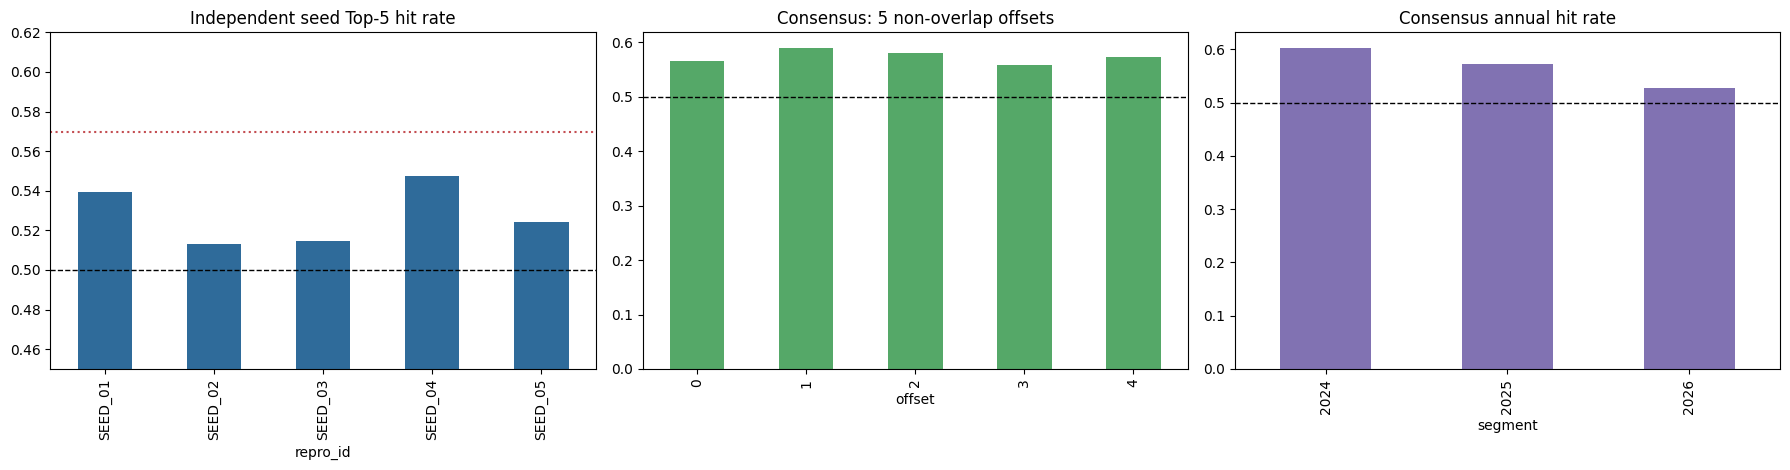

In [ ]:
# Prevent a stale v1.0.2 function from reaching the stress test.
RANK_IMPLEMENTATION_AUDIT = assert_columnless_rank_implementation()
assert RANK_IMPLEMENTATION_AUDIT["pass"], RANK_IMPLEMENTATION_AUDIT

STRESS_SPECS = [
    ("BASE_TOP5_COST1_UNIV100", 5, 1.0, 1.0),
    ("COST_1_5X", 5, 1.5, 1.0),
    ("COST_2_0X", 5, 2.0, 1.0),
    ("TOP3", 3, 1.0, 1.0),
    ("TOP10", 10, 1.0, 1.0),
    ("UNIVERSE_KEEP_90", 5, 1.0, 0.9),
    ("UNIVERSE_KEEP_80", 5, 1.0, 0.8),
]
STRESS_ROWS = []
for name, k, cost_mult, keep in STRESS_SPECS:
    d = build_topk_daily(OOS_WITH_CONSENSUS, "CONSENSUS", k, cost_mult, keep, name)
    STRESS_ROWS.append({**summarize_daily(d), "top_k": k, "cost_multiplier": cost_mult, "universe_keep": keep})
STRESS_RESULTS = pd.DataFrame(STRESS_ROWS)


def frame_fingerprint(source: str, ticker: str, df: pd.DataFrame) -> dict:
    q = df.copy().sort_index()
    cols = [c for c in ["Open", "High", "Low", "Close", "Adj Close", "Volume"] if c in q.columns]
    canonical = q[cols].copy()
    canonical.index = pd.to_datetime(canonical.index).tz_localize(None)
    canonical.index.name = "date"
    payload = canonical.round(8).to_csv(date_format="%Y-%m-%d").encode("utf-8")
    return {
        "source_group": source, "ticker": ticker, "rows": len(canonical),
        "first_date": canonical.index.min() if len(canonical) else pd.NaT,
        "last_date": canonical.index.max() if len(canonical) else pd.NaT,
        "columns": "|".join(cols), "sha256": hashlib.sha256(payload).hexdigest(),
    }


manifest_rows = []
for source_name, mapping in [("KR_STOCK", kr_data), ("US_STOCK", us_data), ("MARKET", market_data)]:
    for ticker, frame in sorted(mapping.items()):
        manifest_rows.append(frame_fingerprint(source_name, str(ticker), frame))
DATA_SNAPSHOT_MANIFEST = pd.DataFrame(manifest_rows)
snapshot_payload = "\n".join(
    DATA_SNAPSHOT_MANIFEST.sort_values(["source_group", "ticker"])
    .apply(lambda r: f'{r["source_group"]}|{r["ticker"]}|{r["sha256"]}', axis=1)
).encode()
DATA_SNAPSHOT_ID = hashlib.sha256(snapshot_payload).hexdigest()
if DATA_SNAPSHOT_ID != FROZEN_SNAPSHOT_ID:
    raise RuntimeError(
        f"학습 중 원천 OHLCV가 불변 스냅샷과 달라졌습니다: computed={DATA_SNAPSHOT_ID}, frozen={FROZEN_SNAPSHOT_ID}"
    )


seed_only = SEED_RESULTS[SEED_RESULTS["repro_id"].isin(SEED_IDS)].copy()
cons = SEED_RESULTS[SEED_RESULTS["repro_id"].eq("CONSENSUS")].iloc[0]
boot_cons = BLOCK_BOOTSTRAP_CI[BLOCK_BOOTSTRAP_CI["repro_id"].eq("CONSENSUS")].iloc[0]
offset_cons = NONOVERLAP_RESULTS[NONOVERLAP_RESULTS["repro_id"].eq("CONSENSUS")]
pair_rank = PAIRWISE_STABILITY["mean_daily_rank_spearman"].median() if len(PAIRWISE_STABILITY) else np.nan
pair_jacc = PAIRWISE_STABILITY["mean_top5_jaccard"].median() if len(PAIRWISE_STABILITY) else np.nan
year_cons = YEAR_REGIME_RESULTS[(YEAR_REGIME_RESULTS["repro_id"].eq("CONSENSUS")) & YEAR_REGIME_RESULTS["segment_type"].eq("YEAR") & (YEAR_REGIME_RESULTS["active_days"] >= 60)]
regime_cons = YEAR_REGIME_RESULTS[(YEAR_REGIME_RESULTS["repro_id"].eq("CONSENSUS")) & YEAR_REGIME_RESULTS["segment_type"].eq("REGIME") & YEAR_REGIME_RESULTS["segment"].isin(["BULL", "BEAR"]) & (YEAR_REGIME_RESULTS["active_days"] >= 40)]
original_seed_hit = float(seed_only.loc[seed_only["repro_id"].eq("SEED_01"), "portfolio_hit_rate"].iloc[0])
determinism_pass = bool(len(DETERMINISM_AUDIT) and DETERMINISM_AUDIT["determinism_pass"].iloc[0])

CHECKS = {
    "single_frozen_family_only": len(FAMILY_SPECS) == 1 and FAMILY_SPECS[0].name == TIMEDART_FAMILY,
    "all_blocks_purged": bool(WF_AUDIT["purge_ok"].all()),
    "exact_repeat_deterministic": determinism_pass,
    "original_seed_hit_within_2_5pp_of_v63": abs(original_seed_hit - FROZEN_PROTOCOL["original_observed_hit_rate_reference"]) <= FROZEN_PROTOCOL["benchmark_tolerance_pp"],
    "independent_seed_median_hit_at_least_54pct": seed_only["portfolio_hit_rate"].median() >= FROZEN_PROTOCOL["minimum_seed_median_hit"],
    "at_least_80pct_seeds_above_50pct": (seed_only["portfolio_hit_rate"] > 0.5).mean() >= FROZEN_PROTOCOL["minimum_positive_seed_fraction"],
    "consensus_hit_HAC_t_at_least_1_64": cons["hit_HAC_t_vs_50"] >= FROZEN_PROTOCOL["minimum_consensus_hit_hac_t"],
    "consensus_bootstrap_90pct_hit_lower_above_50pct": boot_cons["hit_ci_low"] > FROZEN_PROTOCOL["minimum_bootstrap_hit_lower"],
    "all_five_nonoverlap_offsets_above_50pct": offset_cons["portfolio_hit_rate"].min() > FROZEN_PROTOCOL["minimum_nonoverlap_offset_hit"],
    "all_qualified_years_above_50pct": len(year_cons) >= 2 and (year_cons["portfolio_hit_rate"] > 0.5).all(),
    "bull_and_bear_above_50pct": set(regime_cons["segment"]) == {"BULL", "BEAR"} and (regime_cons["portfolio_hit_rate"] > 0.5).all(),
    "median_pairwise_rank_spearman_at_least_0_65": pair_rank >= FROZEN_PROTOCOL["minimum_pairwise_rank_spearman"],
    "median_pairwise_top5_jaccard_at_least_0_35": pair_jacc >= FROZEN_PROTOCOL["minimum_pairwise_top5_jaccard"],
}
REPRO_CHECKS = pd.DataFrame([{"check": k, "passed": bool(v)} for k, v in CHECKS.items()])

core_names = [
    "single_frozen_family_only", "all_blocks_purged", "exact_repeat_deterministic",
    "original_seed_hit_within_2_5pp_of_v63", "independent_seed_median_hit_at_least_54pct",
    "at_least_80pct_seeds_above_50pct", "consensus_hit_HAC_t_at_least_1_64",
    "consensus_bootstrap_90pct_hit_lower_above_50pct", "all_five_nonoverlap_offsets_above_50pct",
    "all_qualified_years_above_50pct", "bull_and_bear_above_50pct",
    "median_pairwise_rank_spearman_at_least_0_65", "median_pairwise_top5_jaccard_at_least_0_35",
]
core_pass_count = sum(CHECKS[k] for k in core_names)
if core_pass_count == len(core_names):
    REPRO_STATUS = "REPRODUCED_DIRECTIONAL_EDGE"
elif CHECKS["all_blocks_purged"] and CHECKS["at_least_80pct_seeds_above_50pct"] and core_pass_count >= 9:
    REPRO_STATUS = "PARTIALLY_REPRODUCED_RANK_EDGE"
else:
    REPRO_STATUS = "NOT_REPRODUCED"

cost15 = STRESS_RESULTS[STRESS_RESULTS["scenario"].eq("COST_1_5X")].iloc[0]
if cons["mean_net_return"] > 0 and cons["return_HAC_t"] >= 1.64 and cost15["mean_net_return"] > 0:
    PROFITABILITY_EVIDENCE = "STRONG_RETURN_SIGNIFICANCE"
elif cons["mean_net_return"] > 0 and cost15["mean_net_return"] > 0:
    PROFITABILITY_EVIDENCE = "WEAK_RETURN_SIGNIFICANCE"
else:
    PROFITABILITY_EVIDENCE = "NO_ROBUST_COST_AFTER_RETURN_EVIDENCE"

REPRO_PRIMARY_TEST = pd.DataFrame([{
    "protocol_version": FROZEN_PROTOCOL["protocol_version"],
    "data_snapshot_id": DATA_SNAPSHOT_ID,
    "repro_profile": REPRO_PROFILE,
    "independent_seed_runs": len(SEED_IDS),
    "original_seed_hit_rate": original_seed_hit,
    "independent_seed_median_hit_rate": seed_only["portfolio_hit_rate"].median(),
    "independent_seed_min_hit_rate": seed_only["portfolio_hit_rate"].min(),
    "independent_seed_max_hit_rate": seed_only["portfolio_hit_rate"].max(),
    "consensus_hit_rate": cons["portfolio_hit_rate"],
    "consensus_hit_HAC_t_vs_50": cons["hit_HAC_t_vs_50"],
    "consensus_hit_HAC_p_one_sided": cons["hit_HAC_p_one_sided"],
    "consensus_bootstrap_hit_ci_low": boot_cons["hit_ci_low"],
    "consensus_bootstrap_hit_ci_high": boot_cons["hit_ci_high"],
    "consensus_mean_net_return": cons["mean_net_return"],
    "consensus_return_HAC_t": cons["return_HAC_t"],
    "median_pairwise_rank_spearman": pair_rank,
    "median_pairwise_top5_jaccard": pair_jacc,
    "checks_passed": core_pass_count,
    "checks_total": len(core_names),
    "reproducibility_status": REPRO_STATUS,
    "profitability_evidence": PROFITABILITY_EVIDENCE,
    "interpretation_rule": "방향 재현성과 비용후 수익 유의성을 분리 판정; stress 결과로 모델/임계값을 재선택하지 않음",
}])

print(f"\n[FINAL] {REPRO_STATUS} / {PROFITABILITY_EVIDENCE}")
display(REPRO_PRIMARY_TEST)
display(REPRO_CHECKS)
display(STRESS_RESULTS)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
seed_only.plot.bar(x="repro_id", y="portfolio_hit_rate", ax=axes[0], legend=False, color="#2f6b9a")
axes[0].axhline(.5, color="black", ls="--", lw=1); axes[0].axhline(.569659, color="#c44e52", ls=":", lw=1.5)
axes[0].set_title("Independent seed Top-5 hit rate"); axes[0].set_ylim(.45, max(.62, seed_only["portfolio_hit_rate"].max() + .03))
offset_cons.plot.bar(x="offset", y="portfolio_hit_rate", ax=axes[1], legend=False, color="#55a868")
axes[1].axhline(.5, color="black", ls="--", lw=1); axes[1].set_title("Consensus: 5 non-overlap offsets")
year_cons.plot.bar(x="segment", y="portfolio_hit_rate", ax=axes[2], legend=False, color="#8172b2")
axes[2].axhline(.5, color="black", ls="--", lw=1); axes[2].set_title("Consensus annual hit rate")
plt.tight_layout()


## 13. Legacy / TimeDART 연구 산출물 저장

다음 실행과 비교할 때는 `data_snapshot_id`가 같은지 먼저 확인합니다. 같으면 모델/연산 재현성 비교이고, 다르면 Yahoo/FDR 구성종목·가격 수정까지 섞인 재현성 비교입니다.


In [ ]:

OUTPUT_DIR = Path(CFG.output_dir)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with (OUTPUT_DIR / "frozen_protocol.json").open("w", encoding="utf-8") as f:
    json.dump(FROZEN_PROTOCOL, f, ensure_ascii=False, indent=2, default=str)
with (OUTPUT_DIR / "run_identity.json").open("w", encoding="utf-8") as f:
    json.dump({
        "data_snapshot_id": DATA_SNAPSHOT_ID,
        "reproducibility_status": REPRO_STATUS,
        "profitability_evidence": PROFITABILITY_EVIDENCE,
        "run_at_utc": datetime.now(UTC).isoformat(),
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
        "config": asdict(CFG),
    }, f, ensure_ascii=False, indent=2, default=str)

WF_AUDIT.to_csv(OUTPUT_DIR / "walk_forward_purge_audit.csv", index=False)
SEED_RESULTS.to_csv(OUTPUT_DIR / "repro_seed_results.csv", index=False)
REPRO_PRIMARY_TEST.to_csv(OUTPUT_DIR / "repro_primary_test.csv", index=False)
REPRO_CHECKS.to_csv(OUTPUT_DIR / "repro_pass_fail_checks.csv", index=False)
PAIRWISE_STABILITY.to_csv(OUTPUT_DIR / "repro_pairwise_rank_stability.csv", index=False)
DETERMINISM_AUDIT.to_csv(OUTPUT_DIR / "repro_determinism_audit.csv", index=False)
NONOVERLAP_RESULTS.to_csv(OUTPUT_DIR / "repro_nonoverlap_offsets.csv", index=False)
BLOCK_BOOTSTRAP_CI.to_csv(OUTPUT_DIR / "repro_block_bootstrap_ci.csv", index=False)
YEAR_REGIME_RESULTS.to_csv(OUTPUT_DIR / "repro_year_regime_results.csv", index=False)
STRESS_RESULTS.to_csv(OUTPUT_DIR / "repro_stress_results.csv", index=False)
DATA_SNAPSHOT_MANIFEST.to_csv(OUTPUT_DIR / "data_snapshot_manifest.csv", index=False)
FROZEN_SNAPSHOT_MANIFEST.to_csv(OUTPUT_DIR / "frozen_snapshot_manifest.csv", index=False)
(OUTPUT_DIR / "frozen_snapshot_contract.json").write_text(
    json.dumps(FROZEN_SNAPSHOT_CONTRACT, ensure_ascii=False, indent=2), encoding="utf-8"
)
(OUTPUT_DIR / "stability_protocol.json").write_text(
    json.dumps({**STABILITY_PROTOCOL, "protocol_hash": STABILITY_PROTOCOL_HASH}, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
STABILITY_PORTFOLIO_SUMMARY.to_csv(OUTPUT_DIR / "stability_portfolio_summary.csv", index=False)
STABILITY_GATE_AUDIT.to_csv(OUTPUT_DIR / "stability_gate_audit.csv", index=False)
STABILITY_CANDIDATES.to_csv(OUTPUT_DIR / "stability_candidates_oos.csv", index=False)
QUALIFIED_TOP5_DAILY.to_csv(OUTPUT_DIR / "qualified_top5_oos_daily.csv", index=False)
MARGIN_AUDIT.to_csv(OUTPUT_DIR / "causal_margin_audit.csv", index=False)
SEED_TOP5_MEMBERSHIP.to_csv(OUTPUT_DIR / "seed_top5_membership.csv", index=False)
ROBUSTNESS_COMPARISON.to_csv(OUTPUT_DIR / "robustness_comparison.csv", index=False)
ROBUSTNESS_AUDIT.to_csv(OUTPUT_DIR / "robustness_walk_forward_audit.csv", index=False)
if len(ROBUSTNESS_OOS):
    ROBUSTNESS_OOS.to_parquet(OUTPUT_DIR / "robustness_oos_predictions.parquet", index=False)
LIVE_RECOMMENDATIONS.to_csv(OUTPUT_DIR / "live_stability_recommendations.csv", index=False)
FUTURE_LEDGER.to_csv(OUTPUT_DIR / "future_oos_prediction_ledger.csv", index=False)
FUTURE_SCORECARD.to_csv(OUTPUT_DIR / "future_oos_scorecard.csv", index=False)
FUTURE_OOS_DAILY.to_csv(OUTPUT_DIR / "future_oos_daily.csv", index=False)
PRIMARY_DAILY.to_csv(OUTPUT_DIR / "repro_top5_daily.csv", index=False)
EMPTY_SELECTION_DAYS.to_csv(OUTPUT_DIR / "repro_inactive_selection_days.csv", index=False)
OOS_WITH_CONSENSUS.to_parquet(OUTPUT_DIR / "timedart_us5_repro_oos_predictions.parquet", index=False)
plt.gcf().savefig(OUTPUT_DIR / "reproducibility_dashboard.png", dpi=170, bbox_inches="tight")

zip_path = Path("/content/timedart_v63_stability_first_v1_2_outputs.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for path in sorted(OUTPUT_DIR.rglob("*")):
        if path.is_file():
            zf.write(path, path.relative_to(OUTPUT_DIR))

print("saved:", OUTPUT_DIR)
print("zip:", zip_path)
print("data_snapshot_id:", DATA_SNAPSHOT_ID)
display(REPRO_PRIMARY_TEST)


saved: /content/timedart_v63_strict_pit_v1_3_outputs
zip: /content/timedart_v63_stability_first_v1_2_outputs.zip
data_snapshot_id: 8d3eeac2533ca9aac8330e62c3aae9f1419ef3e39e3143f5f86ed8246305b3e5


,protocol_version,data_snapshot_id,repro_profile,independent_seed_runs,original_seed_hit_rate,independent_seed_median_hit_rate,independent_seed_min_hit_rate,independent_seed_max_hit_rate,consensus_hit_rate,consensus_hit_HAC_t_vs_50,consensus_hit_HAC_p_one_sided,consensus_bootstrap_hit_ci_low,consensus_bootstrap_hit_ci_high,consensus_mean_net_return,consensus_return_HAC_t,median_pairwise_rank_spearman,median_pairwise_top5_jaccard,checks_passed,checks_total,reproducibility_status,profitability_evidence,interpretation_rule
0,TIMEDART_V63_STRICT_PIT_REPRO_V1_3,8d3eeac2533ca9aac8330e62c3aae9f1419ef3e39e3143...,STANDARD,5,0.539535,0.524031,0.513178,0.547287,0.573643,2.782168,0.0027,0.531783,0.615504,0.002081,1.319947,0.233231,0.077381,9,13,PARTIALLY_REPRODUCED_RANK_EDGE,WEAK_RETURN_SIGNIFICANCE,방향 재현성과 비용후 수익 유의성을 분리 판정; stress 결과로 모델/임계값을 ...


<Figure size 1300x500 with 0 Axes>

## 14. Strict Point-in-Time Leakage Audit

이 셀은 결과 성능과 무관하게 데이터·분할 계약을 별도로 검사합니다. 하나라도 실패하면 strict OOS 결과를 신뢰하지 않습니다.


In [ ]:
LEAKAGE_AUDIT = pd.DataFrame([
    {
        "check": "STRICT_MODE_ENABLED",
        "pass": bool(CFG.strict_leakage_guard),
        "detail": str(CFG.strict_leakage_guard),
    },
    {
        "check": "US_UNIVERSE_FROZEN_BEFORE_OOS",
        "pass": bool(
            pd.Timestamp(CFG.pit_us_universe_freeze_date) < pd.Timestamp(CFG.oos_start)
            and FROZEN_SNAPSHOT_CONTRACT.get("us_universe_policy") == CFG.pit_us_universe_protocol
        ),
        "detail": f"freeze={CFG.pit_us_universe_freeze_date}, oos_start={CFG.oos_start}",
    },
    {
        "check": "NO_MANUAL_2026_US_CORE_IN_HISTORICAL_OOS",
        "pass": FROZEN_SNAPSHOT_CONTRACT.get("manual_us_core_in_historical_oos") is False,
        "detail": str(FROZEN_SNAPSHOT_CONTRACT.get("manual_us_core_in_historical_oos")),
    },
    {
        "check": "TRAIN_TEST_LABEL_EXIT_PURGED",
        "pass": bool(WF_AUDIT["purge_ok"].all()),
        "detail": f"blocks={len(WF_AUDIT)}",
    },
    {
        "check": "FIT_CALIBRATION_LABEL_EXIT_PURGED",
        "pass": bool(WF_AUDIT["fit_calibration_purge_ok"].all()),
        "detail": f"blocks={len(WF_AUDIT)}",
    },
    {
        "check": "NO_INNER_LABEL_EARLY_STOPPING",
        "pass": bool(WF_AUDIT["inner_early_stopping_disabled"].all()),
        "detail": "fixed predeclared epoch count in strict mode",
    },
    {
        "check": "CROSS_MARKET_AVAILABLE_BEFORE_DECISION",
        "pass": bool(
            (KR_PANEL["us_available_at"].dropna() <= KR_PANEL.loc[KR_PANEL["us_available_at"].notna(), "decision_at"]).all()
            and (US_PANEL["kr_available_at"].dropna() <= US_PANEL.loc[US_PANEL["kr_available_at"].notna(), "decision_at"]).all()
        ),
        "detail": "merge_asof backward + timestamp assertions",
    },
])
display(LEAKAGE_AUDIT)
if CFG.strict_leakage_guard and not bool(LEAKAGE_AUDIT["pass"].all()):
    raise RuntimeError("STRICT PIT leakage audit failed: " + str(LEAKAGE_AUDIT.loc[~LEAKAGE_AUDIT["pass"], "check"].tolist()))
print("[LEAKAGE AUDIT] PASS — no known code-level look-ahead under the frozen-source contract")
print("External limitation: Yahoo/Wikipedia are not vendor-vintage archives; retrospective source corrections cannot be ruled out by code alone.")


,check,pass,detail
0,STRICT_MODE_ENABLED,True,True
1,US_UNIVERSE_FROZEN_BEFORE_OOS,True,"freeze=2023-12-31, oos_start=2024-01-01"
2,NO_MANUAL_2026_US_CORE_IN_HISTORICAL_OOS,True,False
3,TRAIN_TEST_LABEL_EXIT_PURGED,True,blocks=18
4,FIT_CALIBRATION_LABEL_EXIT_PURGED,True,blocks=18
5,NO_INNER_LABEL_EARLY_STOPPING,True,fixed predeclared epoch count in strict mode
6,CROSS_MARKET_AVAILABLE_BEFORE_DECISION,True,merge_asof backward + timestamp assertions


[LEAKAGE AUDIT] PASS — no known code-level look-ahead under the frozen-source contract
External limitation: Yahoo/Wikipedia are not vendor-vintage archives; retrospective source corrections cannot be ruled out by code alone.


## 15. Diagnostic Top-5 탐색 대시보드

첫 번째 화면은 Raw/Qualified 포트폴리오의 누적 성과·적중률·낙폭과 반복 선택 종목을 보여줍니다. 두 번째 화면의 날짜 드롭다운에서 해당 진입일의 Top-5 종목, 종목별 5일 총수익·비용후 수익, 시드 투표수, 순위점수와 Qualified 여부를 확인할 수 있습니다. Qualified 신호가 없던 날짜도 Raw Top-5 진단 결과와 차단 사유를 그대로 표시합니다.


In [ ]:
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

DASHBOARD_DATE_LIMIT = int(os.getenv("TIMEDART_DASHBOARD_DATE_LIMIT", "120"))


def dashboard_portfolio_summary(daily: pd.DataFrame, label: str) -> dict:
    q = daily.copy().sort_values("entry_date")
    active = q.dropna(subset=["event_net_return"]).copy()
    capital = q.get("capital_scaled_return", q["event_net_return"] / 5).fillna(0.0)
    wealth = np.exp(capital.cumsum())
    drawdown = wealth / wealth.cummax() - 1
    return {
        "portfolio": label,
        "calendar_days": int(q["entry_date"].nunique()),
        "active_days": int(len(active)),
        "active_fraction": float(len(active) / max(q["entry_date"].nunique(), 1)),
        "portfolio_hit_rate": float(active["portfolio_hit"].mean()) if len(active) else np.nan,
        "mean_net_return_5d": float(active["event_net_return"].mean()) if len(active) else np.nan,
        "median_net_return_5d": float(active["event_net_return"].median()) if len(active) else np.nan,
        "cumulative_capital_return": float(wealth.iloc[-1] - 1) if len(wealth) else np.nan,
        "max_drawdown": float(drawdown.min()) if len(drawdown) else np.nan,
        "first_active_date": active["entry_date"].min() if len(active) else pd.NaT,
        "last_active_date": active["entry_date"].max() if len(active) else pd.NaT,
    }


def dashboard_path(daily: pd.DataFrame, label: str) -> pd.DataFrame:
    q = daily.copy().sort_values("entry_date")
    q["entry_date"] = pd.to_datetime(q["entry_date"]).dt.tz_localize(None).dt.normalize()
    q["capital_return"] = q.get("capital_scaled_return", q["event_net_return"] / 5).fillna(0.0)
    q["wealth"] = np.exp(q["capital_return"].cumsum())
    q["drawdown"] = q["wealth"] / q["wealth"].cummax() - 1
    active_hit = q["portfolio_hit"].dropna()
    rolling = active_hit.rolling(60, min_periods=30).mean()
    q["rolling_60_active_hit"] = np.nan
    q.loc[rolling.index, "rolling_60_active_hit"] = rolling
    q["portfolio"] = label
    return q


RAW_DASH_PATH = dashboard_path(RAW_CONSENSUS_DAILY, "RAW_TOP5")
QUALIFIED_DASH_PATH = dashboard_path(QUALIFIED_TOP5_DAILY, "QUALIFIED_TOP5")
DASHBOARD_SUMMARY = pd.DataFrame([
    dashboard_portfolio_summary(RAW_CONSENSUS_DAILY, "RAW_TOP5_DIAGNOSTIC"),
    dashboard_portfolio_summary(QUALIFIED_TOP5_DAILY, "QUALIFIED_TOP5"),
])

DASHBOARD_TOP5_DETAIL = STABILITY_CANDIDATES[
    STABILITY_CANDIDATES["raw_top5"].fillna(False)
].copy()
DASHBOARD_TOP5_DETAIL["entry_date"] = pd.to_datetime(
    DASHBOARD_TOP5_DETAIL["entry_date"]
).dt.tz_localize(None).dt.normalize()
DASHBOARD_TOP5_DETAIL["gross_return_5d"] = pd.to_numeric(
    DASHBOARD_TOP5_DETAIL["target_5d"], errors="coerce"
)
DASHBOARD_TOP5_DETAIL["net_return_5d"] = (
    DASHBOARD_TOP5_DETAIL["gross_return_5d"]
    - pd.to_numeric(DASHBOARD_TOP5_DETAIL["cost"], errors="coerce")
)
DASHBOARD_TOP5_DETAIL["constituent_hit"] = DASHBOARD_TOP5_DETAIL["net_return_5d"].gt(0)
DASHBOARD_TOP5_DETAIL["qualified_selected"] = DASHBOARD_TOP5_DETAIL[
    "qualified_selected"
].fillna(False).astype(bool)

DASHBOARD_SELECTION_STATS = (
    DASHBOARD_TOP5_DETAIL.groupby(["ticker", "name"], as_index=False)
    .agg(
        raw_top5_selections=("entry_date", "nunique"),
        qualified_selections=("qualified_selected", "sum"),
        mean_gross_return_5d=("gross_return_5d", "mean"),
        mean_net_return_5d=("net_return_5d", "mean"),
        constituent_hit_rate=("constituent_hit", "mean"),
        mean_selection_votes=("selection_votes", "mean"),
        mean_consensus_rank_score=("consensus_rank_score", "mean"),
    )
    .sort_values(["raw_top5_selections", "mean_net_return_5d"], ascending=[False, False])
)

# 1) 포트폴리오 전체 경로와 반복 선택 종목
overview = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "비용후 누적자본 경로", "최근 60개 활성 신호 적중률",
        "누적자본 최대낙폭", "반복 선택 횟수와 종목별 평균 비용후 수익",
    ),
    vertical_spacing=.15, horizontal_spacing=.10,
)
for frame, label, color in [
    (RAW_DASH_PATH, "Raw Top-5", "#4c78a8"),
    (QUALIFIED_DASH_PATH, "Qualified Top-5", "#f58518"),
]:
    overview.add_trace(
        go.Scatter(
            x=frame["entry_date"], y=frame["wealth"], mode="lines", name=label,
            line=dict(color=color, width=2),
            hovertemplate="%{x|%Y-%m-%d}<br>자본배수 %{y:.3f}<extra>" + label + "</extra>",
        ), row=1, col=1,
    )
    overview.add_trace(
        go.Scatter(
            x=frame["entry_date"], y=frame["rolling_60_active_hit"], mode="lines", name=label,
            line=dict(color=color, width=2), showlegend=False,
            hovertemplate="%{x|%Y-%m-%d}<br>60신호 적중률 %{y:.1%}<extra>" + label + "</extra>",
        ), row=1, col=2,
    )
    overview.add_trace(
        go.Scatter(
            x=frame["entry_date"], y=frame["drawdown"], mode="lines", name=label,
            line=dict(color=color, width=2), fill="tozeroy", opacity=.75, showlegend=False,
            hovertemplate="%{x|%Y-%m-%d}<br>낙폭 %{y:.1%}<extra>" + label + "</extra>",
        ), row=2, col=1,
    )

selection_plot = DASHBOARD_SELECTION_STATS.head(20).copy()
overview.add_trace(
    go.Scatter(
        x=selection_plot["raw_top5_selections"],
        y=selection_plot["mean_net_return_5d"],
        mode="markers+text",
        text=selection_plot["ticker"], textposition="top center",
        marker=dict(
            size=np.clip(8 + 18 * selection_plot["constituent_hit_rate"].fillna(.5), 8, 28),
            color=selection_plot["constituent_hit_rate"], colorscale="RdYlGn",
            cmin=.35, cmax=.65, showscale=True,
            colorbar=dict(title="종목 적중률", tickformat=".0%", len=.34, y=.20),
        ),
        customdata=np.column_stack([
            selection_plot["name"].astype(str), selection_plot["qualified_selections"],
            selection_plot["constituent_hit_rate"], selection_plot["mean_selection_votes"],
        ]),
        hovertemplate=(
            "%{text} · %{customdata[0]}<br>Raw 선택 %{x:.0f}회"
            "<br>Qualified 선택 %{customdata[1]:.0f}회"
            "<br>평균 비용후 5D %{y:.2%}<br>종목 적중률 %{customdata[2]:.1%}"
            "<br>평균 시드투표 %{customdata[3]:.2f}<extra></extra>"
        ),
        showlegend=False,
    ), row=2, col=2,
)
overview.add_hline(y=.50, line_dash="dash", line_width=1, line_color="#888", row=1, col=2)
overview.add_hline(y=0, line_width=1, line_color="#888", row=2, col=1)
overview.add_hline(y=0, line_width=1, line_color="#888", row=2, col=2)
overview.update_yaxes(tickformat=".0%", row=1, col=2)
overview.update_yaxes(tickformat=".0%", row=2, col=1)
overview.update_yaxes(tickformat=".1%", row=2, col=2)
overview.update_layout(
    title="TimeDART US 5D · Stability-First 포트폴리오 대시보드",
    height=820, template="plotly_white", hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    margin=dict(l=50, r=50, t=100, b=50),
)

# 2) 날짜를 바꿔가며 실제 Top-5 구성과 종목별 수익률 확인
all_dates = sorted(DASHBOARD_TOP5_DETAIL["entry_date"].dropna().unique())
explore_dates = all_dates[-DASHBOARD_DATE_LIMIT:]
explorer = make_subplots(
    rows=2, cols=1, specs=[[{"type": "xy"}], [{"type": "table"}]],
    row_heights=[.52, .48], vertical_spacing=.08,
)
date_titles, date_groups = [], []
for entry_date in explore_dates:
    g = DASHBOARD_TOP5_DETAIL[DASHBOARD_TOP5_DETAIL["entry_date"].eq(entry_date)].copy()
    g = g.sort_values(["consensus_rank_score", "ticker"], ascending=[False, True]).head(CFG.top_k)
    g["display_rank"] = np.arange(1, len(g) + 1)
    qualified = bool(g["qualified_top5_date"].iloc[0]) if len(g) else False
    reason = str(g["qualification_reason"].iloc[0]) if len(g) else "NO_RAW_TOP5"
    gross = float(g["gross_return_5d"].mean()) if len(g) else np.nan
    net = float(g["net_return_5d"].mean()) if len(g) else np.nan
    status = "QUALIFIED" if qualified else "NO_TRADE"
    date_label = pd.Timestamp(entry_date).strftime("%Y-%m-%d")
    date_titles.append(
        f"{date_label} · {status} · Top-5 평균 총수익 {gross:.2%} · 비용후 {net:.2%} · {reason}"
    )
    date_groups.append(g)

for i, (title, g) in enumerate(zip(date_titles, date_groups)):
    visible = i == len(date_groups) - 1
    colors = np.where(g["net_return_5d"].isna(), "#999999", np.where(g["net_return_5d"] >= 0, "#2ca02c", "#d62728"))
    explorer.add_trace(
        go.Bar(
            x=g["ticker"], y=g["net_return_5d"], visible=visible,
            marker_color=colors,
            customdata=np.column_stack([
                g["name"].astype(str), g["gross_return_5d"], g["cost"],
                g["selection_votes"], g["consensus_rank_score"], g["qualified_selected"].astype(str),
            ]),
            hovertemplate=(
                "%{x} · %{customdata[0]}<br>비용후 5D %{y:.2%}"
                "<br>총수익 %{customdata[1]:.2%}<br>비용 %{customdata[2]:.2%}"
                "<br>시드투표 %{customdata[3]:.0f}/" + str(len(SEED_IDS)) +
                "<br>순위점수 %{customdata[4]:.4f}<br>Qualified 종목 %{customdata[5]}<extra></extra>"
            ),
            showlegend=False,
        ), row=1, col=1,
    )
    explorer.add_trace(
        go.Table(
            visible=visible,
            header=dict(values=[
                "순위", "티커", "종목명", "총수익 5D", "비용후 5D", "적중",
                "시드투표", "순위점수", "Qualified",
            ]),
            cells=dict(values=[
                g["display_rank"], g["ticker"], g["name"],
                g["gross_return_5d"].map(lambda x: "—" if pd.isna(x) else f"{x:.2%}"),
                g["net_return_5d"].map(lambda x: "—" if pd.isna(x) else f"{x:.2%}"),
                g["constituent_hit"].map({True: "HIT", False: "MISS"}),
                g["selection_votes"].map(lambda x: f"{int(x)}/{len(SEED_IDS)}"),
                g["consensus_rank_score"].map(lambda x: f"{x:.4f}"),
                g["qualified_selected"].map({True: "YES", False: "NO"}),
            ]),
        ), row=2, col=1,
    )

if date_groups:
    buttons = []
    n_traces = 2 * len(date_groups)
    for i, title in enumerate(date_titles):
        trace_visibility = [False] * n_traces
        trace_visibility[2 * i] = True
        trace_visibility[2 * i + 1] = True
        buttons.append(dict(
            label=pd.Timestamp(explore_dates[i]).strftime("%Y-%m-%d"), method="update",
            args=[{"visible": trace_visibility}, {"title": title}],
        ))
    explorer.update_layout(
        title=date_titles[-1],
        updatemenus=[dict(
            buttons=buttons, direction="down", showactive=True,
            x=0, xanchor="left", y=1.16, yanchor="top",
        )],
    )
else:
    explorer.add_annotation(text="표시할 Raw Top-5 OOS 결과가 없습니다", x=.5, y=.5, showarrow=False)
    explorer.update_layout(title="날짜별 Top-5 구성")
# NOTE: explorer mixes an XY subplot (row 1) with go.Table (row 2).
# Some Plotly versions make add_hline(..., row=1, col=1) inspect every trace,
# then fail on go.Table because Table has no xaxis/yaxis properties.
# Bind the zero line directly to the first XY axes instead.
explorer.add_shape(
    type="line",
    x0=0, x1=1, y0=0, y1=0,
    xref="x domain", yref="y",
    line=dict(width=1, color="#888"),
)
explorer.update_yaxes(tickformat=".1%", title_text="비용후 5일 수익률", row=1, col=1)
explorer.update_layout(
    height=780, template="plotly_white", margin=dict(l=40, r=30, t=120, b=30),
)

# 3) 현재 예측 및 만기된 미래 OOS를 표로 함께 보존
if len(LIVE_RECOMMENDATIONS):
    LIVE_DASHBOARD_TABLE = LIVE_RECOMMENDATIONS[
        LIVE_RECOMMENDATIONS["raw_top5"].fillna(False)
    ][[
        "entry_date", "ticker", "name", "group", "selection_votes",
        "consensus_rank_score", "pred_relative_alpha", "pred_return",
        "qualified_top5", "qualified_top5_available", "boundary_margin",
        "margin_threshold", "qualification_reason",
    ]].copy()
else:
    LIVE_DASHBOARD_TABLE = pd.DataFrame(columns=[
        "entry_date", "ticker", "name", "group", "selection_votes",
        "consensus_rank_score", "pred_relative_alpha", "pred_return",
        "qualified_top5", "qualified_top5_available", "boundary_margin",
        "margin_threshold", "qualification_reason",
    ])

latest_date = DASHBOARD_TOP5_DETAIL["entry_date"].max() if len(DASHBOARD_TOP5_DETAIL) else pd.NaT
DASHBOARD_LATEST_TOP5 = (
    DASHBOARD_TOP5_DETAIL[DASHBOARD_TOP5_DETAIL["entry_date"].eq(latest_date)].copy()
    if pd.notna(latest_date) else DASHBOARD_TOP5_DETAIL.iloc[0:0].copy()
)

display(DASHBOARD_SUMMARY.style.format({
    "active_fraction": "{:.1%}", "portfolio_hit_rate": "{:.1%}",
    "mean_net_return_5d": "{:.2%}", "median_net_return_5d": "{:.2%}",
    "cumulative_capital_return": "{:.1%}", "max_drawdown": "{:.1%}",
}, na_rep="—"))
overview.show()
explorer.show()
print("[LIVE RAW/QUALIFIED TOP-5]")
display(LIVE_DASHBOARD_TABLE)
if len(FUTURE_OOS_DAILY):
    print("[MATURED FUTURE OOS — 최근 20건]")
    display(FUTURE_OOS_DAILY.sort_values("entry_date").tail(20))

# 분석용 테이블과 대시보드 HTML을 결과 디렉터리에 저장합니다.
DASHBOARD_SUMMARY.to_csv(OUTPUT_DIR / "dashboard_portfolio_summary.csv", index=False)
DASHBOARD_TOP5_DETAIL.to_csv(OUTPUT_DIR / "dashboard_top5_constituent_history.csv", index=False)
DASHBOARD_SELECTION_STATS.to_csv(OUTPUT_DIR / "dashboard_ticker_selection_stats.csv", index=False)
DASHBOARD_LATEST_TOP5.to_csv(OUTPUT_DIR / "dashboard_latest_oos_top5.csv", index=False)
LIVE_DASHBOARD_TABLE.to_csv(OUTPUT_DIR / "dashboard_live_top5.csv", index=False)

summary_html = DASHBOARD_SUMMARY.to_html(index=False, float_format=lambda x: f"{x:.6f}")
live_html = LIVE_DASHBOARD_TABLE.to_html(index=False) if len(LIVE_DASHBOARD_TABLE) else "<p>No live prediction.</p>"
dashboard_html = "".join([
    "<html><head><meta charset='utf-8'><title>TimeDART Stability Dashboard</title></head><body>",
    "<h1>TimeDART US 5D Stability-First Dashboard</h1>",
    "<h2>Portfolio summary</h2>", summary_html,
    pio.to_html(overview, full_html=False, include_plotlyjs=True),
    "<h2>Date-level Top-5 explorer</h2>",
    pio.to_html(explorer, full_html=False, include_plotlyjs=False),
    "<h2>Live Raw / Qualified Top-5</h2>", live_html,
    "</body></html>",
])
(OUTPUT_DIR / "timedart_interactive_dashboard.html").write_text(dashboard_html, encoding="utf-8")

# 이전 저장 셀의 ZIP을 대시보드 파일까지 포함하도록 다시 구성합니다.
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for path in sorted(OUTPUT_DIR.rglob("*")):
        if path.is_file():
            zf.write(path, path.relative_to(OUTPUT_DIR))
print("dashboard saved:", OUTPUT_DIR / "timedart_interactive_dashboard.html")
print("zip refreshed:", zip_path)


,portfolio,calendar_days,active_days,active_fraction,portfolio_hit_rate,mean_net_return_5d,median_net_return_5d,cumulative_capital_return,max_drawdown,first_active_date,last_active_date
0,RAW_TOP5_DIAGNOSTIC,648,645,99.5%,57.4%,0.21%,0.41%,30.8%,-16.5%,2024-01-02 00:00:00,2026-08-03 00:00:00
1,QUALIFIED_TOP5,648,0,0.0%,—,—,—,0.0%,0.0%,—,—


[LIVE RAW/QUALIFIED TOP-5]


,entry_date,ticker,name,group,selection_votes,consensus_rank_score,pred_relative_alpha,pred_return,qualified_top5,qualified_top5_available,boundary_margin,margin_threshold,qualification_reason
2,2026-08-10,EOG,EOG,SP500_PIT,2,0.928736,0.005789,0.005938,False,False,0.021839,0.003448,INSUFFICIENT_STABLE_VOTES
3,2026-08-10,CTVA,CTVA,SP500_PIT,3,0.926437,0.005320,0.005983,False,False,0.021839,0.003448,INSUFFICIENT_STABLE_VOTES
4,2026-08-10,NRG,NRG,SP500_PIT,3,0.920690,0.004776,0.006113,False,False,0.021839,0.003448,INSUFFICIENT_STABLE_VOTES
7,2026-08-10,IP,IP,SP500_PIT,2,0.911494,0.004597,0.003819,False,False,0.021839,0.003448,INSUFFICIENT_STABLE_VOTES
10,2026-08-10,CI,CI,SP500_PIT,1,0.882759,0.004386,0.006918,False,False,0.021839,0.003448,INSUFFICIENT_STABLE_VOTES


dashboard saved: /content/timedart_v63_strict_pit_v1_3_outputs/timedart_interactive_dashboard.html
zip refreshed: /content/timedart_v63_stability_first_v1_2_outputs.zip


## 16. TimeDART Alpha Attribution / Ablation Lab

이 절은 **현재 55~56% 부근의 OOS portfolio hit rate가 어느 학습 구성요소에서 나오는지** 확인하기 위한 재학습 기반 ablation 실험입니다.

핵심 원칙은 **한 번에 한 요소만 제거하고, 같은 frozen snapshot / strict PIT / walk-forward OOS / seed pair를 유지한 채 처음부터 다시 학습**하는 것입니다. 이미 학습된 모델의 입력을 사후에 0으로 만드는 방식은 사용하지 않습니다.

### 기본 실험
- `FULL_REUSE`: 위에서 이미 계산한 원본 Full OOS를 재사용합니다.
- `NO_DENOISE`: 1-epoch denoising warm-up 제거.
- `NO_RANK`: cross-sectional rank loss 제거.
- `NO_TOPK`: differentiable Top-K portfolio loss 제거.
- `NO_RANK_TOPK`: rank + Top-K loss 동시 제거.
- `TABULAR_ONLY`: sequence Transformer branch 제거, 현재시점 tabular MLP만 사용.
- `TRANSFORMER_ONLY`: tabular branch 제거, 24-session Transformer만 사용.
- `NO_AUX`: direction/tail/quantile auxiliary loss 제거. regression + rank + Top-K만 유지.
- `REGRESSION_ONLY`: relative/absolute return regression만 학습. rank/Top-K/auxiliary loss 제거.

`EXTENDED`에서는 direction/tail/quantile을 하나씩 제거합니다. `FEATURES`에서는 feature group 자체를 train/test 모두에서 제거한 뒤 재학습합니다.

> **해석 주의:** `Full hit rate - Ablation hit rate`가 양수면 그 요소를 제거했을 때 성능이 하락했다는 뜻입니다. 하지만 neural network 구성요소 사이에는 상호작용이 있으므로 각 차이를 서로 더해서 "총 기여도"라고 해석하면 안 됩니다.


In [ ]:
# @title 12-A. Ablation 설정과 실행 엔진
from dataclasses import replace
from contextlib import contextmanager
from itertools import combinations as _ablation_combinations

# QUICK: 핵심 variant + 첫 2개 seed pair. 코드 동작 확인용.
# STANDARD: 핵심 variant + 기존 5개 seed pair. 최종 비교 권장.
# EXTENDED: STANDARD + direction/tail/quantile 개별 제거.
# FEATURES: STANDARD + 주요 feature-group retrain ablation.
ABLATION_PROFILE = "QUICK"  # @param ["QUICK", "STANDARD", "EXTENDED", "FEATURES"]
ABLATION_SAVE_PREDICTIONS = True  # @param {type:"boolean"}
ABLATION_OUTPUT_DIR = OUTPUT_DIR / "timedart_alpha_ablation_v1"
ABLATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 원본 객체를 보존합니다. 이 셀 이후 ablation 실행 중에만 일시적으로 monkey-patch하고
# 각 variant가 끝날 때 반드시 원래 객체로 복원합니다.
_ABLATION_ORIG_CFG = CFG
_ABLATION_ORIG_TIMEDART_CLASS = TimeDARTCompact
_ABLATION_ORIG_MULTITASK_LOSS = _multitask_loss
_ABLATION_ORIG_FAMILY_SPECS = FAMILY_SPECS
_ABLATION_ORIG_SELECT_MODEL_FEATURES = select_model_features
_ABLATION_STATE = {}

CORE_ABLATIONS = {
    "FULL_REUSE": dict(reuse=True),
    "NO_DENOISE": dict(diffusion=False),
    "NO_RANK": dict(rank=False),
    "NO_TOPK": dict(topk=False),
    "NO_RANK_TOPK": dict(rank=False, topk=False),
    "TABULAR_ONLY": dict(branch="tabular_only", diffusion=False),
    "TRANSFORMER_ONLY": dict(branch="transformer_only"),
    "NO_AUX": dict(aux=False),
    "REGRESSION_ONLY": dict(aux=False, rank=False, topk=False, regression_only=True),
}
EXTENDED_ABLATIONS = {
    "NO_DIRECTION": dict(direction=False),
    "NO_TAIL": dict(tail=False),
    "NO_QUANTILE": dict(quantile=False),
}
FEATURE_ABLATIONS = {
    "NO_CROSS_FEATURES": dict(drop_prefixes=("cross_", "link_confidence", "kr_link_")),
    "NO_RISK_FEATURES": dict(drop_prefixes=("risk_",)),
    "NO_CSRANK_FEATURES": dict(drop_prefixes=("csrank__",)),
    "NO_TECHNICAL_FEATURES": dict(drop_prefixes=("stock_rsi", "stock_atr", "stock_vol", "stock_gap", "stock_intra")),
    "NO_RETURN_HISTORY": dict(drop_prefixes=("stock_ret", "csrank__stock_ret")),
}

if ABLATION_PROFILE == "QUICK":
    ABLATION_VARIANTS = {k: CORE_ABLATIONS[k] for k in [
        "FULL_REUSE", "NO_DENOISE", "NO_RANK", "NO_TOPK", "NO_RANK_TOPK",
        "TABULAR_ONLY", "TRANSFORMER_ONLY", "REGRESSION_ONLY"
    ]}
    ABLATION_SEED_SPECS = [x for x in RUN_SPECS if not x[2]][:2]
elif ABLATION_PROFILE == "STANDARD":
    ABLATION_VARIANTS = dict(CORE_ABLATIONS)
    ABLATION_SEED_SPECS = [x for x in RUN_SPECS if not x[2]]
elif ABLATION_PROFILE == "EXTENDED":
    ABLATION_VARIANTS = {**CORE_ABLATIONS, **EXTENDED_ABLATIONS}
    ABLATION_SEED_SPECS = [x for x in RUN_SPECS if not x[2]]
elif ABLATION_PROFILE == "FEATURES":
    ABLATION_VARIANTS = {**CORE_ABLATIONS, **FEATURE_ABLATIONS}
    ABLATION_SEED_SPECS = [x for x in RUN_SPECS if not x[2]]
else:
    raise ValueError(ABLATION_PROFILE)

ABLATION_SEED_IDS = [x[0] for x in ABLATION_SEED_SPECS]
print("[ABLATION] profile=", ABLATION_PROFILE)
print("[ABLATION] variants=", list(ABLATION_VARIANTS))
print("[ABLATION] seed ids=", ABLATION_SEED_IDS)


class _AblationTimeDARTCompact(_ABLATION_ORIG_TIMEDART_CLASS):
    """원본 TimeDARTCompact의 backbone/head를 보존하고 branch 사용 여부만 바꿉니다."""
    def forward(self, seq, mask, tab):
        branch = _ABLATION_STATE.get("branch", "both")
        if branch == "tabular_only":
            tab_repr = self.tab(tab)
            seq_repr = torch.zeros_like(tab_repr)
        else:
            enc, _, _ = self.backbone(self.normalize(seq, mask), mask)
            seq_repr = enc[:, -1]
            if branch == "transformer_only":
                tab_repr = torch.zeros_like(seq_repr)
            else:
                tab_repr = self.tab(tab)
        return self.head(torch.cat([seq_repr, tab_repr], 1))


def _ablation_multitask_loss(out, reg_target, direction, tail, weight, dates, rank_weight,
                             topk_target, cost, role):
    """원본 loss와 같은 정의를 사용하되 variant에서 지정한 항만 제거합니다."""
    if role == "RISK_ONLY":
        return _ABLATION_ORIG_MULTITASK_LOSS(
            out, reg_target, direction, tail, weight, dates, rank_weight,
            topk_target, cost, role
        )

    cell_reg = F.smooth_l1_loss(out[:, :2], reg_target, reduction="none").mean(1)
    cell_direction = F.cross_entropy(out[:, 2:5], direction, reduction="none")
    cell_tail = F.cross_entropy(out[:, 5:8], tail, reduction="none")
    q05, q95, actual = out[:, 8], out[:, 9], reg_target[:, 0]
    pin05 = torch.maximum(.05 * (actual - q05), -.95 * (actual - q05))
    pin95 = torch.maximum(.95 * (actual - q95), -.05 * (actual - q95))
    crossing = F.relu(q05 - q95)

    regression_only = bool(_ABLATION_STATE.get("regression_only", False))
    aux_enabled = bool(_ABLATION_STATE.get("aux", True)) and not regression_only

    if regression_only or not aux_enabled:
        # auxiliary head를 제거한 비교에서는 regression gradient가 지나치게 작아지지 않도록
        # regression 자체를 unit weight로 둡니다.
        cell = cell_reg
    else:
        cell = .42 * cell_reg
        if _ABLATION_STATE.get("direction", True):
            cell = cell + .20 * cell_direction
        if _ABLATION_STATE.get("tail", True):
            cell = cell + .10 * cell_tail
        if _ABLATION_STATE.get("quantile", True):
            cell = cell + CFG.quantile_loss_weight * (pin05 + pin95 + crossing)

    base = (cell * weight).sum() / weight.sum().clamp_min(1e-6)
    rank_term = out[:, 1].sum() * 0
    topk_term = out[:, 1].sum() * 0
    if _ABLATION_STATE.get("rank", True) and not regression_only:
        rank_term = rank_weight * _rank_loss(out[:, 1], reg_target[:, 1], dates)
    if _ABLATION_STATE.get("topk", True) and not regression_only:
        topk_term = CFG.topk_loss_weight * _soft_topk_net_loss(out[:, 1], topk_target, cost, dates)
    return base + rank_term + topk_term


def _filtered_select_model_features(fit, h):
    feats = list(_ABLATION_ORIG_SELECT_MODEL_FEATURES(fit, h))
    prefixes = tuple(_ABLATION_STATE.get("drop_prefixes", ()))
    if prefixes:
        feats = [c for c in feats if not c.startswith(prefixes)]
        if len(feats) < 4:
            raise RuntimeError(f"Feature ablation removed too many features: prefixes={prefixes}, remain={feats}")
    return feats


@contextmanager
def _ablation_patch(variant_name: str, options: dict):
    """기존 v6.3 함수를 재사용하되 variant에 필요한 최소 구성만 일시 변경합니다."""
    global CFG, TimeDARTCompact, _multitask_loss, FAMILY_SPECS, select_model_features, _ABLATION_STATE
    old_cfg, old_class = CFG, TimeDARTCompact
    old_loss, old_specs, old_select = _multitask_loss, FAMILY_SPECS, select_model_features
    _ABLATION_STATE = dict(options)
    try:
        diffusion_on = options.get("diffusion", True)
        topk_on = options.get("topk", True)
        cfg_updates = {
            "diffusion_pretrain_epochs_gpu": _ABLATION_ORIG_CFG.diffusion_pretrain_epochs_gpu if diffusion_on else 0,
            "diffusion_pretrain_epochs_cpu": _ABLATION_ORIG_CFG.diffusion_pretrain_epochs_cpu if diffusion_on else 0,
            "topk_loss_weight": _ABLATION_ORIG_CFG.topk_loss_weight if topk_on else 0.0,
        }
        CFG = replace(_ABLATION_ORIG_CFG, **cfg_updates)
        TimeDARTCompact = _AblationTimeDARTCompact
        _multitask_loss = _ablation_multitask_loss
        select_model_features = _filtered_select_model_features
        rank_weight = _ABLATION_ORIG_FAMILY_SPECS[0].rank_weight if options.get("rank", True) else 0.0
        FAMILY_SPECS = (
            FamilySpec(
                TIMEDART_FAMILY, "timedart", False, rank_weight, "ALPHA",
                f"ABLATION::{variant_name}::{_ABLATION_ORIG_FAMILY_SPECS[0].fidelity}"
            ),
        )
        yield
    finally:
        CFG, TimeDARTCompact = old_cfg, old_class
        _multitask_loss, FAMILY_SPECS = old_loss, old_specs
        select_model_features = old_select
        _ABLATION_STATE = {}


def _run_one_ablation_variant(variant_name: str, options: dict):
    """동일 strict walk-forward에서 variant를 모든 지정 seed-pair로 재학습합니다."""
    if options.get("reuse", False):
        q = OOS_ALL[OOS_ALL["repro_id"].isin(ABLATION_SEED_IDS)].copy()
        q["ablation_variant"] = variant_name
        return q, pd.DataFrame()

    parts, audits = [], []
    started = time.perf_counter()
    print(f"\n===== ABLATION {variant_name} =====")
    with _ablation_patch(variant_name, options):
        for repro_id, seeds, _ in ABLATION_SEED_SPECS:
            pred, audit = walk_forward_timedart_us5(PANEL, repro_id, tuple(seeds))
            pred["ablation_variant"] = variant_name
            audit["ablation_variant"] = variant_name
            parts.append(pred)
            audits.append(audit)
    out = pd.concat(parts, ignore_index=True)
    audit = pd.concat(audits, ignore_index=True) if audits else pd.DataFrame()
    print(f"[ABLATION DONE] {variant_name}: {(time.perf_counter()-started)/60:.1f} min")
    return out, audit


[ABLATION] profile= QUICK
[ABLATION] variants= ['FULL_REUSE', 'NO_DENOISE', 'NO_RANK', 'NO_TOPK', 'NO_RANK_TOPK', 'TABULAR_ONLY', 'TRANSFORMER_ONLY', 'REGRESSION_ONLY']
[ABLATION] seed ids= ['SEED_01', 'SEED_02']


In [ ]:
# @title 12-B. Ablation 실행 + OOS 기여도 계산
# STANDARD/EXTENDED/FEATURES는 동일 모델을 여러 번 재학습하므로 계산량이 큽니다.
# 최종 연구 결론에는 STANDARD 이상을 권장합니다.


def _ablation_daily_rank_ic(oos: pd.DataFrame, variant: str, rid: str = "CONSENSUS") -> pd.DataFrame:
    q = oos[oos["repro_id"].eq(rid)].copy()
    q = q[q["rank_gate_eligible"].fillna(False) & q["target_neutral_5d"].notna()]
    rows = []
    for d, g in q.groupby("entry_date", sort=True):
        g = g.drop_duplicates("ticker")
        if len(g) < 20 or g["pred_relative_alpha"].nunique() < 2 or g["target_neutral_5d"].nunique() < 2:
            continue
        ic = spearmanr(g["pred_relative_alpha"], g["target_neutral_5d"], nan_policy="omit").statistic
        if np.isfinite(ic):
            rows.append({"ablation_variant": variant, "repro_id": rid, "entry_date": pd.Timestamp(d), "rank_ic": float(ic), "n": len(g)})
    return pd.DataFrame(rows)


def _top5_stability_stats(daily_seed: pd.DataFrame, seed_ids: Sequence[str]) -> dict:
    maps = {}
    complete_maps = {}
    for rid in seed_ids:
        q = daily_seed[daily_seed["repro_id"].eq(rid)].copy()
        maps[rid] = {
            pd.Timestamp(r.entry_date): set(filter(None, str(r.selected_tickers).split(",")))
            for r in q.itertuples()
        }
        complete_maps[rid] = {
            pd.Timestamp(r.entry_date): bool(r.selection_complete)
            for r in q.itertuples()
        }
    jac, exact = [], []
    for a, b in _ablation_combinations(seed_ids, 2):
        dates = sorted(set(maps[a]) & set(maps[b]))
        for d in dates:
            if not complete_maps[a].get(d, False) or not complete_maps[b].get(d, False):
                continue
            A, B = maps[a][d], maps[b][d]
            if not A and not B:
                continue
            jac.append(len(A & B) / max(len(A | B), 1))
            exact.append(float(A == B))
    return {
        "mean_pairwise_top5_jaccard": float(np.mean(jac)) if jac else np.nan,
        "exact_top5_pair_fraction": float(np.mean(exact)) if exact else np.nan,
        "pair_day_comparisons": int(len(jac)),
    }


def _summarize_ablation_variant(variant: str, seed_oos: pd.DataFrame):
    seed_oos = ensure_rank_components_frame(seed_oos, f"ablation/{variant}/seed_oos")
    consensus = make_consensus_oos(seed_oos, ABLATION_SEED_IDS)
    consensus["ablation_variant"] = variant
    combined = ensure_rank_components_frame(
        pd.concat([seed_oos, consensus], ignore_index=True, sort=False),
        f"ablation/{variant}/with_consensus"
    )
    daily_parts = [build_topk_daily(combined, rid, scenario=f"ABLATION::{variant}") for rid in ABLATION_SEED_IDS]
    daily_parts.append(build_topk_daily(combined, "CONSENSUS", scenario=f"ABLATION::{variant}"))
    daily = pd.concat(daily_parts, ignore_index=True)
    daily["ablation_variant"] = variant

    seed_summary = pd.DataFrame([
        {"ablation_variant": variant, **summarize_daily(daily[daily["repro_id"].eq(rid)])}
        for rid in ABLATION_SEED_IDS
    ])
    cons_summary = summarize_daily(daily[daily["repro_id"].eq("CONSENSUS")])
    ic_daily = _ablation_daily_rank_ic(combined, variant, "CONSENSUS")
    stability = _top5_stability_stats(daily[daily["repro_id"].isin(ABLATION_SEED_IDS)], ABLATION_SEED_IDS)

    row = {
        "ablation_variant": variant,
        "seed_pairs": len(ABLATION_SEED_IDS),
        "active_days": cons_summary["active_days"],
        "portfolio_hit_rate": cons_summary["portfolio_hit_rate"],
        "mean_constituent_hit_rate": cons_summary["mean_constituent_hit_rate"],
        "mean_net_return_5d": cons_summary["mean_net_return"],
        "return_HAC_t": cons_summary["return_HAC_t"],
        "hit_HAC_t_vs_50": cons_summary["hit_HAC_t_vs_50"],
        "mean_daily_rank_ic": ic_daily["rank_ic"].mean() if len(ic_daily) else np.nan,
        "median_daily_rank_ic": ic_daily["rank_ic"].median() if len(ic_daily) else np.nan,
        "rank_ic_positive_fraction": (ic_daily["rank_ic"] > 0).mean() if len(ic_daily) else np.nan,
        "seed_hit_mean": seed_summary["portfolio_hit_rate"].mean(),
        "seed_hit_std": seed_summary["portfolio_hit_rate"].std(ddof=1) if len(seed_summary) > 1 else np.nan,
        **stability,
    }
    return row, seed_summary, daily, combined, ic_daily


_ABLATION_OOS_PARTS = []
_ABLATION_AUDIT_PARTS = []
_ABLATION_VARIANT_ROWS = []
_ABLATION_SEED_ROWS = []
_ABLATION_DAILY_PARTS = []
_ABLATION_IC_PARTS = []

for variant_name, options in ABLATION_VARIANTS.items():
    variant_oos, variant_audit = _run_one_ablation_variant(variant_name, options)
    row, seed_summary, daily, combined, ic_daily = _summarize_ablation_variant(variant_name, variant_oos)
    _ABLATION_VARIANT_ROWS.append(row)
    _ABLATION_SEED_ROWS.append(seed_summary)
    _ABLATION_DAILY_PARTS.append(daily)
    _ABLATION_OOS_PARTS.append(combined.assign(ablation_variant=variant_name))
    if len(ic_daily): _ABLATION_IC_PARTS.append(ic_daily)
    if len(variant_audit): _ABLATION_AUDIT_PARTS.append(variant_audit)

ABLATION_VARIANT_SUMMARY = pd.DataFrame(_ABLATION_VARIANT_ROWS)
ABLATION_SEED_SUMMARY = pd.concat(_ABLATION_SEED_ROWS, ignore_index=True)
ABLATION_DAILY_ALL = pd.concat(_ABLATION_DAILY_PARTS, ignore_index=True)
ABLATION_OOS_ALL = pd.concat(_ABLATION_OOS_PARTS, ignore_index=True)
ABLATION_IC_DAILY = pd.concat(_ABLATION_IC_PARTS, ignore_index=True) if _ABLATION_IC_PARTS else pd.DataFrame()
ABLATION_WF_AUDIT = pd.concat(_ABLATION_AUDIT_PARTS, ignore_index=True) if _ABLATION_AUDIT_PARTS else pd.DataFrame()

full = ABLATION_VARIANT_SUMMARY.loc[ABLATION_VARIANT_SUMMARY["ablation_variant"].eq("FULL_REUSE")].iloc[0]
ABLATION_VARIANT_SUMMARY["hit_drop_vs_full_pp"] = (
    float(full["portfolio_hit_rate"]) - ABLATION_VARIANT_SUMMARY["portfolio_hit_rate"]
) * 100
ABLATION_VARIANT_SUMMARY["rank_ic_drop_vs_full"] = (
    float(full["mean_daily_rank_ic"]) - ABLATION_VARIANT_SUMMARY["mean_daily_rank_ic"]
)
ABLATION_VARIANT_SUMMARY["jaccard_change_vs_full"] = (
    ABLATION_VARIANT_SUMMARY["mean_pairwise_top5_jaccard"] - float(full["mean_pairwise_top5_jaccard"])
)

# 제거했을 때 성능이 얼마나 떨어지는지 기준으로 자동 라벨링합니다.
def _impact_label(x):
    if not np.isfinite(x): return "NA"
    if x >= 1.0: return "STRONG_HELPFUL"
    if x >= 0.3: return "HELPFUL"
    if x <= -1.0: return "STRONG_HARMFUL_OR_REDUNDANT"
    if x <= -0.3: return "HARMFUL_OR_REDUNDANT"
    return "SMALL_OR_UNCLEAR"

ABLATION_VARIANT_SUMMARY["hit_impact_interpretation"] = ABLATION_VARIANT_SUMMARY["hit_drop_vs_full_pp"].map(_impact_label)
ABLATION_VARIANT_SUMMARY = ABLATION_VARIANT_SUMMARY.sort_values(
    ["ablation_variant"], key=lambda s: s.map({k:i for i,k in enumerate(ABLATION_VARIANTS)}).fillna(999)
).reset_index(drop=True)

print("\n[IMPORTANT] portfolio_hit_rate = Top-5 평균 5D 순수익률이 양수인 날짜 비율입니다.")
print("[IMPORTANT] positive hit_drop_vs_full_pp => 해당 요소 제거 시 성능 하락 => 해당 요소가 도움을 줬을 가능성.")
display(ABLATION_VARIANT_SUMMARY)
display(ABLATION_SEED_SUMMARY)



===== ABLATION NO_DENOISE =====
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,513
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.5s, params=72,026, device=cuda
[REPRO OOS] SEED_01 seeds=(42, 137) block=2024 train=301,322 test=43,848
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,765
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.5s, params=72,026, device=cuda
[REPRO OOS] SEED_01 seeds=(42, 137) block=2025 train=345,170 test=43,500
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,856
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.6s, params=72,026, device=cuda
[REPRO OOS] SEED_01 seeds=(42, 137) block=2026 train=388,670 test=25,404
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,513
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.4s, params=72,026, device=cuda
[REPRO OOS] SEED_02 seeds=(7, 101) block=2024 train=301,322 test=43,848
  [DEVICE] cuda; tab_features=64 seq_features=28 rows=59,765
  [MODEL] TIMEDART_2025_TOPK_ALPHA_ENSEMBLE: 13.4s, par

,ablation_variant,seed_pairs,active_days,portfolio_hit_rate,mean_constituent_hit_rate,mean_net_return_5d,return_HAC_t,hit_HAC_t_vs_50,mean_daily_rank_ic,median_daily_rank_ic,rank_ic_positive_fraction,seed_hit_mean,seed_hit_std,mean_pairwise_top5_jaccard,exact_top5_pair_fraction,pair_day_comparisons,hit_drop_vs_full_pp,rank_ic_drop_vs_full,jaccard_change_vs_full,hit_impact_interpretation
0,FULL_REUSE,2,645,0.550388,0.531163,0.001323,0.895045,1.975938,0.017814,0.018395,0.574534,0.526357,0.018637,0.051587,0.000000,645,0.000000,0.000000,0.000000,SMALL_OR_UNCLEAR
1,NO_DENOISE,2,645,0.544186,0.519690,0.001455,0.882550,1.651681,0.005728,-0.000669,0.496894,0.516279,0.008770,0.038409,0.000000,645,0.620155,0.012086,-0.013178,HELPFUL
2,NO_RANK,2,645,0.527132,0.526202,0.000888,0.558340,1.075240,0.007383,0.010022,0.529503,0.531783,0.024118,0.048290,0.000000,645,2.325581,0.010431,-0.003298,STRONG_HELPFUL
3,NO_TOPK,2,645,0.567442,0.541705,0.002109,1.211667,2.470416,0.012801,0.015223,0.543478,0.549612,0.001096,0.237228,0.001550,645,-1.705426,0.005013,0.185640,STRONG_HARMFUL_OR_REDUNDANT
4,NO_RANK_TOPK,2,645,0.531783,0.521860,0.000801,0.397270,1.108549,0.020832,0.017999,0.548137,0.517054,0.005481,0.131488,0.000000,645,1.860465,-0.003018,0.079900,STRONG_HELPFUL
5,TABULAR_ONLY,2,645,0.531783,0.524961,0.001626,0.840883,1.153156,-0.005328,-0.004356,0.484472,0.510078,0.039466,0.081629,0.000000,645,1.860465,0.023142,0.030042,STRONG_HELPFUL
6,TRANSFORMER_ONLY,2,645,0.555039,0.527132,0.002015,1.327414,1.977354,0.006405,0.009349,0.529503,0.525581,0.015348,0.062754,0.000000,645,-0.465116,0.011408,0.011166,HARMFUL_OR_REDUNDANT
7,REGRESSION_ONLY,2,645,0.550388,0.542016,0.002411,1.469174,1.896456,0.018592,0.016031,0.554348,0.539535,0.035081,0.243183,0.003101,645,0.000000,-0.000779,0.191596,SMALL_OR_UNCLEAR


,ablation_variant,repro_id,scenario,active_days,mean_net_return,portfolio_hit_rate,mean_constituent_hit_rate,return_HAC_t,return_HAC_p_two_sided,return_HAC_p_one_sided,hit_HAC_t_vs_50,hit_HAC_p_two_sided,hit_HAC_p_one_sided,capital_scaled_annual_return,capital_scaled_max_drawdown
0,FULL_REUSE,SEED_01,ABLATION::FULL_REUSE,645,0.002801,0.539535,0.541705,1.766130,0.077374,0.038687,1.525321,0.127179,0.063590,0.151648,-0.108616
1,FULL_REUSE,SEED_02,ABLATION::FULL_REUSE,645,0.000245,0.513178,0.507287,0.161921,0.871368,0.435684,0.497796,0.618628,0.309314,0.012434,-0.173397
2,NO_DENOISE,SEED_01,ABLATION::NO_DENOISE,645,-0.000857,0.510078,0.504806,-0.584171,0.559105,0.720447,0.406785,0.684166,0.342083,-0.042281,-0.255840
3,NO_DENOISE,SEED_02,ABLATION::NO_DENOISE,645,0.001649,0.522481,0.522171,1.061619,0.288409,0.144204,0.824299,0.409770,0.204885,0.086650,-0.123539
4,NO_RANK,SEED_01,ABLATION::NO_RANK,645,0.001893,0.548837,0.534264,1.076262,0.281810,0.140905,1.693222,0.090413,0.045207,0.100100,-0.186962
5,NO_RANK,SEED_02,ABLATION::NO_RANK,645,-0.000224,0.514729,0.510388,-0.152490,0.878800,0.560600,0.551790,0.581092,0.290546,-0.011232,-0.245800
6,NO_TOPK,SEED_01,ABLATION::NO_TOPK,645,0.001056,0.550388,0.531163,0.646729,0.517807,0.258904,1.888059,0.059018,0.029509,0.054661,-0.174948
7,NO_TOPK,SEED_02,ABLATION::NO_TOPK,645,0.002091,0.548837,0.537054,1.176698,0.239316,0.119658,1.750426,0.080045,0.040022,0.111154,-0.187312
8,NO_RANK_TOPK,SEED_01,ABLATION::NO_RANK_TOPK,645,0.000850,0.520930,0.527442,0.448653,0.653682,0.326841,0.781298,0.434627,0.217314,0.043780,-0.237934
9,NO_RANK_TOPK,SEED_02,ABLATION::NO_RANK_TOPK,645,0.000975,0.513178,0.512558,0.494832,0.620718,0.310359,0.500029,0.617055,0.308527,0.050392,-0.221072


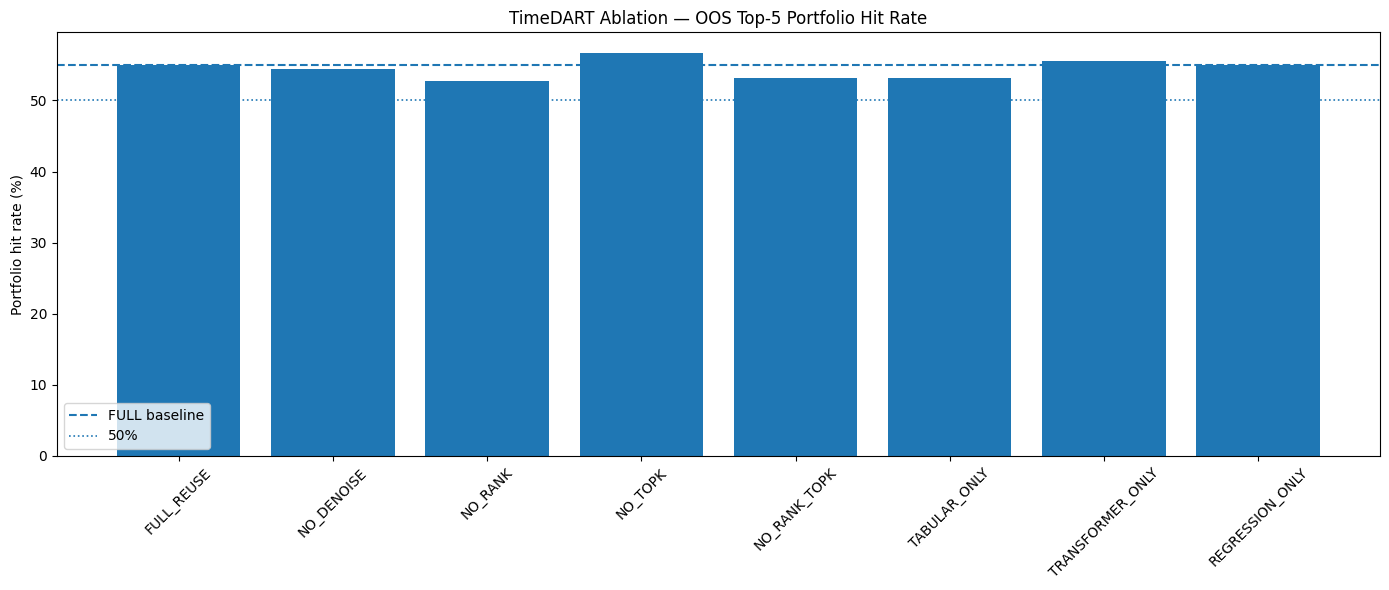

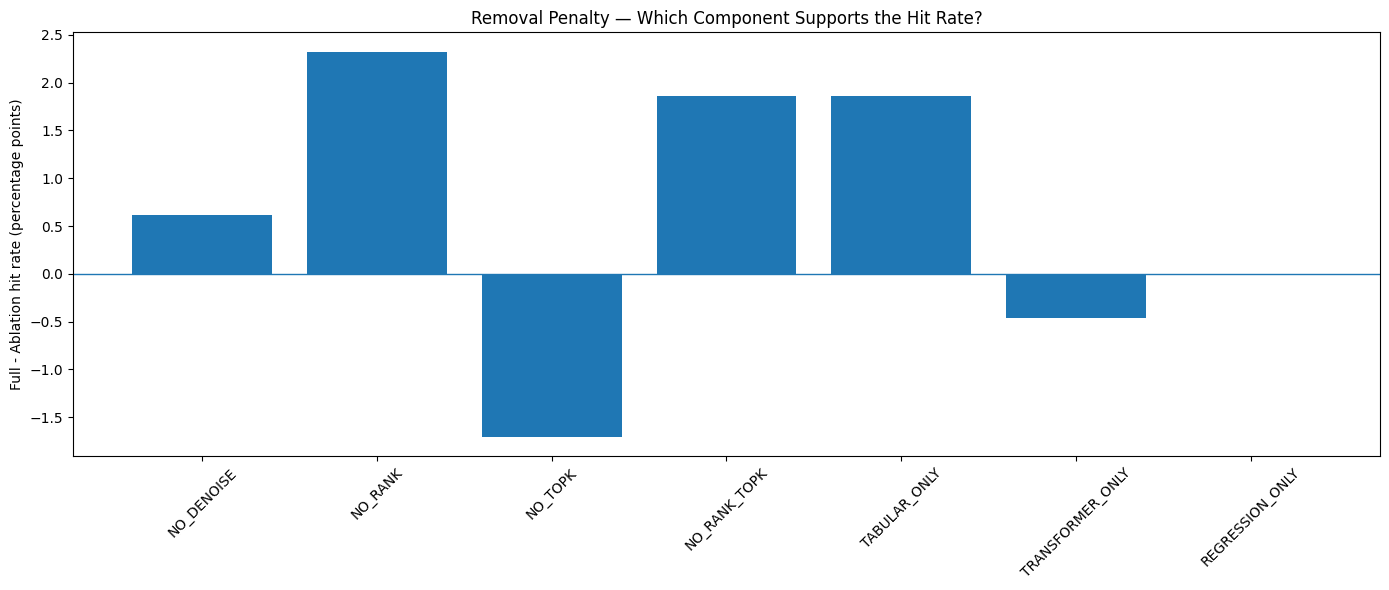

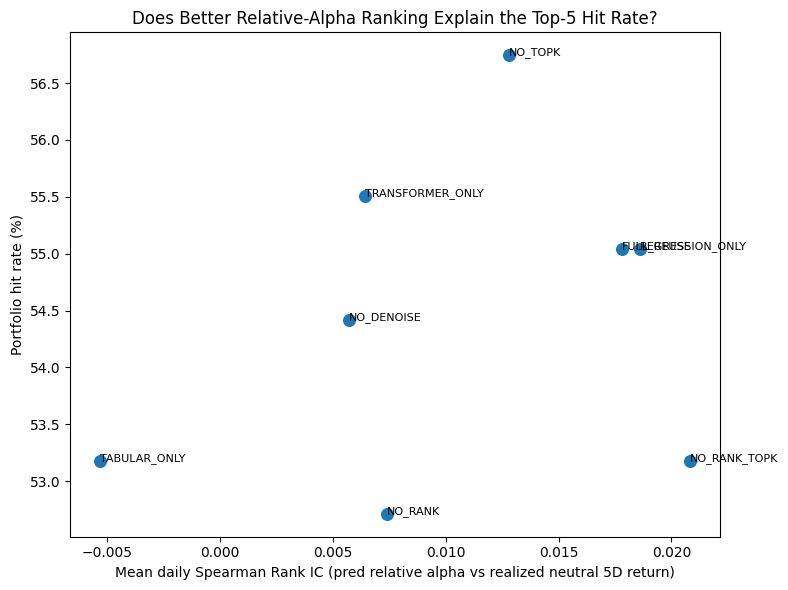

/tmp/ipykernel_7091/3690195568.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=variant_order, showmeans=True)


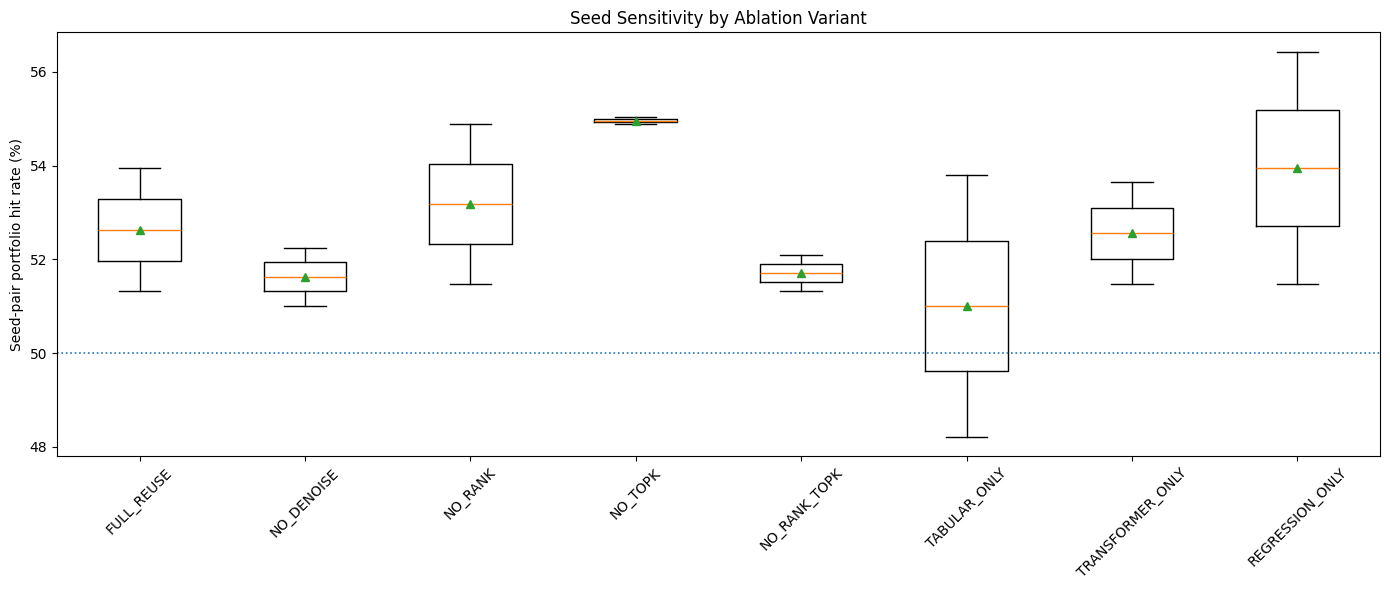

Saved to: /content/timedart_v63_strict_pit_v1_3_outputs/timedart_alpha_ablation_v1

[HOW TO READ]
1) hit_drop_vs_full_pp가 크고 양수 -> 제거한 요소가 OOS hit rate에 기여했을 가능성이 큼
2) rank_ic_drop_vs_full도 함께 크면 -> relative_alpha 순위 학습이 성능 경로일 가능성이 강함
3) hit는 유지되는데 Jaccard가 개선되면 -> 그 요소는 수익보다는 종목선택 불안정성을 만들었을 수 있음
4) STANDARD에서도 seed_hit_std가 크면 -> 평균 hit보다 initialization 안정성 문제가 우선


In [ ]:
# @title 12-C. 결과 시각화 + 저장
# 1) Portfolio hit rate
plot_q = ABLATION_VARIANT_SUMMARY.copy()
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(plot_q["ablation_variant"], plot_q["portfolio_hit_rate"] * 100)
ax.axhline(float(plot_q.loc[plot_q["ablation_variant"].eq("FULL_REUSE"), "portfolio_hit_rate"].iloc[0]) * 100,
           linestyle="--", linewidth=1.5, label="FULL baseline")
ax.axhline(50, linestyle=":", linewidth=1.2, label="50%")
ax.set_ylabel("Portfolio hit rate (%)")
ax.set_title("TimeDART Ablation — OOS Top-5 Portfolio Hit Rate")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# 2) 제거 penalty: 양수일수록 그 구성요소가 Full 성능에 도움을 줬다는 방향의 증거
fig, ax = plt.subplots(figsize=(14, 6))
pen = plot_q[~plot_q["ablation_variant"].eq("FULL_REUSE")]
ax.bar(pen["ablation_variant"], pen["hit_drop_vs_full_pp"])
ax.axhline(0, linewidth=1)
ax.set_ylabel("Full - Ablation hit rate (percentage points)")
ax.set_title("Removal Penalty — Which Component Supports the Hit Rate?")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 3) Rank IC와 hit rate를 함께 봅니다. 현재 Top-5 경로가 relative_alpha 중심이므로 특히 중요합니다.
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_q["mean_daily_rank_ic"], plot_q["portfolio_hit_rate"] * 100, s=70)
for r in plot_q.itertuples():
    if np.isfinite(r.mean_daily_rank_ic) and np.isfinite(r.portfolio_hit_rate):
        ax.annotate(r.ablation_variant, (r.mean_daily_rank_ic, r.portfolio_hit_rate * 100), fontsize=8)
ax.set_xlabel("Mean daily Spearman Rank IC (pred relative alpha vs realized neutral 5D return)")
ax.set_ylabel("Portfolio hit rate (%)")
ax.set_title("Does Better Relative-Alpha Ranking Explain the Top-5 Hit Rate?")
plt.tight_layout()
plt.show()

# 4) seed별 hit rate 분산 — 성능이 특정 initialization에 의존하는지 확인
fig, ax = plt.subplots(figsize=(14, 6))
variant_order = list(ABLATION_VARIANTS)
data = [
    ABLATION_SEED_SUMMARY.loc[ABLATION_SEED_SUMMARY["ablation_variant"].eq(v), "portfolio_hit_rate"].dropna().to_numpy() * 100
    for v in variant_order
]
ax.boxplot(data, labels=variant_order, showmeans=True)
ax.axhline(50, linestyle=":", linewidth=1.2)
ax.set_ylabel("Seed-pair portfolio hit rate (%)")
ax.set_title("Seed Sensitivity by Ablation Variant")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 저장
ABLATION_VARIANT_SUMMARY.to_csv(ABLATION_OUTPUT_DIR / "ablation_variant_summary.csv", index=False)
ABLATION_SEED_SUMMARY.to_csv(ABLATION_OUTPUT_DIR / "ablation_seed_summary.csv", index=False)
ABLATION_DAILY_ALL.to_parquet(ABLATION_OUTPUT_DIR / "ablation_daily_top5.parquet", index=False)
if len(ABLATION_IC_DAILY):
    ABLATION_IC_DAILY.to_csv(ABLATION_OUTPUT_DIR / "ablation_daily_rank_ic.csv", index=False)
if len(ABLATION_WF_AUDIT):
    ABLATION_WF_AUDIT.to_csv(ABLATION_OUTPUT_DIR / "ablation_walk_forward_audit.csv", index=False)
if ABLATION_SAVE_PREDICTIONS:
    ABLATION_OOS_ALL.to_parquet(ABLATION_OUTPUT_DIR / "ablation_oos_predictions.parquet", index=False)

with open(ABLATION_OUTPUT_DIR / "ablation_config.json", "w", encoding="utf-8") as f:
    json.dump({
        "profile": ABLATION_PROFILE,
        "seed_ids": ABLATION_SEED_IDS,
        "variants": ABLATION_VARIANTS,
        "full_reference_hit_rate_for_this_profile": float(full["portfolio_hit_rate"]),
        "metric_definition": "portfolio hit = mean net 5D return of selected Top-5 > 0",
        "warning": "Ablation effects are non-additive because model components interact.",
    }, f, ensure_ascii=False, indent=2, default=str)

print("Saved to:", ABLATION_OUTPUT_DIR)
print("\n[HOW TO READ]")
print("1) hit_drop_vs_full_pp가 크고 양수 -> 제거한 요소가 OOS hit rate에 기여했을 가능성이 큼")
print("2) rank_ic_drop_vs_full도 함께 크면 -> relative_alpha 순위 학습이 성능 경로일 가능성이 강함")
print("3) hit는 유지되는데 Jaccard가 개선되면 -> 그 요소는 수익보다는 종목선택 불안정성을 만들었을 수 있음")
print("4) STANDARD에서도 seed_hit_std가 크면 -> 평균 hit보다 initialization 안정성 문제가 우선")


## 17. Institutional Monitoring Dashboard

TimeDART의 raw Top-5 hit-rate만 보는 대신, optimized portfolio의 누적성과·turnover·gross exposure·Signal Registry·Model Registry를 동시에 확인합니다.


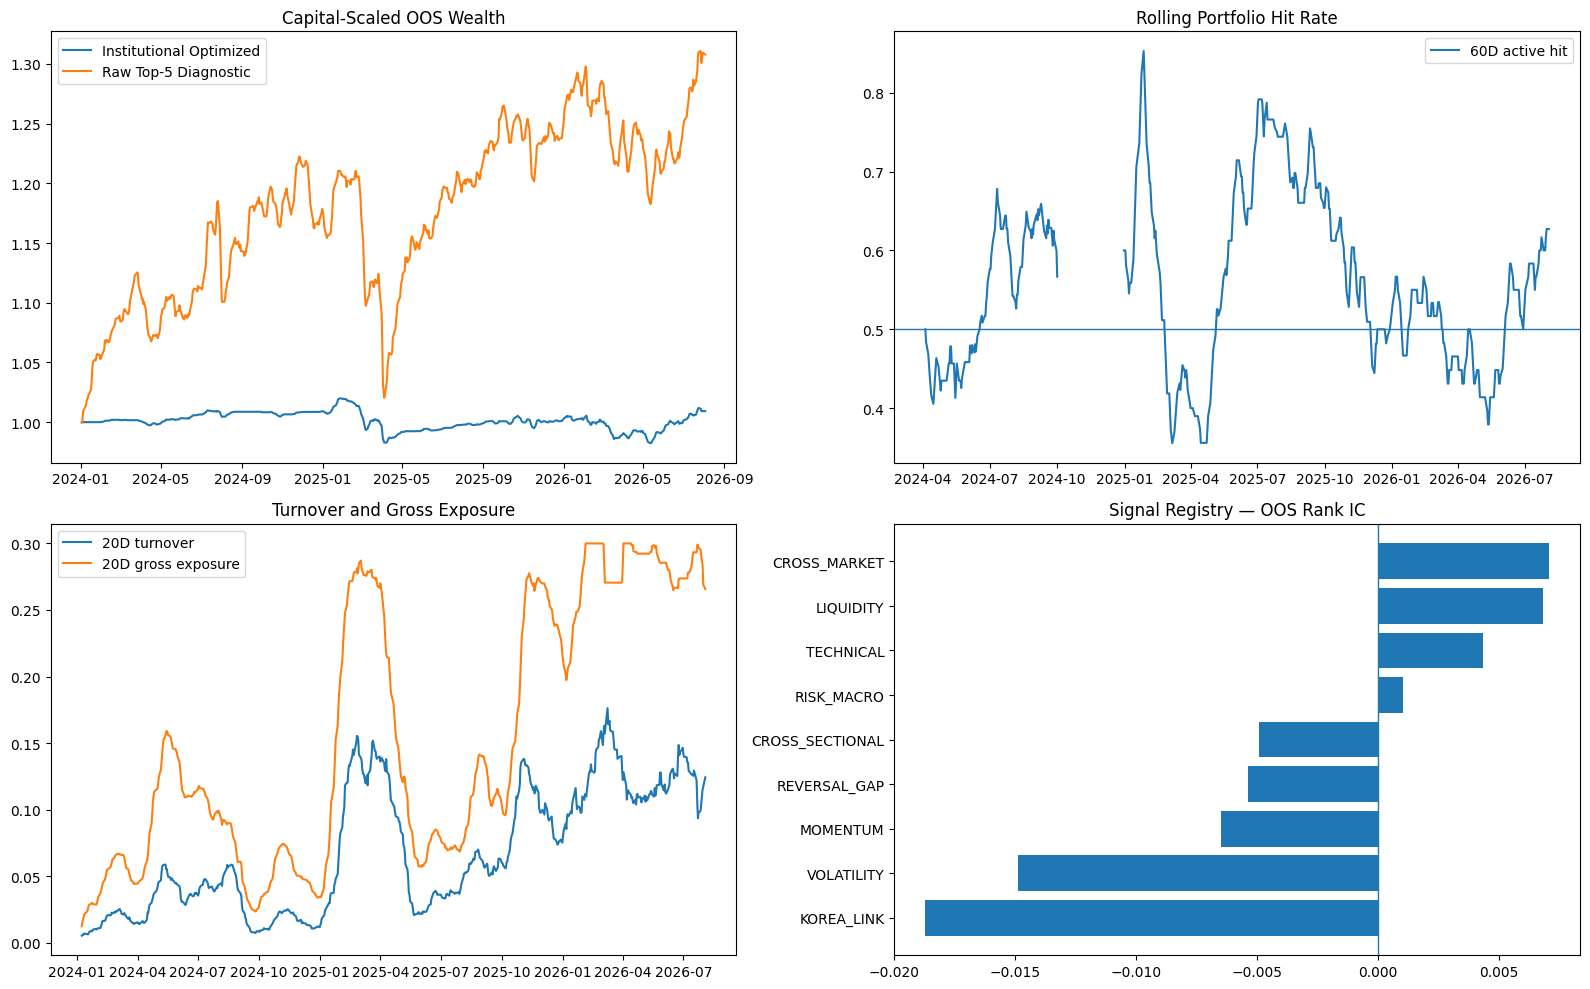

,active_days,mean_net_return_5d,portfolio_hit_rate,mean_turnover,mean_gross_exposure,return_HAC_t,return_HAC_p,hit_HAC_t_vs_50,hit_HAC_p,capital_scaled_annual_return,capital_scaled_max_drawdown
0,520,0.000088,0.557692,0.082339,0.186986,0.259418,0.795312,1.74559,0.080882,0.004422,-0.036858


,model_id,status,oos_rows,oos_rank_ic,positive_ic_years,rmse,mae,data_snapshot_id,protocol_hash,auto_live_promotion
0,TIMEDART_COMPACT_V63_CONSENSUS,CANDIDATE,112752,0.010985,2,0.040674,0.027788,8d3eeac2533ca9aac8330e62c3aae9f1419ef3e39e3143...,08eb7e24629bdfcacf25606b25338b164e75896d38eaba...,False
1,CAUSAL_SIGNAL_RIDGE_V1,RESEARCH,112752,-0.005522,1,0.040681,0.027806,8d3eeac2533ca9aac8330e62c3aae9f1419ef3e39e3143...,08eb7e24629bdfcacf25606b25338b164e75896d38eaba...,False


In [ ]:
# @title 17-A. Institutional monitoring dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Optimized portfolio path vs diagnostic raw Top-5 path.
inst = INSTITUTIONAL_PORTFOLIO_DAILY.copy().sort_values("entry_date")
inst["wealth"] = np.exp(inst["capital_scaled_return"].fillna(0).cumsum())
axes[0,0].plot(pd.to_datetime(inst["entry_date"]), inst["wealth"], label="Institutional Optimized")
if "RAW_CONSENSUS_DAILY" in globals() and len(RAW_CONSENSUS_DAILY):
    raw = RAW_CONSENSUS_DAILY.sort_values("entry_date").copy()
    raw["wealth"] = np.exp(raw["capital_scaled_return"].fillna(0).cumsum())
    axes[0,0].plot(pd.to_datetime(raw["entry_date"]), raw["wealth"], label="Raw Top-5 Diagnostic")
axes[0,0].set_title("Capital-Scaled OOS Wealth")
axes[0,0].legend()

# 2) Rolling hit and gross exposure.
hit = inst["portfolio_hit"].rolling(60, min_periods=30).mean()
axes[0,1].plot(pd.to_datetime(inst["entry_date"]), hit, label="60D active hit")
axes[0,1].axhline(0.5, linewidth=1)
axes[0,1].set_title("Rolling Portfolio Hit Rate")
axes[0,1].legend()

# 3) Turnover / exposure.
axes[1,0].plot(pd.to_datetime(inst["entry_date"]), inst["turnover"].rolling(20, min_periods=5).mean(), label="20D turnover")
axes[1,0].plot(pd.to_datetime(inst["entry_date"]), inst["gross_exposure"].rolling(20, min_periods=5).mean(), label="20D gross exposure")
axes[1,0].set_title("Turnover and Gross Exposure")
axes[1,0].legend()

# 4) Signal OOS Rank IC.
if len(SIGNAL_REGISTRY):
    sr = SIGNAL_REGISTRY.sort_values("oos_rank_ic")
    axes[1,1].barh(sr["family"], sr["oos_rank_ic"])
    axes[1,1].axvline(0, linewidth=1)
    axes[1,1].set_title("Signal Registry — OOS Rank IC")
else:
    axes[1,1].text(0.5,0.5,"No signal registry results",ha="center",va="center")
    axes[1,1].set_title("Signal Registry")

plt.tight_layout()
INSTITUTIONAL_DASHBOARD_FIG = fig
plt.show()

display(INSTITUTIONAL_PORTFOLIO_SUMMARY)
display(MODEL_REGISTRY)


## 18. Institutional Artifact Export

기존 TimeDART research output과 별개로 institutional stack의 provenance, signal/model registry, optimized OOS portfolio, simulator 결과, promotion audit, shadow ledger를 독립 저장합니다.


In [ ]:
# @title 18-A. Save institutional registries / portfolio / simulator / shadow artifacts
SYSTEM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

(SYSTEM_OUTPUT_DIR / "institutional_contract.json").write_text(
    json.dumps({**INSTITUTIONAL_CONTRACT, "protocol_hash": INSTITUTIONAL_PROTOCOL_HASH}, ensure_ascii=False, indent=2, default=str),
    encoding="utf-8",
)
DATA_QUALITY_AUDIT.to_csv(SYSTEM_OUTPUT_DIR / "data_quality_audit.csv", index=False)
SIGNAL_REGISTRY.to_csv(SYSTEM_OUTPUT_DIR / "signal_registry.csv", index=False)
SIGNAL_RECIPE_AUDIT.to_csv(SYSTEM_OUTPUT_DIR / "signal_recipe_audit.csv", index=False)
MODEL_REGISTRY.to_csv(SYSTEM_OUTPUT_DIR / "model_registry.csv", index=False)
SYSTEM_PROMOTION_AUDIT.to_csv(SYSTEM_OUTPUT_DIR / "system_promotion_audit.csv", index=False)
INSTITUTIONAL_PORTFOLIO_META.to_csv(SYSTEM_OUTPUT_DIR / "portfolio_optimizer_meta.csv", index=False)
INSTITUTIONAL_PORTFOLIO_DAILY.to_csv(SYSTEM_OUTPUT_DIR / "portfolio_simulator_daily.csv", index=False)
INSTITUTIONAL_PORTFOLIO_SUMMARY.to_csv(SYSTEM_OUTPUT_DIR / "portfolio_summary.csv", index=False)
INSTITUTIONAL_PORTFOLIO_YEARLY.to_csv(SYSTEM_OUTPUT_DIR / "portfolio_yearly.csv", index=False)

if len(SIGNAL_RIDGE_OOS):
    SIGNAL_RIDGE_OOS.to_parquet(SYSTEM_OUTPUT_DIR / "signal_ridge_oos.parquet", index=False)
if len(SIGNAL_OOS):
    SIGNAL_OOS.to_parquet(SYSTEM_OUTPUT_DIR / "signal_family_oos.parquet", index=False)
if len(INSTITUTIONAL_ALPHA_OOS):
    INSTITUTIONAL_ALPHA_OOS.to_parquet(SYSTEM_OUTPUT_DIR / "institutional_alpha_oos.parquet", index=False)
if len(INSTITUTIONAL_PORTFOLIO_WEIGHTS):
    INSTITUTIONAL_PORTFOLIO_WEIGHTS.to_parquet(SYSTEM_OUTPUT_DIR / "institutional_portfolio_weights.parquet", index=False)
if "INSTITUTIONAL_SHADOW_LEDGER" in globals() and len(INSTITUTIONAL_SHADOW_LEDGER):
    INSTITUTIONAL_SHADOW_LEDGER.to_parquet(SYSTEM_OUTPUT_DIR / "institutional_shadow_ledger.parquet", index=False)

INSTITUTIONAL_DASHBOARD_FIG.savefig(SYSTEM_OUTPUT_DIR / "institutional_dashboard.png", dpi=170, bbox_inches="tight")

ARCHITECTURE_MANIFEST = {
    "system_version": INST.system_version,
    "run_id": RESEARCH_RUN_ID,
    "layers": [
        "PIT_DATA_PLATFORM", "DATA_QUALITY_PROVENANCE", "SIGNAL_FACTORY", "SIGNAL_REGISTRY",
        "ALPHA_MODEL_LAB", "MODEL_REGISTRY", "RISK_MODEL", "PORTFOLIO_OPTIMIZER",
        "COST_IMPACT_SIMULATOR", "SHADOW_LEDGER", "MONITORING",
    ],
    "champion_alpha_source_frozen": INST.alpha_source,
    "challenger": "CAUSAL_SIGNAL_RIDGE_V1",
    "top5_role": "DIAGNOSTIC_ONLY",
    "promotion_status": SYSTEM_PROMOTION_STATUS,
}
(SYSTEM_OUTPUT_DIR / "architecture_manifest.json").write_text(
    json.dumps(ARCHITECTURE_MANIFEST, ensure_ascii=False, indent=2), encoding="utf-8"
)

zip_path_inst = Path("/content/krx_institutional_quant_v1_outputs.zip")
with zipfile.ZipFile(zip_path_inst, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(SYSTEM_OUTPUT_DIR.rglob("*")):
        if p.is_file():
            zf.write(p, p.relative_to(SYSTEM_OUTPUT_DIR))

print("institutional outputs:", SYSTEM_OUTPUT_DIR)
print("institutional zip:", zip_path_inst)
print("promotion status:", SYSTEM_PROMOTION_STATUS)


institutional outputs: /content/krx_institutional_quant_v1_outputs
institutional zip: /content/krx_institutional_quant_v1_outputs.zip
promotion status: RESEARCH_ONLY
